In [ ]:
!pip install netCDF4 statsmodels scikit-posthocs -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 39.1 MB/s eta 0:00:00


# Step to step


In [ ]:
# ==============================================================================
# CELL 0: DEPENDENCY INSTALLATION
# ==============================================================================
!pip install -q SALib netCDF4 statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 133.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 72.3 MB/s eta 0:00:00


In [ ]:
# ==============================================================================
# CELL 1: IMPORTS AND CONFIGURATION
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import (fsolve, differential_evolution, dual_annealing,
                            minimize)
from scipy import stats
from statsmodels.stats.libqsturng import qsturng
import time
import warnings
import os
import json
from collections import defaultdict
from functools import partial

warnings.filterwarnings('ignore')

import scipy
print(f"NumPy: {np.__version__}")
print(f"SciPy: {scipy.__version__}")

# ------------------------------------------------------------------------------
# MOUNT GOOGLE DRIVE
# ------------------------------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

# Paths — ADJUST ACCORDING TO YOUR STRUCTURE
DATA_PATH = '/content/drive/MyDrive/SeaData/20190101_prof.nc'
OUTPUT_DIR = '/content/drive/MyDrive/SeaData/benchmark_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

if not os.path.exists(DATA_PATH):
    for root, dirs, files in os.walk('/content/drive/MyDrive'):
        if '20190101_prof.nc' in files:
            DATA_PATH = os.path.join(root, '20190101_prof.nc')
            print(f"File found at: {DATA_PATH}")
            break
    else:
        raise FileNotFoundError("20190101_prof.nc not found in Google Drive")

print(f"Data: {DATA_PATH}")
print(f"Results: {OUTPUT_DIR}")

# ------------------------------------------------------------------------------
# STYLE AND PALETTES (4 methods only)
# ------------------------------------------------------------------------------
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'axes.labelsize': 12, 'axes.titlesize': 13,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'legend.fontsize': 10, 'figure.dpi': 150,
})

CB_COLORS = {'DE': '#0072B2', 'DA': '#D55E00', 'LB': '#009E73', 'SQ': '#CC79A7'}
METHOD_NAMES = {'DE': 'Differential Evolution', 'DA': 'Dual Annealing',
                'LB': 'L-BFGS-B', 'SQ': 'SLSQP'}
MARKERS = {'DE': 'o', 'DA': 's', 'LB': 'D', 'SQ': 'v'}

NumPy: 2.0.2
SciPy: 1.16.3
Mounted at /content/drive
File found at: /content/drive/MyDrive/Colab Notebooks/Data/SeaData/20190101_prof.nc
Data: /content/drive/MyDrive/Colab Notebooks/Data/SeaData/20190101_prof.nc
Results: /content/drive/MyDrive/SeaData/benchmark_results


In [ ]:
# ==============================================================================
# CELL 2: ARGO DATA LOADING (fill values -> NaN, slicing [:995])
# ==============================================================================
from netCDF4 import Dataset

nc = Dataset(DATA_PATH, 'r')
temp_masked = nc.variables['TEMP'][:]
sal_masked = nc.variables['PSAL'][:]
pres_masked = nc.variables['PRES'][:]
nc.close()

temp = np.asarray(temp_masked.filled(np.nan))
sal = np.asarray(sal_masked.filled(np.nan))
pres = np.asarray(pres_masked.filled(np.nan))

MAX_LEVELS = 995
n_profiles_total = temp.shape[0]
print(f"\nProfiles in file: {n_profiles_total}")

argo_profiles = {}
for p in range(n_profiles_total):
    t_prof = temp[p, :MAX_LEVELS]
    s_prof = sal[p, :MAX_LEVELS]
    p_prof = pres[p, :MAX_LEVELS]

    valid = np.isfinite(t_prof) & np.isfinite(s_prof) & np.isfinite(p_prof)
    t_prof, s_prof, p_prof = t_prof[valid], s_prof[valid], p_prof[valid]
    if len(p_prof) < 10:
        continue

    has_surf = np.any(p_prof <= 50)
    has_therm = np.any((p_prof > 50) & (p_prof <= 800))
    has_deep = np.any(p_prof > 800)
    if not (has_surf and has_therm and has_deep):
        continue

    argo_profiles[p] = {'temp': t_prof, 'sal': s_prof, 'pres': p_prof}

valid_profile_ids = sorted(argo_profiles.keys())
n_profiles = len(valid_profile_ids)
print(f"Valid profiles: {n_profiles}")


Profiles in file: 68
Valid profiles: 67


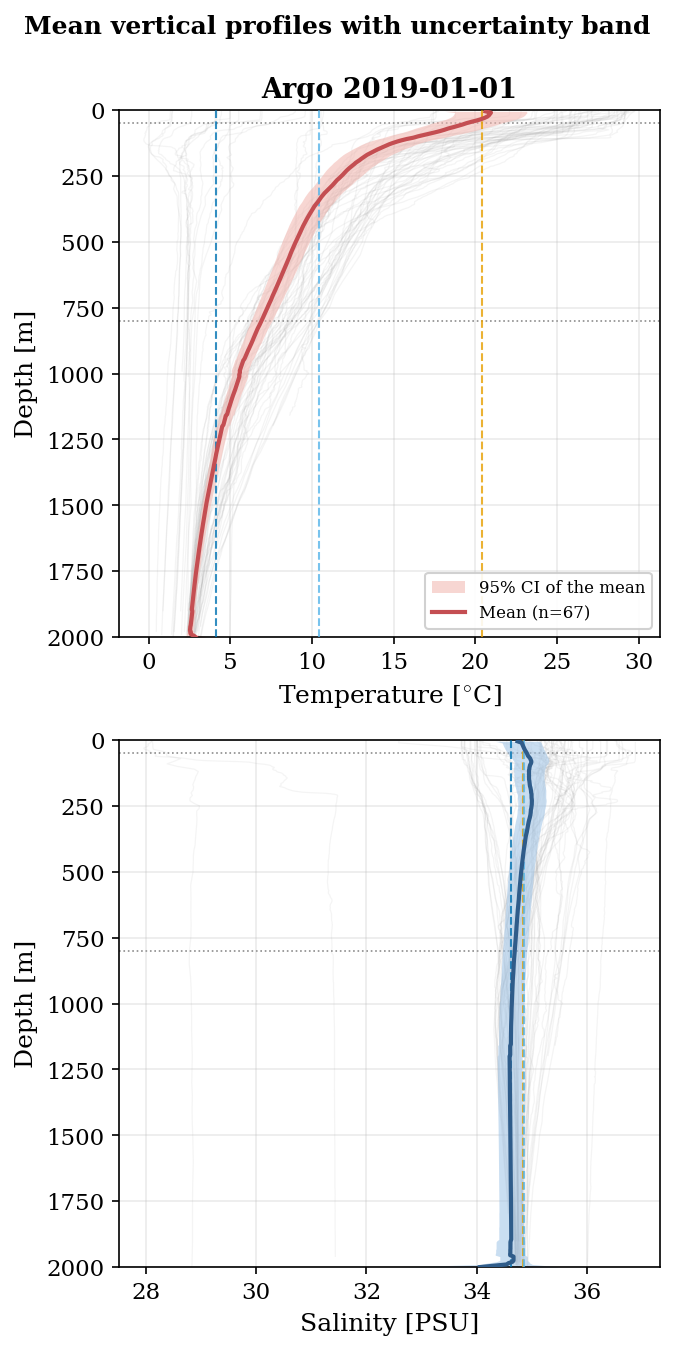

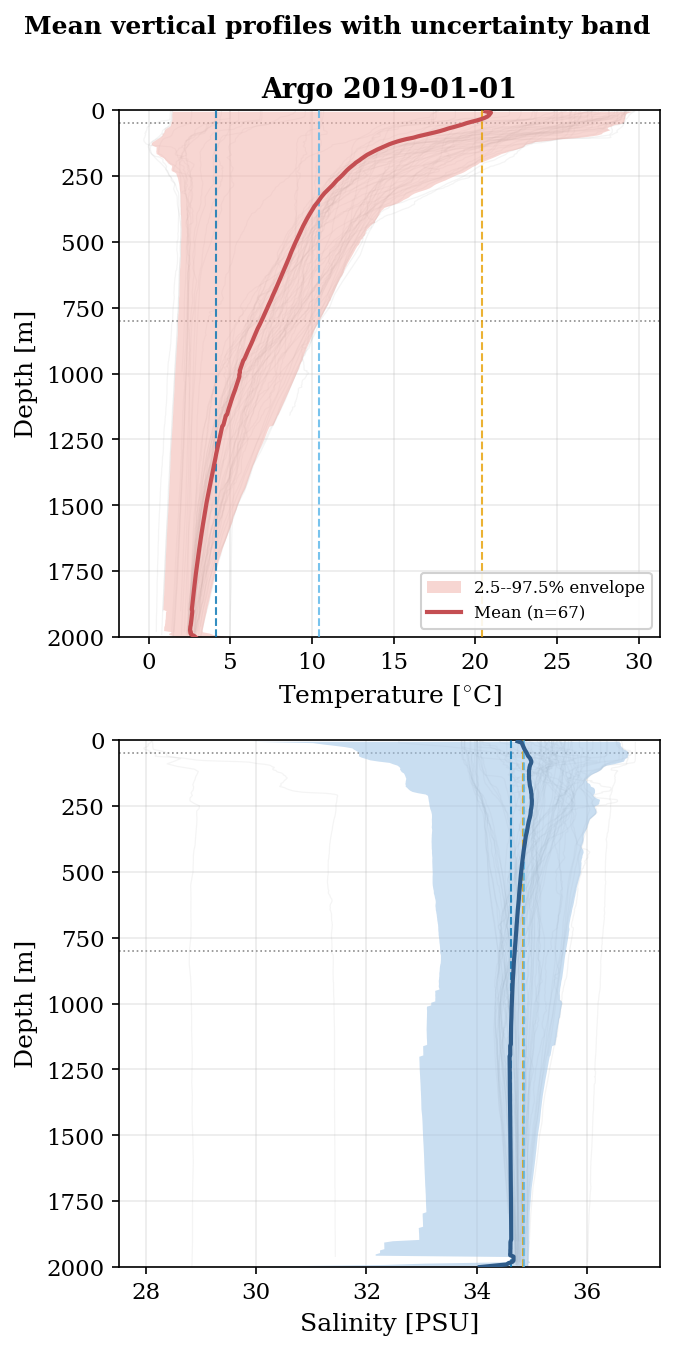

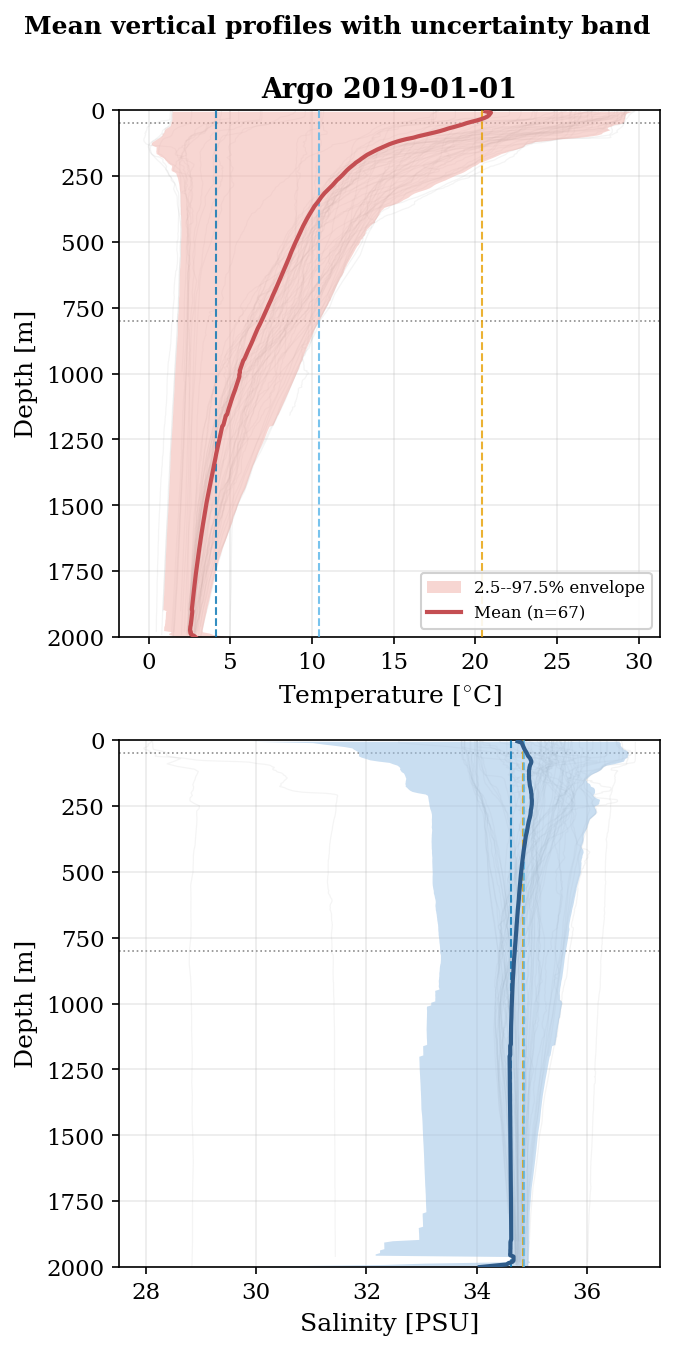

In [ ]:
# ==============================================================================
# CELL 11: MEAN VERTICAL PROFILES WITH CONFIDENCE BANDS
# ------------------------------------------------------------------------------
# For temperature and salinity, plots the across-profile mean as a function of
# depth together with a shaded uncertainty band, overlaid on the individual
# profiles. Argo profiles are sampled on irregular pressure grids, so each
# profile is first linearly interpolated onto a common depth grid (no
# extrapolation beyond its observed range); the mean and band are then computed
# grid-point-wise.
#
# band_type:
#   'ci95' : 95% confidence interval of the MEAN (mean +/- 1.96*SE). Narrow,
#            shrinks with sample size. Answers "where does the mean lie".
#   'sd'   : mean +/- 1 standard deviation across profiles.
#   'pct'  : 2.5-97.5% inter-profile envelope. Wide; shows the spread of the
#            profiles themselves and reproduces the look of the reference figure.
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
import warnings

DEPTH_GRID = np.arange(0.0, 2001.0, 5.0)    # common grid [dbar ~= m]
LAYER_BNDS = (50.0, 800.0)                   # 3-layer model boundaries
MIN_PROF   = 3                               # min. profiles to draw mean/band

def _interp_to_grid(profiles, ids, var, grid):
    """Interpolate each profile's `var` onto `grid`; NaN outside observed range."""
    M = np.full((len(ids), grid.size), np.nan)
    for i, p in enumerate(ids):
        pr = np.asarray(profiles[p]['pres'], float)
        v  = np.asarray(profiles[p][var], float)
        order = np.argsort(pr)
        pr_u, idx = np.unique(pr[order], return_index=True)   # strictly increasing
        if pr_u.size < 2:
            continue
        M[i] = np.interp(grid, pr_u, v[order][idx], left=np.nan, right=np.nan)
    return M

def _mean_band(M, band_type='ci95', min_n=MIN_PROF):
    n = np.sum(np.isfinite(M), axis=0)
    with warnings.catch_warnings():               # silence empty/all-NaN slices
        warnings.simplefilter('ignore', RuntimeWarning)
        mean = np.nanmean(M, axis=0)
        sd   = np.nanstd(M, axis=0, ddof=1)
        with np.errstate(invalid='ignore', divide='ignore'):
            se = sd / np.sqrt(n)
        if band_type == 'ci95':
            lo, hi = mean - 1.96 * se, mean + 1.96 * se
        elif band_type == 'sd':
            lo, hi = mean - sd, mean + sd
        elif band_type == 'pct':
            lo = np.nanpercentile(M, 2.5, axis=0)
            hi = np.nanpercentile(M, 97.5, axis=0)
        else:
            raise ValueError("band_type must be 'ci95', 'sd' or 'pct'")
    valid = n >= min_n
    for a in (mean, lo, hi):
        a[~valid] = np.nan
    return mean, lo, hi, n

def _layer_means(mean, grid, bnds=LAYER_BNDS):
    """Mean of the mean-profile within each of the three layers."""
    s, t = bnds
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        return [np.nanmean(mean[grid <= s]),
                np.nanmean(mean[(grid > s) & (grid <= t)]),
                np.nanmean(mean[grid > t])]

_BAND_LABEL = {'ci95': '95% CI of the mean',
               'sd':   r'Mean $\pm$ 1 SD',
               'pct':  '2.5--97.5% envelope'}
_LAYER_C = ('#E69F00', '#56B4E9', '#0072B2')   # surface, thermocline, deep

def plot_profile_envelopes(datasets, grid=DEPTH_GRID, band_type='ci95',
                           show_individual=True, show_layer_means=True,
                           depth_max=2000.0, save_path=None):
    """
    datasets : dict {column_label: profiles_dict}; each profiles_dict maps an id
               to {'temp','sal','pres'}. One column per dataset (e.g. noise
               levels), reproducing the multi-panel layout of the reference fig.
    """
    variables = [('temp', r'Temperature [$^{\circ}$C]', '#C44E52', '#F2B5AE'),
                 ('sal',  'Salinity [PSU]',             '#2F5C8A', '#9EC3E6')]
    cols = list(datasets.keys())
    fig, axes = plt.subplots(2, len(cols), figsize=(4.6 * len(cols), 9),
                             sharey=True, squeeze=False)

    for r, (var, xlabel, line_c, band_c) in enumerate(variables):
        for c, label in enumerate(cols):
            ax = axes[r, c]
            profiles = datasets[label]
            ids = sorted(profiles.keys())

            if show_individual:
                for p in ids:
                    ax.plot(profiles[p][var], profiles[p]['pres'],
                            color='0.6', alpha=0.10, lw=0.6, zorder=1)

            M = _interp_to_grid(profiles, ids, var, grid)
            mean, lo, hi, n = _mean_band(M, band_type)

            ax.fill_betweenx(grid, lo, hi, color=band_c, alpha=0.55, lw=0,
                             zorder=2, label=_BAND_LABEL[band_type])
            ax.plot(mean, grid, color=line_c, lw=2.0, zorder=4,
                    label=f'Mean (n={int(np.nanmax(n))})')

            for b in LAYER_BNDS:                       # horizontal layer bounds
                ax.axhline(b, color='k', ls=':', lw=0.8, alpha=0.45, zorder=0)
            if show_layer_means:                       # vertical layer means
                for val, lc in zip(_layer_means(mean, grid), _LAYER_C):
                    if np.isfinite(val):
                        ax.axvline(val, color=lc, ls='--', lw=1.0, alpha=0.8, zorder=3)

            ax.set_xlabel(xlabel)
            if r == 0:
                ax.set_title(label, fontweight='bold')
            if c == 0:
                ax.set_ylabel('Depth [m]')
            ax.grid(True, alpha=0.25)
            if r == 0 and c == 0:
                ax.legend(loc='lower right', fontsize=8, framealpha=0.9)

    axes[0, 0].set_ylim(depth_max, 0.0)                # surface (0) at the top
    fig.suptitle('Mean vertical profiles with uncertainty band',
                 fontweight='bold', y=0.995)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    return fig

# --- Single observed dataset (real Argo) -------------------------------------
plot_profile_envelopes({'Argo 2019-01-01': argo_profiles},
                       band_type='ci95',
                       save_path=f'{OUTPUT_DIR}/mean_profiles_ci.png')

# --- 2.5-97.5% inter-profile envelope (reproduces the reference look) --------
plot_profile_envelopes({'Argo 2019-01-01': argo_profiles},
                       band_type='pct',
                       save_path=f'{OUTPUT_DIR}/mean_profiles_envelope.png')

In [ ]:
# ==============================================================================
# CELL 3: LAYER-WISE TARGET EXTRACTION
# ==============================================================================
def extract_layer_targets(temp, sal, pres):
    sort_idx = np.argsort(pres)
    temp, sal, pres = temp[sort_idx], sal[sort_idx], pres[sort_idx]
    T_target = np.array([
        np.mean(temp[pres <= 50]),
        np.mean(temp[(pres > 50) & (pres <= 800)]),
        np.mean(temp[pres > 800])])
    S_target = np.array([
        np.mean(sal[pres <= 50]),
        np.mean(sal[(pres > 50) & (pres <= 800)]),
        np.mean(sal[pres > 800])])
    return T_target, S_target, pres

profile_targets = {}
for p in valid_profile_ids:
    T_t, S_t, _ = extract_layer_targets(
        argo_profiles[p]['temp'], argo_profiles[p]['sal'], argo_profiles[p]['pres'])
    profile_targets[p] = {'T': T_t, 'S': S_t}
    print(f"Profile {p}: T={np.round(T_t, 2)}, S={np.round(S_t, 2)}")

Profile 0: T=[18.67 12.86  4.65], S=[35.37 35.2  34.5 ]
Profile 1: T=[29.2  13.62  4.98], S=[35.15 35.14 34.9 ]
Profile 2: T=[4.07 2.42 2.03], S=[33.88 34.29 34.72]
Profile 3: T=[5.5  3.86 2.37], S=[33.98 34.13 34.67]
Profile 4: T=[28.87 13.57  5.38], S=[34.68 35.06 34.86]
Profile 5: T=[27.59 15.07  4.17], S=[35.15 35.18 34.61]
Profile 6: T=[19.94 10.65  3.37], S=[35.89 34.95 34.56]
Profile 7: T=[17.39 14.76  5.78], S=[35.59 35.41 34.52]
Profile 8: T=[22.51 15.23  8.64], S=[35.6  35.39 34.65]
Profile 9: T=[26.86 14.04  5.65], S=[36.36 35.58 35.03]
Profile 10: T=[27.98 11.02  3.97], S=[34.31 34.86 34.89]
Profile 11: T=[4.4  2.39 1.9 ], S=[33.96 34.33 34.73]
Profile 12: T=[28.25 10.62  4.52], S=[28.05 31.1  31.42]
Profile 13: T=[1.16 1.67 1.27], S=[34.01 34.62 34.75]
Profile 14: T=[25.25 14.24  9.02], S=[36.37 35.91 35.54]
Profile 15: T=[4.75 2.48 2.46], S=[33.79 34.25 34.63]
Profile 16: T=[24.66 13.98  4.3 ], S=[35.54 35.21 34.57]
Profile 17: T=[29.42 12.08  4.94], S=[35.22 35.05 34.87]

In [ ]:
# ==============================================================================
# CELL 4: PHYSICAL MODEL
# ==============================================================================
FIXED = {
    'lambda_D': 0.02,
    'gamma1': 0.01, 'omega1': 0.8, 'Teq': 20.0, 'mu0': 2.0,
    'gamma2': 0.01, 'omega2': 0.6,
    'mu1': 0.05, 'a1': 8.0, 'mu2': 0.03, 'a2': 6.0,
    'F_S': 0.5,
}

def stationary_state(k1, k2, k3, T_deep, T_ref, S_deep, S_ref, fixed=None):
    if fixed is None:
        fixed = FIXED

    def temp_equations(vars):
        T1, T2 = vars
        g1, w1, Teq, mu0 = fixed['gamma1'], fixed['omega1'], fixed['Teq'], fixed['mu0']
        g2, w2, lD = fixed['gamma2'], fixed['omega2'], fixed['lambda_D']
        f1 = (-g1*(T1 - Teq)**3 + k1*(T2 - T1) - k3*(T1 - T_ref)
              + mu0 - w1**2*(T1 - Teq))
        f2 = (-g2*(T2 - T_ref)**3 + k1*(T1 - T2)
              - (k2*lD/(k2 + lD))*(T2 - T_deep) - w2**2*(T2 - T_ref))
        return [f1, f2]

    seeds = [[5,5],[10,10],[15,15],[20,20],[25,25],[2,2],[18,8],[8,3],[12,6],
             [1,1],[30,5],[5,15],[15,5],[22,12],[28,8],[35,10],[10,18]]
    best_sol, best_resid = None, 1e12
    for seed in seeds:
        try:
            sol, info, ier, mesg = fsolve(temp_equations, seed, full_output=True)
            if ier == 1:
                T1, T2 = sol
                resid = np.sum(np.array(temp_equations(sol))**2)
                if -10 < T1 < 50 and -10 < T2 < 50 and resid < best_resid:
                    best_resid, best_sol = resid, sol
        except Exception:
            continue

    if best_sol is None or best_resid > 1e-2:
        return None

    T1, T2 = best_sol
    lD = fixed['lambda_D']
    T3 = (k2 * T2 + lD * T_deep) / (k2 + lD)
    if k1 <= 0:
        return None
    denom_s = (k2 * lD / (k2 + lD)) + k3
    if denom_s <= 0:
        return None

    S2 = (fixed['F_S'] + (k2*lD*S_deep)/(k2+lD) + k3*S_ref) / denom_s
    S3 = (k2 * S2 + lD * S_deep) / (k2 + lD)
    S1 = S2 + fixed['F_S'] / k1

    if not all(np.isfinite(v) for v in [T1,T2,T3,S1,S2,S3]):
        return None
    if any(v < 0 for v in [S1,S2,S3]):
        return None
    return np.array([T1, T2, T3, S1, S2, S3])

def cost_combined(params_opt, T_target, S_target, return_state=False, fixed=None):
    if fixed is None:
        fixed = FIXED
    k1, k2, k3, T_deep, T_ref, S_deep, S_ref = params_opt
    if any(v <= 0 for v in params_opt):
        return 1e10 if not return_state else None
    state = stationary_state(k1, k2, k3, T_deep, T_ref, S_deep, S_ref, fixed)
    if state is None:
        return 1e10 if not return_state else None
    T_pred, S_pred = state[0:3], state[3:6]
    if return_state:
        return state
    rmse_T = np.sqrt(np.mean((T_pred - T_target)**2))
    rmse_S = np.sqrt(np.mean((S_pred - S_target)**2))
    penalty = 0.0001 * (np.log10(k1)**2 + np.log10(k2)**2 + np.log10(k3)**2)
    return rmse_T + 20.0 * rmse_S + penalty

BOUNDS = [
    (0.0001, 5.0),    # k1
    (0.0001, 5.0),    # k2
    (0.001, 100.0),   # k3
    (0.1, 10.0),      # T_deep
    (0.1, 30.0),      # T_ref
    (33.0, 37.0),     # S_deep
    (33.0, 37.0),     # S_ref
]
PARAM_NAMES = ['k1', 'k2', 'k3', 'T_deep', 'T_ref', 'S_deep', 'S_ref']
PARAM_LATEX = [r'$k_1$', r'$k_2$', r'$k_3$', r'$T_{deep}$',
               r'$T_{ref}$', r'$S_{deep}$', r'$S_{ref}$']

In [ ]:
# ==============================================================================
# CELL 5: OPTIMISATION METHODS (4 robust)  —  FINAL CORRECTED
# ==============================================================================

def optimize_de(T_target, S_target, bounds, seed=42):
    """Differential Evolution."""
    start = time.time()
    result = differential_evolution(
        partial(cost_combined, T_target=T_target, S_target=S_target),
        bounds, maxiter=150, seed=seed, polish=True, workers=1,
        popsize=12, tol=1e-7, strategy='best1bin',
        mutation=(0.5, 1.5), recombination=0.7)

    # FIX: SciPy sometimes reports success=False when polish=True even though
    # the global solution is excellent. Force success if cost is valid.
    # Cast to native Python bool for JSON serialisation.
    is_valid = np.isfinite(result.fun) and result.fun < 1e6
    success = bool(result.success) or is_valid

    return {'params': result.x, 'cost': float(result.fun),
            'nfev': int(result.nfev), 'time': time.time() - start,
            'success': success}

def optimize_da(T_target, S_target, bounds, seed=42):
    """Dual Annealing."""
    start = time.time()
    result = dual_annealing(
        partial(cost_combined, T_target=T_target, S_target=S_target),
        bounds, maxiter=200, seed=seed, no_local_search=False,
        initial_temp=5230.0, restart_temp_ratio=2e-5)

    # FIX: Do not hardcode success=True. Use SciPy's flag, fall back to
    # a validity check. Cast to native Python bool for JSON.
    success = bool(getattr(result, 'success', False))
    if not success:
        success = np.isfinite(result.fun) and result.fun < 1e6

    return {'params': result.x, 'cost': float(result.fun),
            'nfev': int(result.nfev), 'time': time.time() - start,
            'success': success}

def optimize_lbfgsb(T_target, S_target, bounds, seed=42):
    """L-BFGS-B with log-transform."""
    np.random.seed(seed)
    log_bounds = [(np.log(b[0] + 1e-12), np.log(b[1])) for b in bounds]
    def cost_log(z, T_t, S_t):
        return cost_combined(np.exp(z), T_t, S_t)
    z0 = np.array([np.random.uniform(lb, ub) for lb, ub in log_bounds])
    start = time.time()
    result = minimize(cost_log, z0, args=(T_target, S_target),
                      method='L-BFGS-B', bounds=log_bounds,
                      options={'maxiter': 500, 'ftol': 1e-9})
    # Local methods: trust SciPy's convergence flag. Cast to native bool.
    return {'params': np.exp(result.x), 'cost': float(result.fun),
            'nfev': int(result.nfev), 'time': time.time() - start,
            'success': bool(result.success)}

def optimize_slsqp(T_target, S_target, bounds, seed=42):
    """SLSQP with log-transform."""
    np.random.seed(seed)
    log_bounds = [(np.log(b[0] + 1e-12), np.log(b[1])) for b in bounds]
    def cost_log(z, T_t, S_t):
        return cost_combined(np.exp(z), T_t, S_t)
    z0 = np.array([np.random.uniform(lb, ub) for lb, ub in log_bounds])
    start = time.time()
    result = minimize(cost_log, z0, args=(T_target, S_target),
                      method='SLSQP', bounds=log_bounds,
                      options={'maxiter': 500, 'ftol': 1e-9})
    # Local methods: trust SciPy's convergence flag. Cast to native bool.
    return {'params': np.exp(result.x), 'cost': float(result.fun),
            'nfev': int(result.nfev), 'time': time.time() - start,
            'success': bool(result.success)}

METHODS = {'DE': optimize_de, 'DA': optimize_da,
           'LB': optimize_lbfgsb, 'SQ': optimize_slsqp}
print("Methods loaded:", list(METHODS.keys()))

Methods loaded: ['DE', 'DA', 'LB', 'SQ']


In [ ]:
import os, json
checkpoint_file = '/content/drive/MyDrive/SeaData/benchmark_results/results_checkpoint_4methods.json'
if os.path.exists(checkpoint_file):
    os.remove(checkpoint_file)
    print("Checkpoint deleted.")
else:
    print("No checkpoint found.")

Checkpoint deleted.


In [ ]:
# ==============================================================================
# CELL 6: BENCHMARK EXECUTION WITH CHECKPOINTS  —  DEFINITIVE FIX
# ==============================================================================

import numpy as np
import json
from collections import defaultdict

# ----------------------------------------------------------------------------
# Helper: recursively convert numpy scalars to native Python types for JSON
# ----------------------------------------------------------------------------
def _sanitize_for_json(obj):
    """Recursively sanitize dicts/lists containing numpy types for json.dump."""
    if isinstance(obj, dict):
        return {k: _sanitize_for_json(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [_sanitize_for_json(v) for v in obj]
    elif isinstance(obj, np.bool_):
        return bool(obj)
    elif isinstance(obj, (np.integer, np.int64, np.int32)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64, np.float32)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    else:
        return obj

print("\n" + "="*70)
print("EXECUTING BENCHMARK")
print("="*70)

results = defaultdict(dict)
checkpoint_file = f'{OUTPUT_DIR}/results_checkpoint_4methods.json'

if os.path.exists(checkpoint_file):
    with open(checkpoint_file, 'r') as f:
        saved = json.load(f)
    saved = {int(k): v for k, v in saved.items()}
    print(f"Checkpoint loaded: {len(saved)} previous profiles")
else:
    saved = {}

for idx, p in enumerate(valid_profile_ids):
    T_t, S_t = profile_targets[p]['T'], profile_targets[p]['S']
    print(f"\n[{idx+1}/{n_profiles}] Profile {p}")

    if p in saved and all(m in saved[p] for m in METHODS.keys()):
        print("  → Loaded from checkpoint (complete)")
        results[p] = saved[p]
        # Only fix DE success flag if it was corrupted by the old polish bug
        for m in ['DE']:
            if m in results[p]:
                cost_m = results[p][m].get('cost', np.nan)
                if np.isfinite(cost_m) and cost_m < 1e6:
                    results[p][m]['success'] = True
                elif not np.isfinite(cost_m) or cost_m >= 1e6:
                    results[p][m]['success'] = False
        continue

    if p in saved:
        results[p] = saved[p]
        print(f"  → Partial, missing: {[m for m in METHODS if m not in saved[p]]}")
        for m in ['DE']:
            if m in results[p]:
                cost_m = results[p][m].get('cost', np.nan)
                if np.isfinite(cost_m) and cost_m < 1e6:
                    results[p][m]['success'] = True
                elif not np.isfinite(cost_m) or cost_m >= 1e6:
                    results[p][m]['success'] = False
    else:
        results[p] = {}

    for name, func in METHODS.items():
        if name in results[p] and results[p][name].get('success', False):
            continue
        print(f"  {name}...", end=" ", flush=True)
        try:
            res = func(T_t, S_t, BOUNDS, seed=42 + p)
            if 'rmse_T' not in res:
                state = cost_combined(res['params'], T_t, S_t, return_state=True)
                if state is not None:
                    T_p, S_p = state[0:3], state[3:6]
                    res['rmse_T'] = float(np.sqrt(np.mean((T_p - T_t)**2)))
                    res['rmse_S'] = float(np.sqrt(np.mean((S_p - S_t)**2)))
                    res['rmse_total'] = float(res['rmse_T'] + 20 * res['rmse_S'])
                else:
                    res['rmse_T'] = res['rmse_S'] = res['rmse_total'] = float('nan')
            res['params'] = res['params'].tolist() if res['params'] is not None else None
            results[p][name] = res
            print(f"OK cost={res['cost']:.4f} t={res['time']:.2f}s success={res['success']}")
        except Exception as e:
            print(f"FAIL: {str(e)[:60]}")
            results[p][name] = {
                'cost': float('nan'), 'time': float('nan'), 'nfev': 0,
                'success': False, 'rmse_T': float('nan'),
                'rmse_S': float('nan'), 'rmse_total': float('nan'), 'params': None}

    # ------------------------------------------------------------------------
    # DEFINITIVE FIX: sanitize the entire profile dict before JSON dump
    # ------------------------------------------------------------------------
    saved[p] = _sanitize_for_json(results[p])
    with open(checkpoint_file, 'w') as f:
        json.dump({str(k): v for k, v in saved.items()}, f, indent=2)
    print("  → Checkpoint saved")

print("\nBenchmark completed.")


EXECUTING BENCHMARK

[1/67] Profile 0
  DE... OK cost=2.3518 t=53.70s success=True
  DA... OK cost=2.3664 t=10.65s success=True
  LB... OK cost=2.9668 t=5.74s success=True
  SQ... OK cost=1.9061 t=2.37s success=True
  → Checkpoint saved

[2/67] Profile 1
  DE... OK cost=7.0626 t=28.96s success=True
  DA... OK cost=7.0723 t=8.30s success=True
  LB... OK cost=7.0137 t=5.31s success=True
  SQ... OK cost=7.0136 t=3.94s success=True
  → Checkpoint saved

[3/67] Profile 2
  DE... OK cost=4.7638 t=29.67s success=True
  DA... OK cost=4.8536 t=7.30s success=True
  LB... OK cost=4.7677 t=2.58s success=True
  SQ... OK cost=4.7638 t=2.86s success=True
  → Checkpoint saved

[4/67] Profile 3
  DE... OK cost=2.5503 t=31.71s success=True
  DA... OK cost=2.7053 t=7.40s success=True
  LB... OK cost=2.5504 t=3.62s success=True
  SQ... OK cost=2.5503 t=1.06s success=True
  → Checkpoint saved

[5/67] Profile 4
  DE... OK cost=10.1404 t=29.79s success=True
  DA... OK cost=10.1448 t=7.68s success=True
  LB.


Profiles with all methods: 67
Profiles with partial data: 0

STATISTICAL RESULTS: FRIEDMAN + NEMENYI

--- Cost (fit) ---
Valid profiles: 67
Friedman χ² = 103.2627, p-value = 0.000000
→ SIGNIFICANT DIFFERENCES (p < 0.05)

Critical Difference (Nemenyi): CD = 0.5730
Mean ranks (lower = better):
  Differential Evolution: 2.403
  Dual Annealing        : 3.448
  L-BFGS-B              : 2.881
  SLSQP                 : 1.269

Nemenyi p-values matrix:
              DE        DA        LB        SQ
    DE       ---    0.0000    0.1935    0.0000
    DA    0.0000       ---    0.0660    0.0000
    LB    0.1935    0.0660       ---    0.0000
    SQ    0.0000    0.0000    0.0000       ---

Significantly different pairs (p < 0.05):
  SLSQP > Dual Annealing  (p=0.0000)
  SLSQP > L-BFGS-B  (p=0.0000)
  SLSQP > Differential Evolution  (p=0.0000)
  Differential Evolution > Dual Annealing  (p=0.0000)

--- Temperature RMSE [°C] ---
Valid profiles: 67
Friedman χ² = 93.8597, p-value = 0.000000
→ SIGNIFICANT D

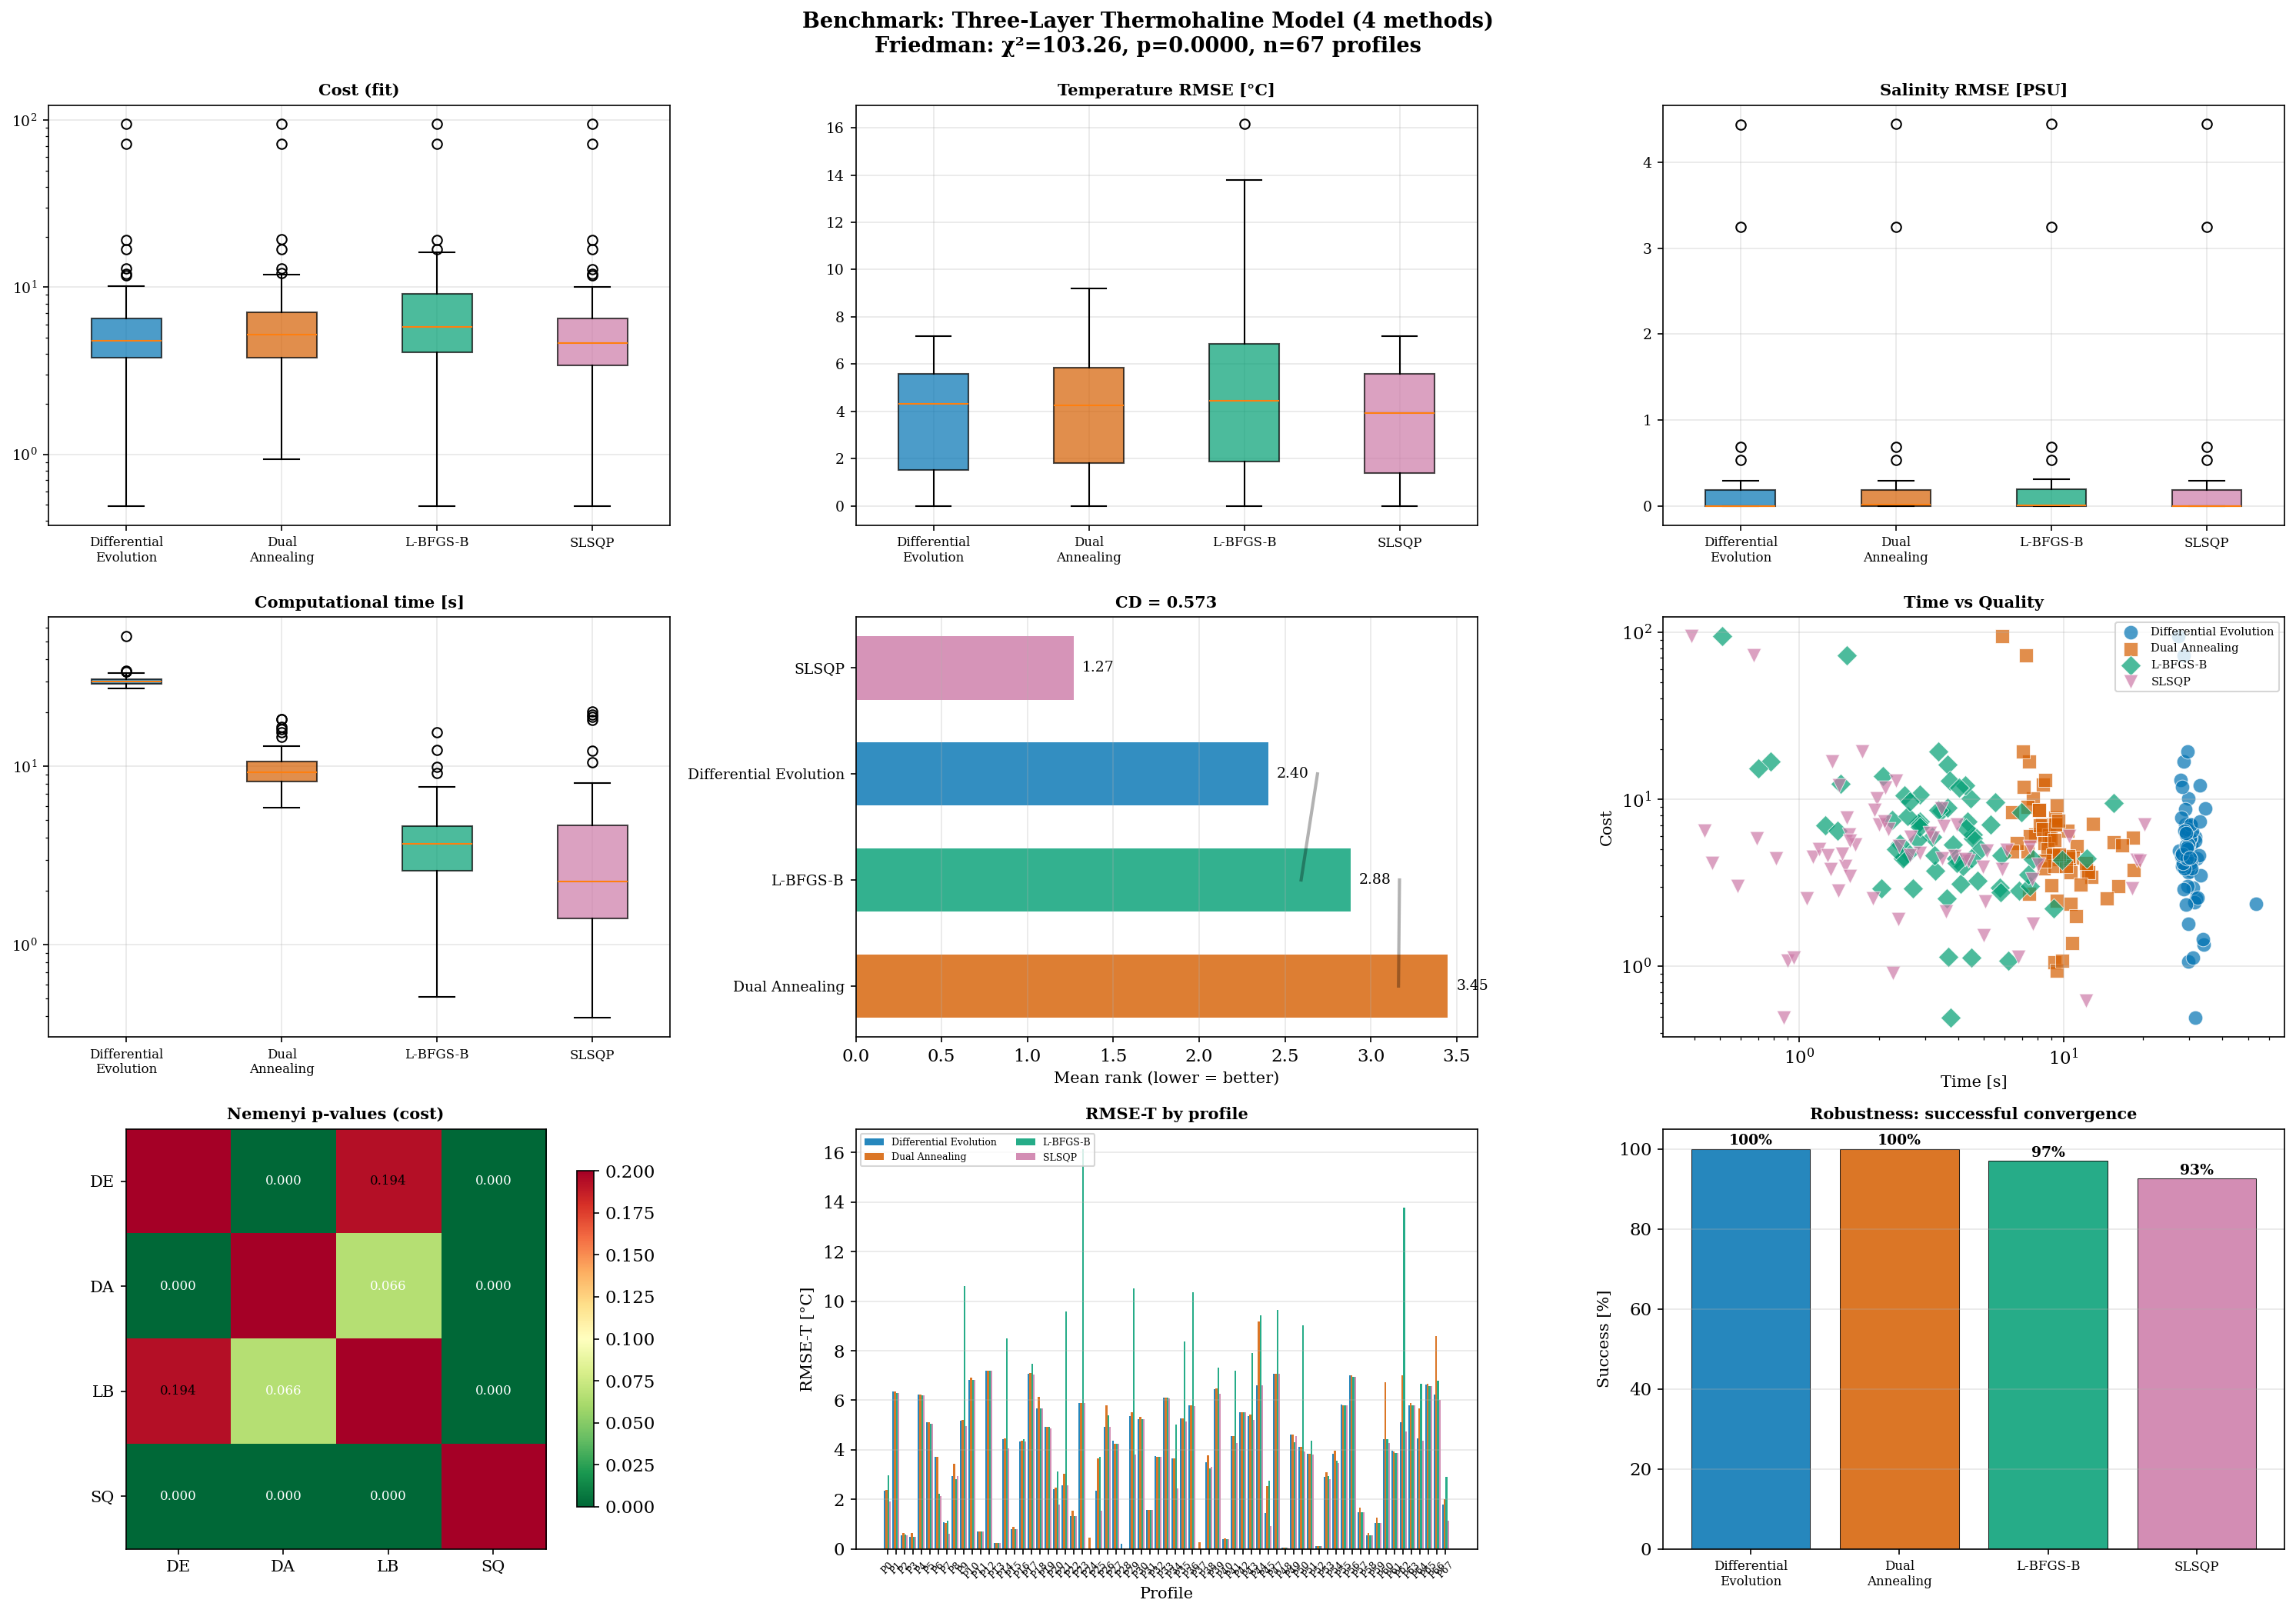


SUMMARY TABLE: STATISTICS BY METHOD (medians)
Method                       Cost     RMSE_T     RMSE_S      Time[s]       Nfev Success%
------------------------------------------------------------------------------------------
Differential Evolution     4.7638     4.3372     0.0000       29.715      13116     100%
Dual Annealing             5.2101     4.2527     0.0134        9.246       3729     100%
L-BFGS-B                   5.8117     4.4368     0.0082        3.669        968      97%
SLSQP                      4.6290     3.9355     0.0000        2.256        841      93%

Methods included:
  • DE / DA : Global metaheuristics (Storn & Price 1997; Xiang et al. 1997)
  • L-BFGS-B / SLSQP : Gradient-based local (Byrd et al. 1995; Kraft 1988)



In [ ]:
# ==============================================================================
# CELL 7: STATISTICAL ANALYSIS (FRIEDMAN + NEMENYI) + VISUALISATIONS + TABLE
# ==============================================================================
methods_list = ['DE', 'DA', 'LB', 'SQ']
n_methods = len(methods_list)

def safe_get(result_dict, method, key, default=np.nan):
    if method not in result_dict:
        return default
    return result_dict[method].get(key, default)

def nemenyi_posthoc(data, alpha=0.05):
    data = np.asarray(data)
    n_blocks, n_algos = data.shape
    ranks = np.zeros_like(data, dtype=float)
    for i in range(n_blocks):
        ranks[i, :] = stats.rankdata(data[i, :])
    mean_ranks = np.mean(ranks, axis=0)
    q_alpha = qsturng(1 - alpha, n_algos, np.inf) / np.sqrt(2)
    cd = q_alpha * np.sqrt(n_algos * (n_algos + 1) / (6 * n_blocks))
    p_matrix = np.ones((n_algos, n_algos))
    se = np.sqrt(n_algos * (n_algos + 1) / (6 * n_blocks))
    for i in range(n_algos):
        for j in range(i + 1, n_algos):
            diff = abs(mean_ranks[i] - mean_ranks[j])
            z = diff / se
            p_val = 2 * (1 - stats.norm.cdf(z))
            p_matrix[i, j] = min(p_val * n_algos * (n_algos - 1) / 2, 1.0)
            p_matrix[j, i] = p_matrix[i, j]
    return p_matrix, cd, mean_ranks, ranks

cost_matrix = np.full((n_profiles, n_methods), np.nan)
time_matrix = np.full((n_profiles, n_methods), np.nan)
rmseT_matrix = np.full((n_profiles, n_methods), np.nan)
rmseS_matrix = np.full((n_profiles, n_methods), np.nan)
nfev_matrix = np.full((n_profiles, n_methods), np.nan)

for i, p in enumerate(valid_profile_ids):
    for j, m in enumerate(methods_list):
        cost_val = safe_get(results[p], m, 'cost', np.nan)
        time_val = safe_get(results[p], m, 'time', np.nan)
        rmseT_val = safe_get(results[p], m, 'rmse_T', np.nan)
        rmseS_val = safe_get(results[p], m, 'rmse_S', np.nan)
        nfev_val = safe_get(results[p], m, 'nfev', 0)
        cost_matrix[i, j] = cost_val if np.isfinite(cost_val) else 1e10
        time_matrix[i, j] = time_val if np.isfinite(time_val) else 1e10
        rmseT_matrix[i, j] = rmseT_val if np.isfinite(rmseT_val) else 1e10
        rmseS_matrix[i, j] = rmseS_val if np.isfinite(rmseS_val) else 1e10
        nfev_matrix[i, j] = nfev_val

valid_methods_per_profile = np.sum(cost_matrix < 1e9, axis=1)
print(f"\nProfiles with all methods: {np.sum(valid_methods_per_profile == n_methods)}")
print(f"Profiles with partial data: {np.sum(valid_methods_per_profile < n_methods)}")

min_methods_required = 3

def run_friedman_nemenyi_robust(matrix, metric_name, methods_list):
    n_profiles, n_methods = matrix.shape
    valid_counts = np.sum(np.isfinite(matrix) & (matrix < 1e9), axis=1)
    valid_rows = valid_counts >= min_methods_required
    if np.sum(valid_rows) < 3:
        return None, f"Only {np.sum(valid_rows)} profiles with ≥{min_methods_required} methods"
    valid_data = matrix[valid_rows].copy()
    max_valid = np.nanmax(np.where(np.isfinite(valid_data) & (valid_data < 1e9),
                                   valid_data, np.nan))
    if not np.isfinite(max_valid):
        max_valid = 1e10
    valid_data_imputed = np.where(np.isfinite(valid_data) & (valid_data < 1e9),
                                  valid_data, max_valid * 2)
    try:
        statistic, pvalue = stats.friedmanchisquare(
            *[valid_data_imputed[:, j] for j in range(n_methods)])
    except ValueError as e:
        return None, f"Error in Friedman: {str(e)}"
    p_matrix, cd, mean_ranks, ranks = nemenyi_posthoc(valid_data_imputed)
    return {'friedman_stat': statistic, 'friedman_p': pvalue, 'nemenyi_cd': cd,
            'mean_ranks': mean_ranks, 'p_matrix': p_matrix, 'ranks': ranks,
            'valid_profiles': valid_data_imputed.shape[0]}, None

metrics = {
    'Cost (fit)': cost_matrix,
    'Temperature RMSE [°C]': rmseT_matrix,
    'Salinity RMSE [PSU]': rmseS_matrix,
    'Computational time [s]': time_matrix,
    'Function evaluations': nfev_matrix,
}

print("\n" + "="*70)
print("STATISTICAL RESULTS: FRIEDMAN + NEMENYI")
print("="*70)

statistical_results = {}
for metric_name, data_matrix in metrics.items():
    res, err = run_friedman_nemenyi_robust(data_matrix, metric_name, methods_list)
    statistical_results[metric_name] = res
    print(f"\n--- {metric_name} ---")
    if err:
        print(f"ERROR: {err}")
        continue
    print(f"Valid profiles: {res['valid_profiles']}")
    print(f"Friedman χ² = {res['friedman_stat']:.4f}, p-value = {res['friedman_p']:.6f}")
    print("→ SIGNIFICANT DIFFERENCES (p < 0.05)" if res['friedman_p'] < 0.05
          else "→ No significant differences (p ≥ 0.05)")
    print(f"\nCritical Difference (Nemenyi): CD = {res['nemenyi_cd']:.4f}")
    print("Mean ranks (lower = better):")
    for j, m in enumerate(methods_list):
        print(f"  {METHOD_NAMES[m]:22s}: {res['mean_ranks'][j]:.3f}")
    print("\nNemenyi p-values matrix:")
    print("      " + "".join([f"{m:>10s}" for m in methods_list]))
    for i, mi in enumerate(methods_list):
        row = f"{mi:>6s}"
        for j, mj in enumerate(methods_list):
            row += f"{'    ---':>10s}" if i == j else f"{res['p_matrix'][i,j]:>10.4f}"
        print(row)
    print("\nSignificantly different pairs (p < 0.05):")
    sig_pairs = []
    for i in range(n_methods):
        for j in range(i + 1, n_methods):
            if res['p_matrix'][i, j] < 0.05:
                better = i if res['mean_ranks'][i] < res['mean_ranks'][j] else j
                worse = j if better == i else i
                sig_pairs.append((methods_list[better], methods_list[worse],
                                  res['p_matrix'][i, j]))
    if sig_pairs:
        for b, w, pv in sorted(sig_pairs, key=lambda x: x[2]):
            print(f"  {METHOD_NAMES[b]} > {METHOD_NAMES[w]}  (p={pv:.4f})")
    else:
        print("  No significant pairs")

# ------------------------------------------------------------------------------
# VISUALISATIONS
# ------------------------------------------------------------------------------
fig = plt.figure(figsize=(20, 14))
metrics_plot = [
    ('Cost (fit)', cost_matrix, 'log'),
    ('Temperature RMSE [°C]', rmseT_matrix, 'linear'),
    ('Salinity RMSE [PSU]', rmseS_matrix, 'linear'),
    ('Computational time [s]', time_matrix, 'log'),
]
for idx, (title, data, scale) in enumerate(metrics_plot):
    ax = plt.subplot(3, 3, idx + 1)
    plot_data = []
    for j in range(n_methods):
        vd = data[:, j]
        vd = vd[np.isfinite(vd) & (vd < 1e9)]
        plot_data.append(vd if len(vd) > 0 else [0])
    bp = ax.boxplot(plot_data,
                    labels=[METHOD_NAMES[m].replace(' ', '\n') for m in methods_list],
                    patch_artist=True)
    for patch, m in zip(bp['boxes'], methods_list):
        patch.set_facecolor(CB_COLORS[m]); patch.set_alpha(0.7)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.tick_params(axis='x', labelsize=8); ax.tick_params(axis='y', labelsize=9)
    if scale == 'log':
        ax.set_yscale('log')
    ax.grid(True, alpha=0.3)

ax_cd = plt.subplot(3, 3, 5)
res_cost = statistical_results.get('Cost (fit)')
if res_cost:
    mr, cd = res_cost['mean_ranks'], res_cost['nemenyi_cd']
    order = np.argsort(mr)
    for i, idx in enumerate(order):
        m = methods_list[idx]
        ax_cd.barh(i, mr[idx], color=CB_COLORS[m], alpha=0.8, height=0.6)
        ax_cd.text(mr[idx] + 0.05, i, f'{mr[idx]:.2f}', va='center', fontsize=9)
    for i in range(n_methods):
        for j in range(i + 1, n_methods):
            if abs(mr[order[i]] - mr[order[j]]) < cd:
                y_i, y_j = list(order).index(order[i]), list(order).index(order[j])
                ax_cd.plot([mr[order[j]] - cd/2, mr[order[i]] + cd/2],
                           [y_j, y_i], 'k-', alpha=0.3, linewidth=2)
    ax_cd.set_yticks(range(n_methods))
    ax_cd.set_yticklabels([METHOD_NAMES[methods_list[i]] for i in order], fontsize=9)
    ax_cd.set_xlabel('Mean rank (lower = better)', fontsize=10)
    ax_cd.set_title(f'CD = {cd:.3f}', fontweight='bold', fontsize=10)
    ax_cd.invert_yaxis(); ax_cd.grid(True, alpha=0.3, axis='x')

ax_sc = plt.subplot(3, 3, 6)
for j, m in enumerate(methods_list):
    valid = (np.isfinite(cost_matrix[:, j]) & np.isfinite(time_matrix[:, j]) &
             (cost_matrix[:, j] < 1e6) & (time_matrix[:, j] < 1e4))
    if np.any(valid):
        ax_sc.scatter(time_matrix[valid, j], cost_matrix[valid, j],
                      c=CB_COLORS[m], label=METHOD_NAMES[m], marker=MARKERS[m],
                      s=80, alpha=0.7, edgecolors='white', linewidth=0.5)
ax_sc.set_xscale('log'); ax_sc.set_yscale('log')
ax_sc.set_xlabel('Time [s]', fontsize=10); ax_sc.set_ylabel('Cost', fontsize=10)
ax_sc.set_title('Time vs Quality', fontweight='bold', fontsize=10)
ax_sc.legend(fontsize=7, loc='upper right'); ax_sc.grid(True, alpha=0.3)

ax_heat = plt.subplot(3, 3, 7)
if res_cost:
    im = ax_heat.imshow(res_cost['p_matrix'], cmap='RdYlGn_r', vmin=0, vmax=0.2)
    ax_heat.set_xticks(range(n_methods)); ax_heat.set_yticks(range(n_methods))
    ax_heat.set_xticklabels(methods_list, fontsize=10)
    ax_heat.set_yticklabels(methods_list, fontsize=10)
    ax_heat.set_title('Nemenyi p-values (cost)', fontweight='bold', fontsize=10)
    plt.colorbar(im, ax=ax_heat, shrink=0.8)
    for i in range(n_methods):
        for j in range(n_methods):
            if i != j:
                color = "white" if res_cost['p_matrix'][i,j] < 0.1 else "black"
                ax_heat.text(j, i, f'{res_cost["p_matrix"][i,j]:.3f}',
                             ha="center", va="center", color=color, fontsize=8)

ax_conv = plt.subplot(3, 3, 8)
x_pos = np.arange(n_profiles); width = 0.2
for j, m in enumerate(methods_list):
    vd = np.where((np.isfinite(rmseT_matrix[:, j]) & (rmseT_matrix[:, j] < 1e6)),
                  rmseT_matrix[:, j], np.nan)
    ax_conv.bar(x_pos + j * width, vd, width, label=METHOD_NAMES[m],
                color=CB_COLORS[m], alpha=0.85)
ax_conv.set_xlabel('Profile', fontsize=10); ax_conv.set_ylabel('RMSE-T [°C]', fontsize=10)
ax_conv.set_title('RMSE-T by profile', fontweight='bold', fontsize=10)
ax_conv.set_xticks(x_pos + width * 1.5)
ax_conv.set_xticklabels([f'P{p}' for p in valid_profile_ids], fontsize=6, rotation=45)
ax_conv.legend(fontsize=6, loc='upper left', ncol=2); ax_conv.grid(True, alpha=0.3, axis='y')

# ==============================================================================
#
# ==============================================================================
ax_rob = plt.subplot(3, 3, 9)
success_rates = [sum(1 for p in valid_profile_ids
                     if safe_get(results[p], m, 'success', False)) / n_profiles * 100
                 for m in methods_list]
bars = ax_rob.bar(range(n_methods), success_rates,
                  color=[CB_COLORS[m] for m in methods_list], alpha=0.85,
                  edgecolor='black', linewidth=0.5)
ax_rob.set_xticks(range(n_methods))
ax_rob.set_xticklabels([METHOD_NAMES[m].replace(' ', '\n') for m in methods_list], fontsize=8)
ax_rob.set_ylabel('Success [%]', fontsize=10)
ax_rob.set_title('Robustness: successful convergence', fontweight='bold', fontsize=10)
ax_rob.set_ylim(0, 105)
for bar, rate in zip(bars, success_rates):
    ax_rob.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{rate:.0f}%', ha='center', fontsize=9, fontweight='bold')
ax_rob.grid(True, alpha=0.3, axis='y')

if res_cost:
    plt.suptitle(
        f'Benchmark: Three-Layer Thermohaline Model (4 methods)\n'
        f'Friedman: χ²={res_cost["friedman_stat"]:.2f}, p={res_cost["friedman_p"]:.4f}, '
        f'n={res_cost["valid_profiles"]} profiles',
        fontsize=13, fontweight='bold', y=0.995)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/benchmark_optimisation_complete.png',
            dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------------------
# SUMMARY TABLE
# ------------------------------------------------------------------------------
print("\n" + "="*90)
print("SUMMARY TABLE: STATISTICS BY METHOD (medians)")
print("="*90)
print(f"{'Method':<22} {'Cost':>10} {'RMSE_T':>10} {'RMSE_S':>10} "
      f"{'Time[s]':>12} {'Nfev':>10} {'Success%':>8}")
print("-"*90)
for m in methods_list:
    costs = [c for c in (safe_get(results[p], m, 'cost', np.nan) for p in valid_profile_ids)
             if np.isfinite(c) and c < 1e6]
    rmses_t = [r for r in (safe_get(results[p], m, 'rmse_T', np.nan) for p in valid_profile_ids)
               if np.isfinite(r)]
    rmses_s = [r for r in (safe_get(results[p], m, 'rmse_S', np.nan) for p in valid_profile_ids)
               if np.isfinite(r)]
    times = [t for t in (safe_get(results[p], m, 'time', np.nan) for p in valid_profile_ids)
             if np.isfinite(t)]
    nfevs = [n for n in (safe_get(results[p], m, 'nfev', 0) for p in valid_profile_ids)
             if np.isfinite(n)]
    successes = sum(1 for p in valid_profile_ids if safe_get(results[p], m, 'success', False))
    print(f"{METHOD_NAMES[m]:<22} "
          f"{np.median(costs) if costs else np.nan:>10.4f} "
          f"{np.median(rmses_t) if rmses_t else np.nan:>10.4f} "
          f"{np.median(rmses_s) if rmses_s else np.nan:>10.4f} "
          f"{np.median(times) if times else np.nan:>12.3f} "
          f"{np.median(nfevs) if nfevs else 0:>10.0f} "
          f"{successes/n_profiles*100:>7.0f}%")

print("""
Methods included:
  • DE / DA : Global metaheuristics (Storn & Price 1997; Xiang et al. 1997)
  • L-BFGS-B / SLSQP : Gradient-based local (Byrd et al. 1995; Kraft 1988)
""")


# Other version scalated



NumPy: 2.0.2
SciPy: 1.16.3
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Datos: /content/drive/MyDrive/Colab Notebooks/Data/SeaData/20190101_prof.nc
Resultados: /content/drive/MyDrive/Colab Notebooks/Data/SeaData/benchmark_results

Perfiles en archivo: 68
Perfiles válidos: 67
Perfil 0: T=[18.67 12.86  4.65], S=[35.37 35.2  34.5 ]
Perfil 1: T=[29.2  13.62  4.98], S=[35.15 35.14 34.9 ]
Perfil 2: T=[4.07 2.42 2.03], S=[33.88 34.29 34.72]
Perfil 3: T=[5.5  3.86 2.37], S=[33.98 34.13 34.67]
Perfil 4: T=[28.87 13.57  5.38], S=[34.68 35.06 34.86]
Perfil 5: T=[27.59 15.07  4.17], S=[35.15 35.18 34.61]
Perfil 6: T=[19.94 10.65  3.37], S=[35.89 34.95 34.56]
Perfil 7: T=[17.39 14.76  5.78], S=[35.59 35.41 34.52]
Perfil 8: T=[22.51 15.23  8.64], S=[35.6  35.39 34.65]
Perfil 9: T=[26.86 14.04  5.65], S=[36.36 35.58 35.03]
Perfil 10: T=[27.98 11.02  3.97], S=[34.31 34.86 34.89]
Perfil 11: T=[4.4  2.39 1.9 ], S=[33.96 

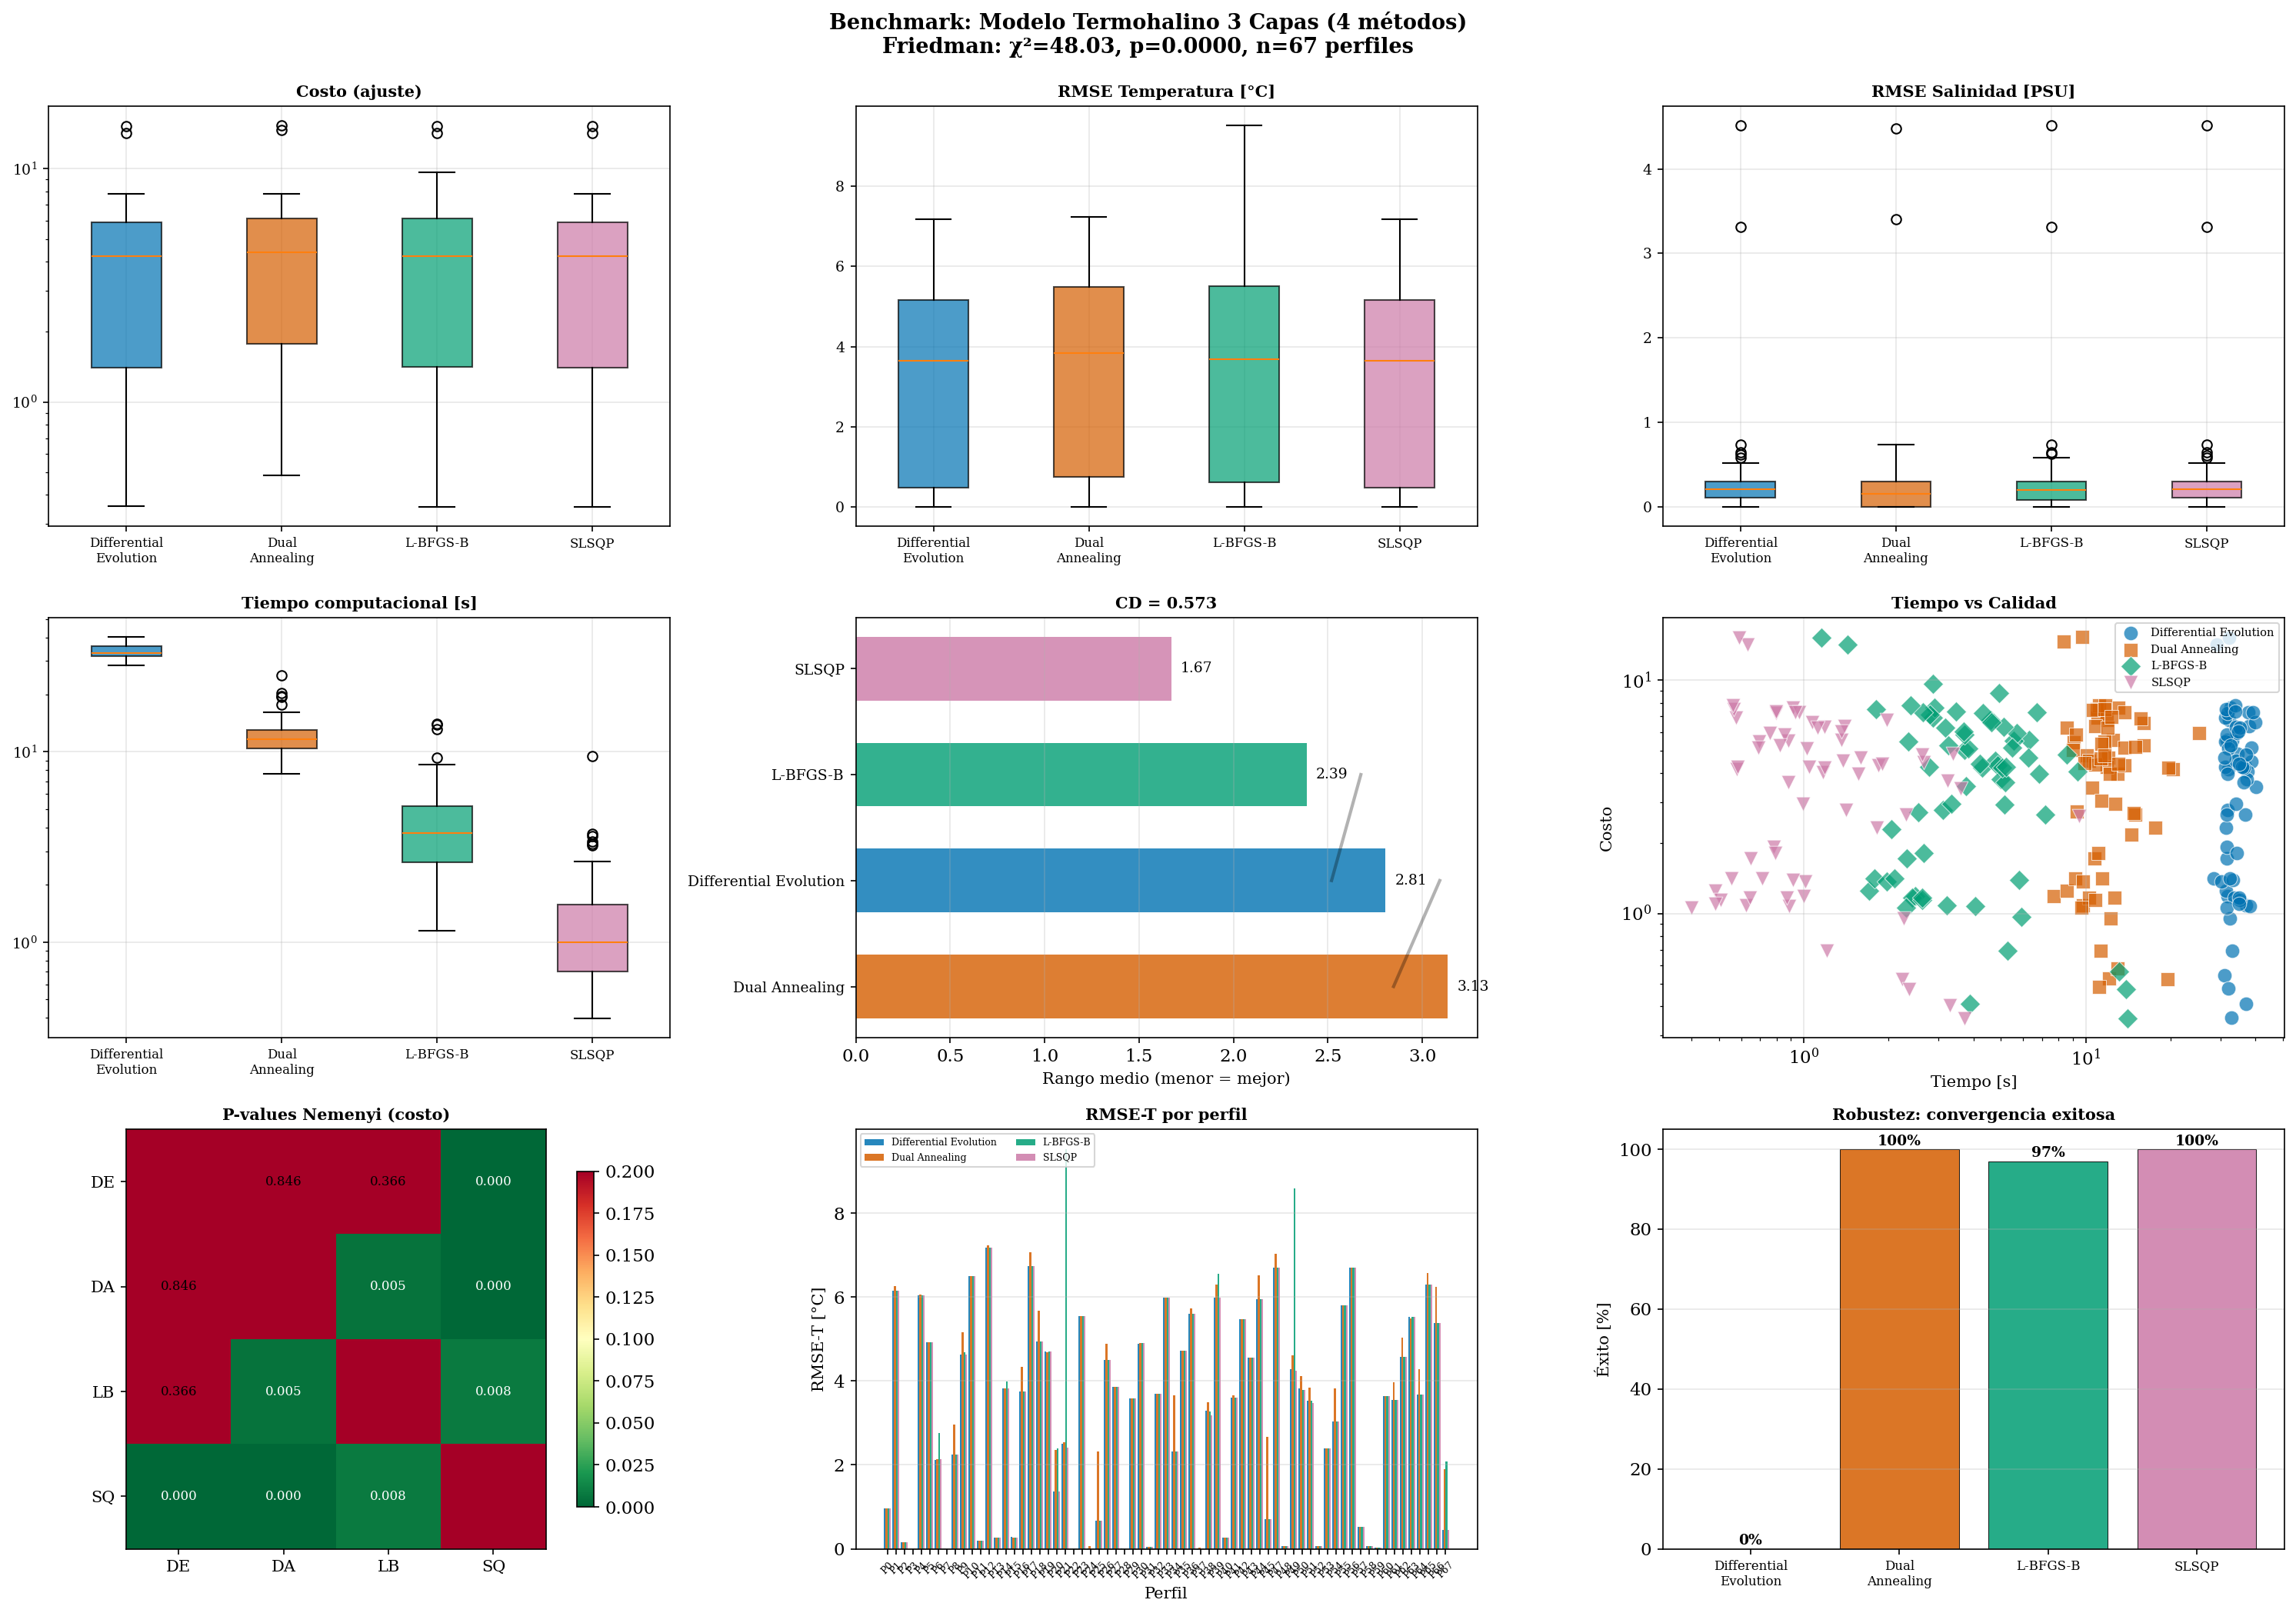


TABLA RESUMEN: ESTADÍSTICAS POR MÉTODO (medianas)
Método                      Costo     RMSE_T     RMSE_S    Tiempo[s]       Nfev   Éxito%
------------------------------------------------------------------------------------------
Differential Evolution     4.2276     3.6428     0.2046       33.173      13068       0%
Dual Annealing             4.3926     3.8296     0.1553       11.617       3969     100%
L-BFGS-B                   4.2360     3.6828     0.1974        3.758        896      97%
SLSQP                      4.2276     3.6428     0.2057        0.995        369     100%

Métodos incluidos:
  • DE / DA : Metaheurísticas globales (Storn & Price 1997; Xiang et al. 1997)
  • L-BFGS-B / SLSQP : Locales basados en gradiente (Byrd et al. 1995; Kraft 1988)


ANÁLISIS DE SENSIBILIDAD DE SOBOL
  Perfil 0: 4096 evals, fallos=0.0%
  Perfil 1: 4096 evals, fallos=0.0%
  Perfil 2: 4096 evals, fallos=0.0%
  Perfil 3: 4096 evals, fallos=0.0%
  Perfil 4: 4096 evals, fallos=0.0%
  Perfil 5: 409

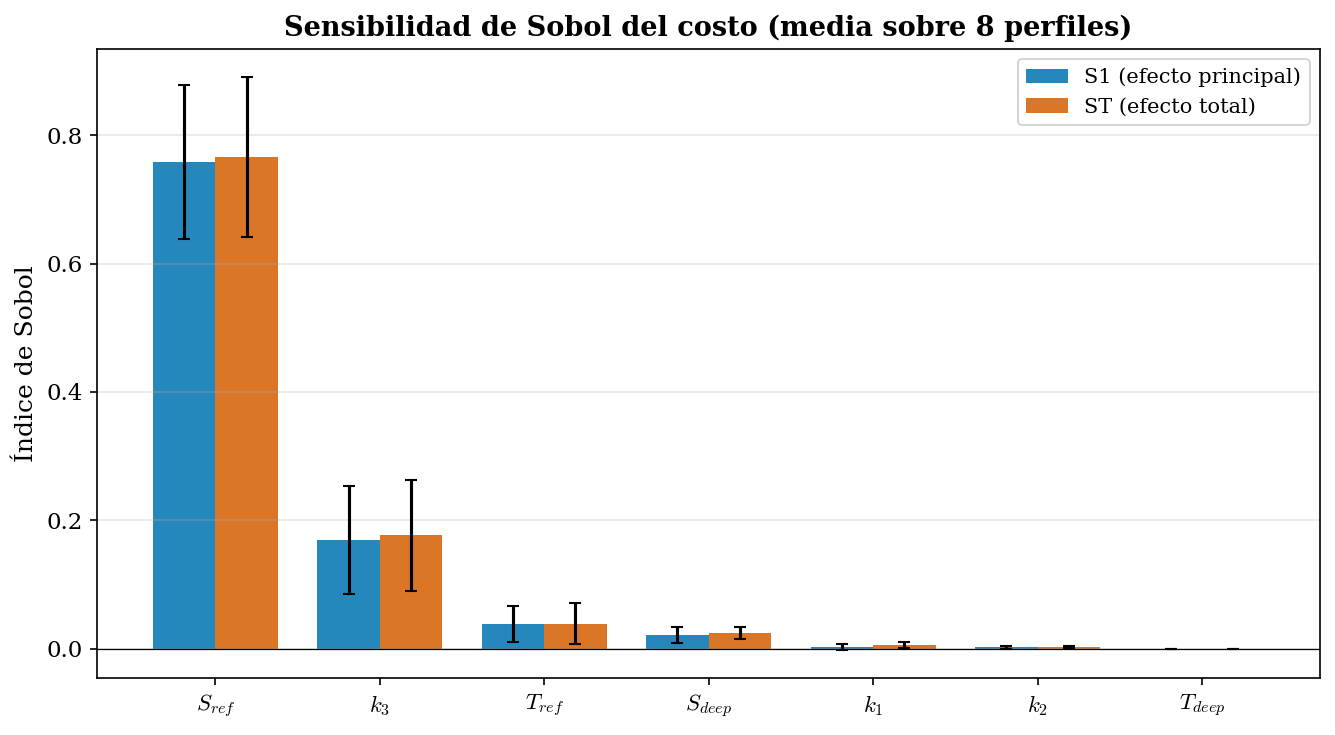

Guardado: sobol_sensitivity.png y sobol_results.json

INTERVALOS DE CONFIANZA BOOTSTRAP (95%, B=300)

Perfil 0:
  k1       =    0.5815  IC95% = [   0.5760,    0.5874]  (σ=0.0032)
  k2       =    0.0104  IC95% = [   0.0082,    0.0138]  (σ=0.0014)
  k3       =    0.2595  IC95% = [   0.2566,    0.2628]  (σ=0.0016)
  T_deep   =    0.1000  IC95% = [   0.1000,    0.1000]  (σ=0.0000)
  T_ref    =    9.7463  IC95% = [   9.4143,   10.0604]  (σ=0.1681)
  S_deep   =   34.2828  IC95% = [  34.2039,   34.3565]  (σ=0.0410)
  S_ref    =   33.0000  IC95% = [  33.0000,   33.0000]  (σ=0.0000)

Perfil 1:
  k1       =    1.3759  IC95% = [   1.0798,    2.5213]  (σ=0.3460)
  k2       =    0.0073  IC95% = [   0.0062,    0.0085]  (σ=0.0006)
  k3       =    0.2543  IC95% = [   0.2471,    0.5984]  (σ=0.0959)
  T_deep   =    0.1000  IC95% = [   0.1000,    0.1000]  (σ=0.0000)
  T_ref    =   18.1923  IC95% = [  16.6598,   21.3941]  (σ=1.1811)
  S_deep   =   34.8721  IC95% = [  34.8326,   34.9155]  (σ=0.0196)
  S_re

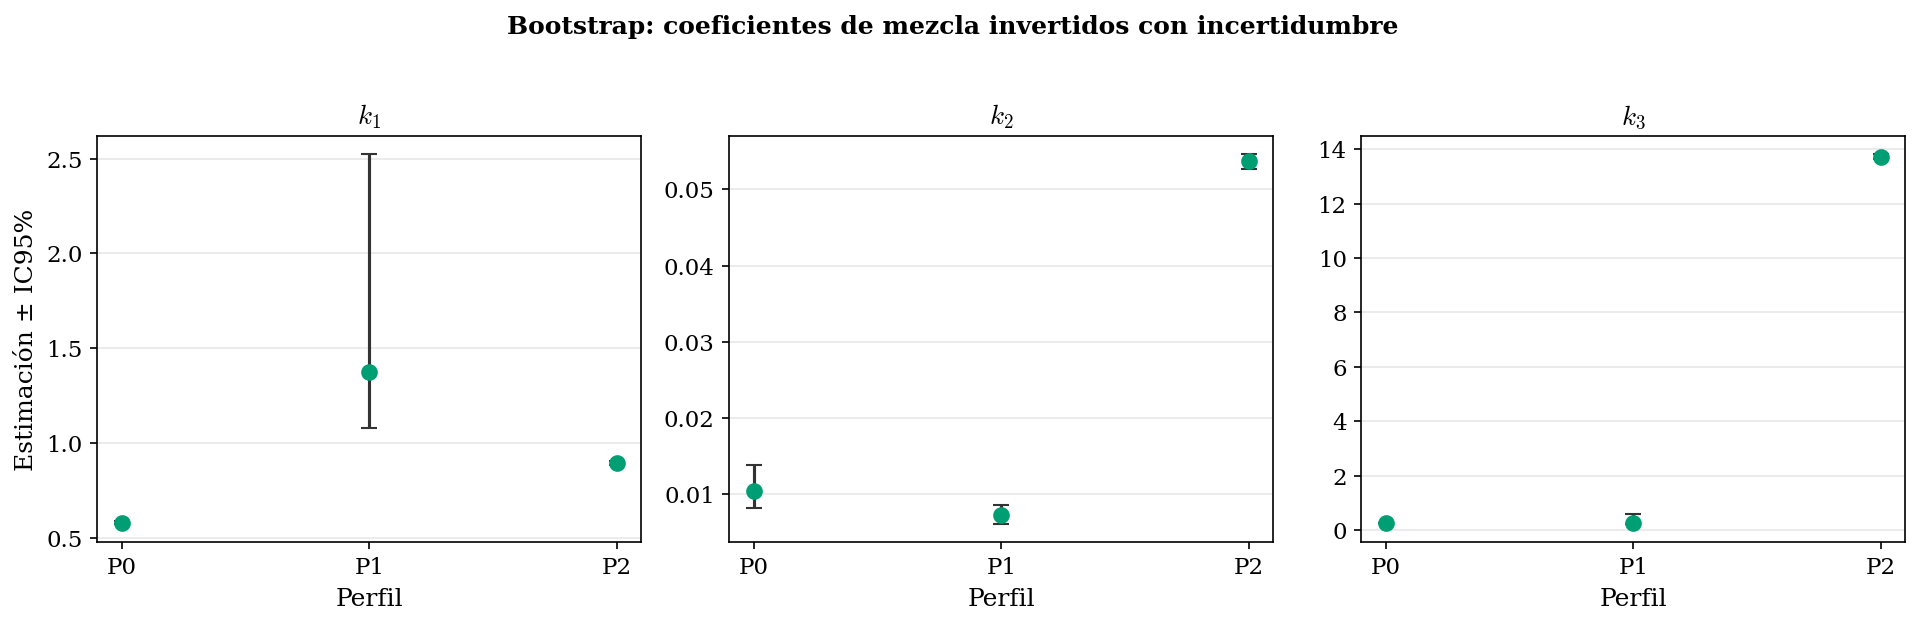

Guardado: bootstrap_ci.png y bootstrap_ci.json

VALIDACIÓN CRUZADA LEAVE-ONE-PROFILE-OUT (k compartidos, método=DE)
  P0    k_fix=[0.86  0.009 0.283]  RMSE_T: cv=1.270 libre=0.958  RMSE_S: cv=0.172 libre=0.289
  P1    k_fix=[0.842 0.009 0.283]  RMSE_T: cv=6.100 libre=6.160  RMSE_S: cv=0.237 libre=0.143
  P2    k_fix=[0.842 0.009 0.282]  RMSE_T: cv=5.925 libre=0.166  RMSE_S: cv=0.901 libre=0.398
  P3    k_fix=[0.842 0.009 0.282]  RMSE_T: cv=4.838 libre=0.000  RMSE_S: cv=0.881 libre=0.237
  P4    k_fix=[0.842 0.009 0.282]  RMSE_T: cv=5.938 libre=6.050  RMSE_S: cv=0.432 libre=0.299
  P5    k_fix=[0.842 0.009 0.283]  RMSE_T: cv=4.974 libre=4.924  RMSE_S: cv=0.255 libre=0.154
  P6    k_fix=[0.86  0.009 0.283]  RMSE_T: cv=2.583 libre=2.128  RMSE_S: cv=0.144 libre=0.000
  P7    k_fix=[0.853 0.009 0.283]  RMSE_T: cv=0.066 libre=0.000  RMSE_S: cv=0.165 libre=0.155
  P8    k_fix=[0.86  0.009 0.283]  RMSE_T: cv=2.378 libre=2.251  RMSE_S: cv=0.149 libre=0.181
  P9    k_fix=[0.86  0.009 0.283]  RMS

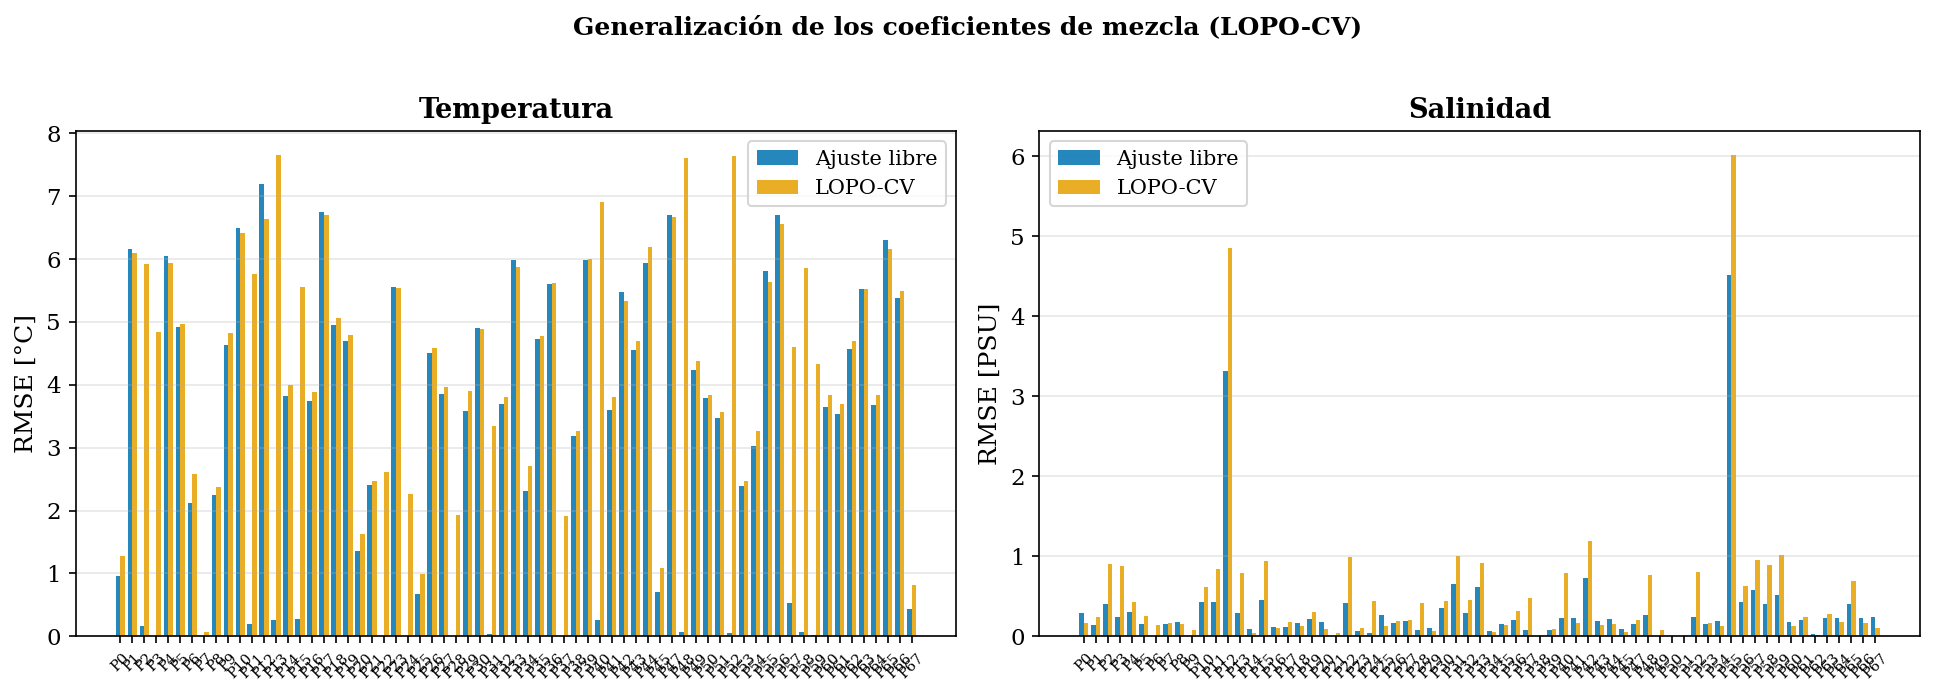

Guardado: lopo_cv.png y lopo_cv.json

Todos los resultados en: /content/drive/MyDrive/Colab Notebooks/Data/SeaData/benchmark_results


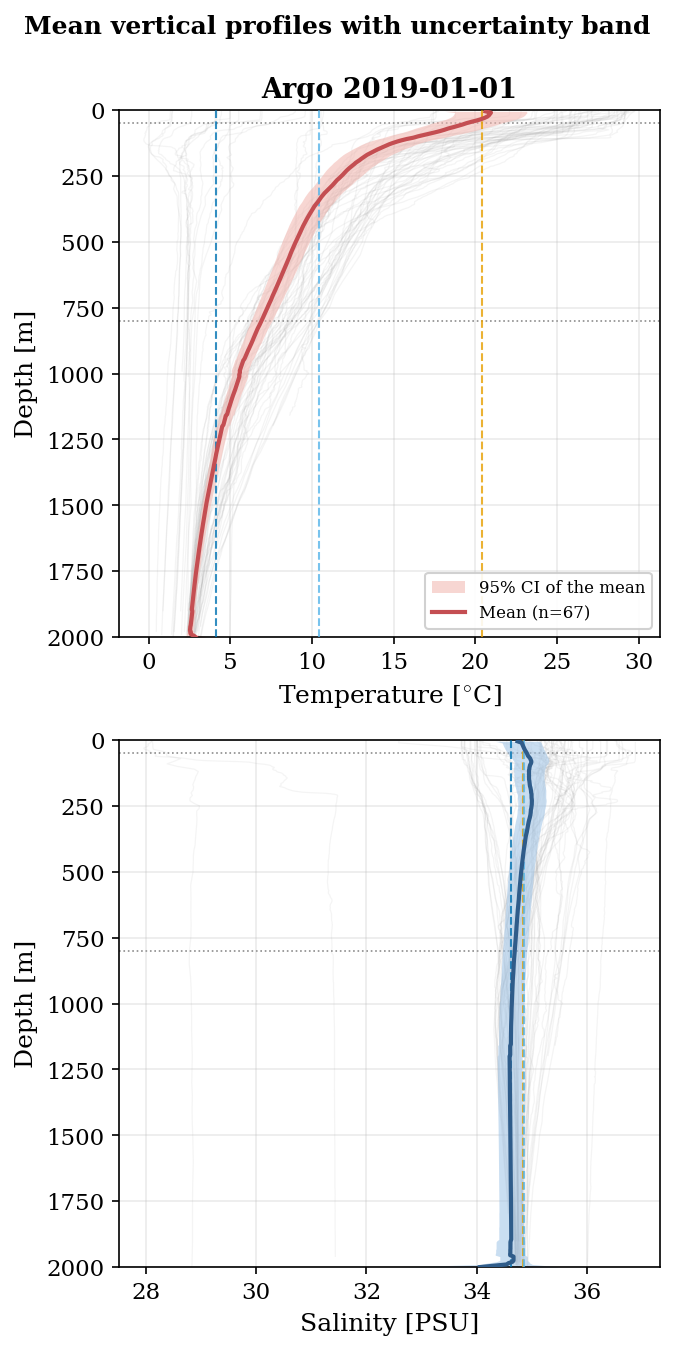

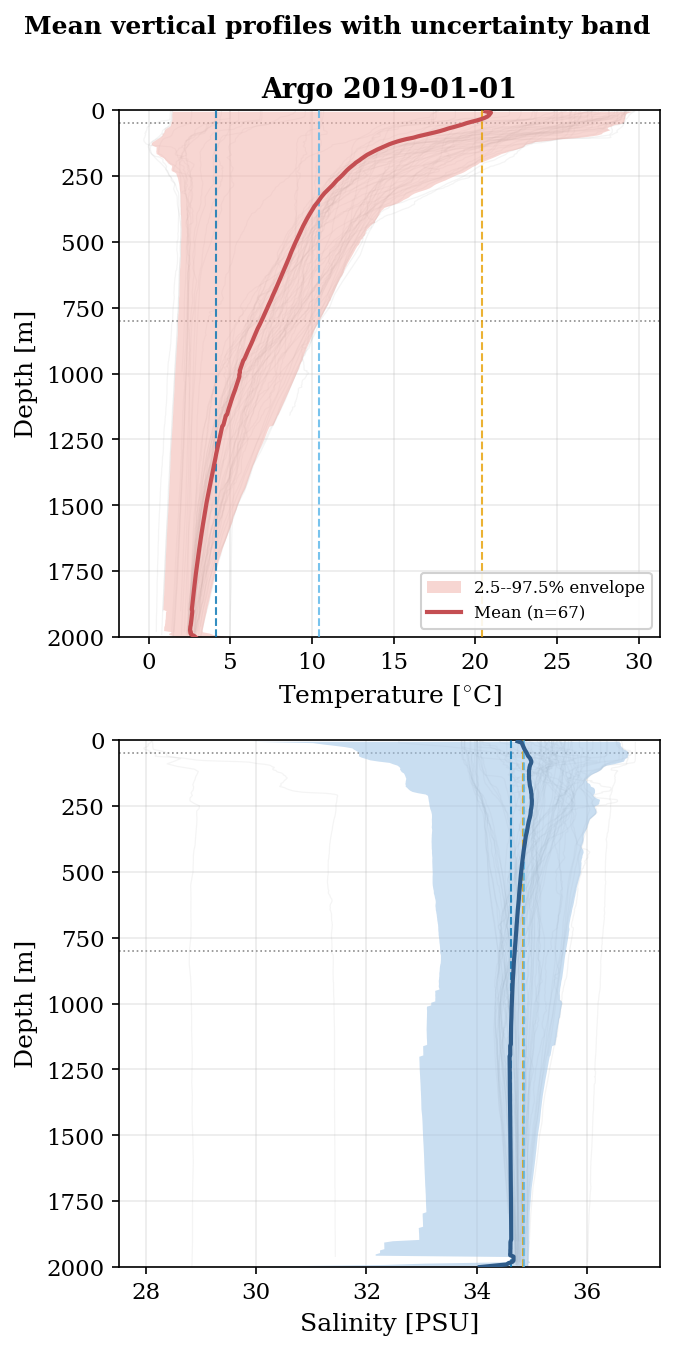


Pipeline completo. Resultados en: /content/drive/MyDrive/Colab Notebooks/Data/SeaData/benchmark_results
Generating English figures (PNG + PDF) ...
  [ok]   fig01_performance_boxplots
  [ok]   fig02_critical_difference
  [ok]   fig03_success_rate
  [ok]   fig04_sobol_sensitivity
  [ok]   fig05_bootstrap_ci
  [ok]   fig06_lopo_cv
  [ok]   fig07_mean_profiles_ci
  [ok]   fig08_mean_profiles_envelope

Displaying 8 figures one by one:



**fig01_performance_boxplots**

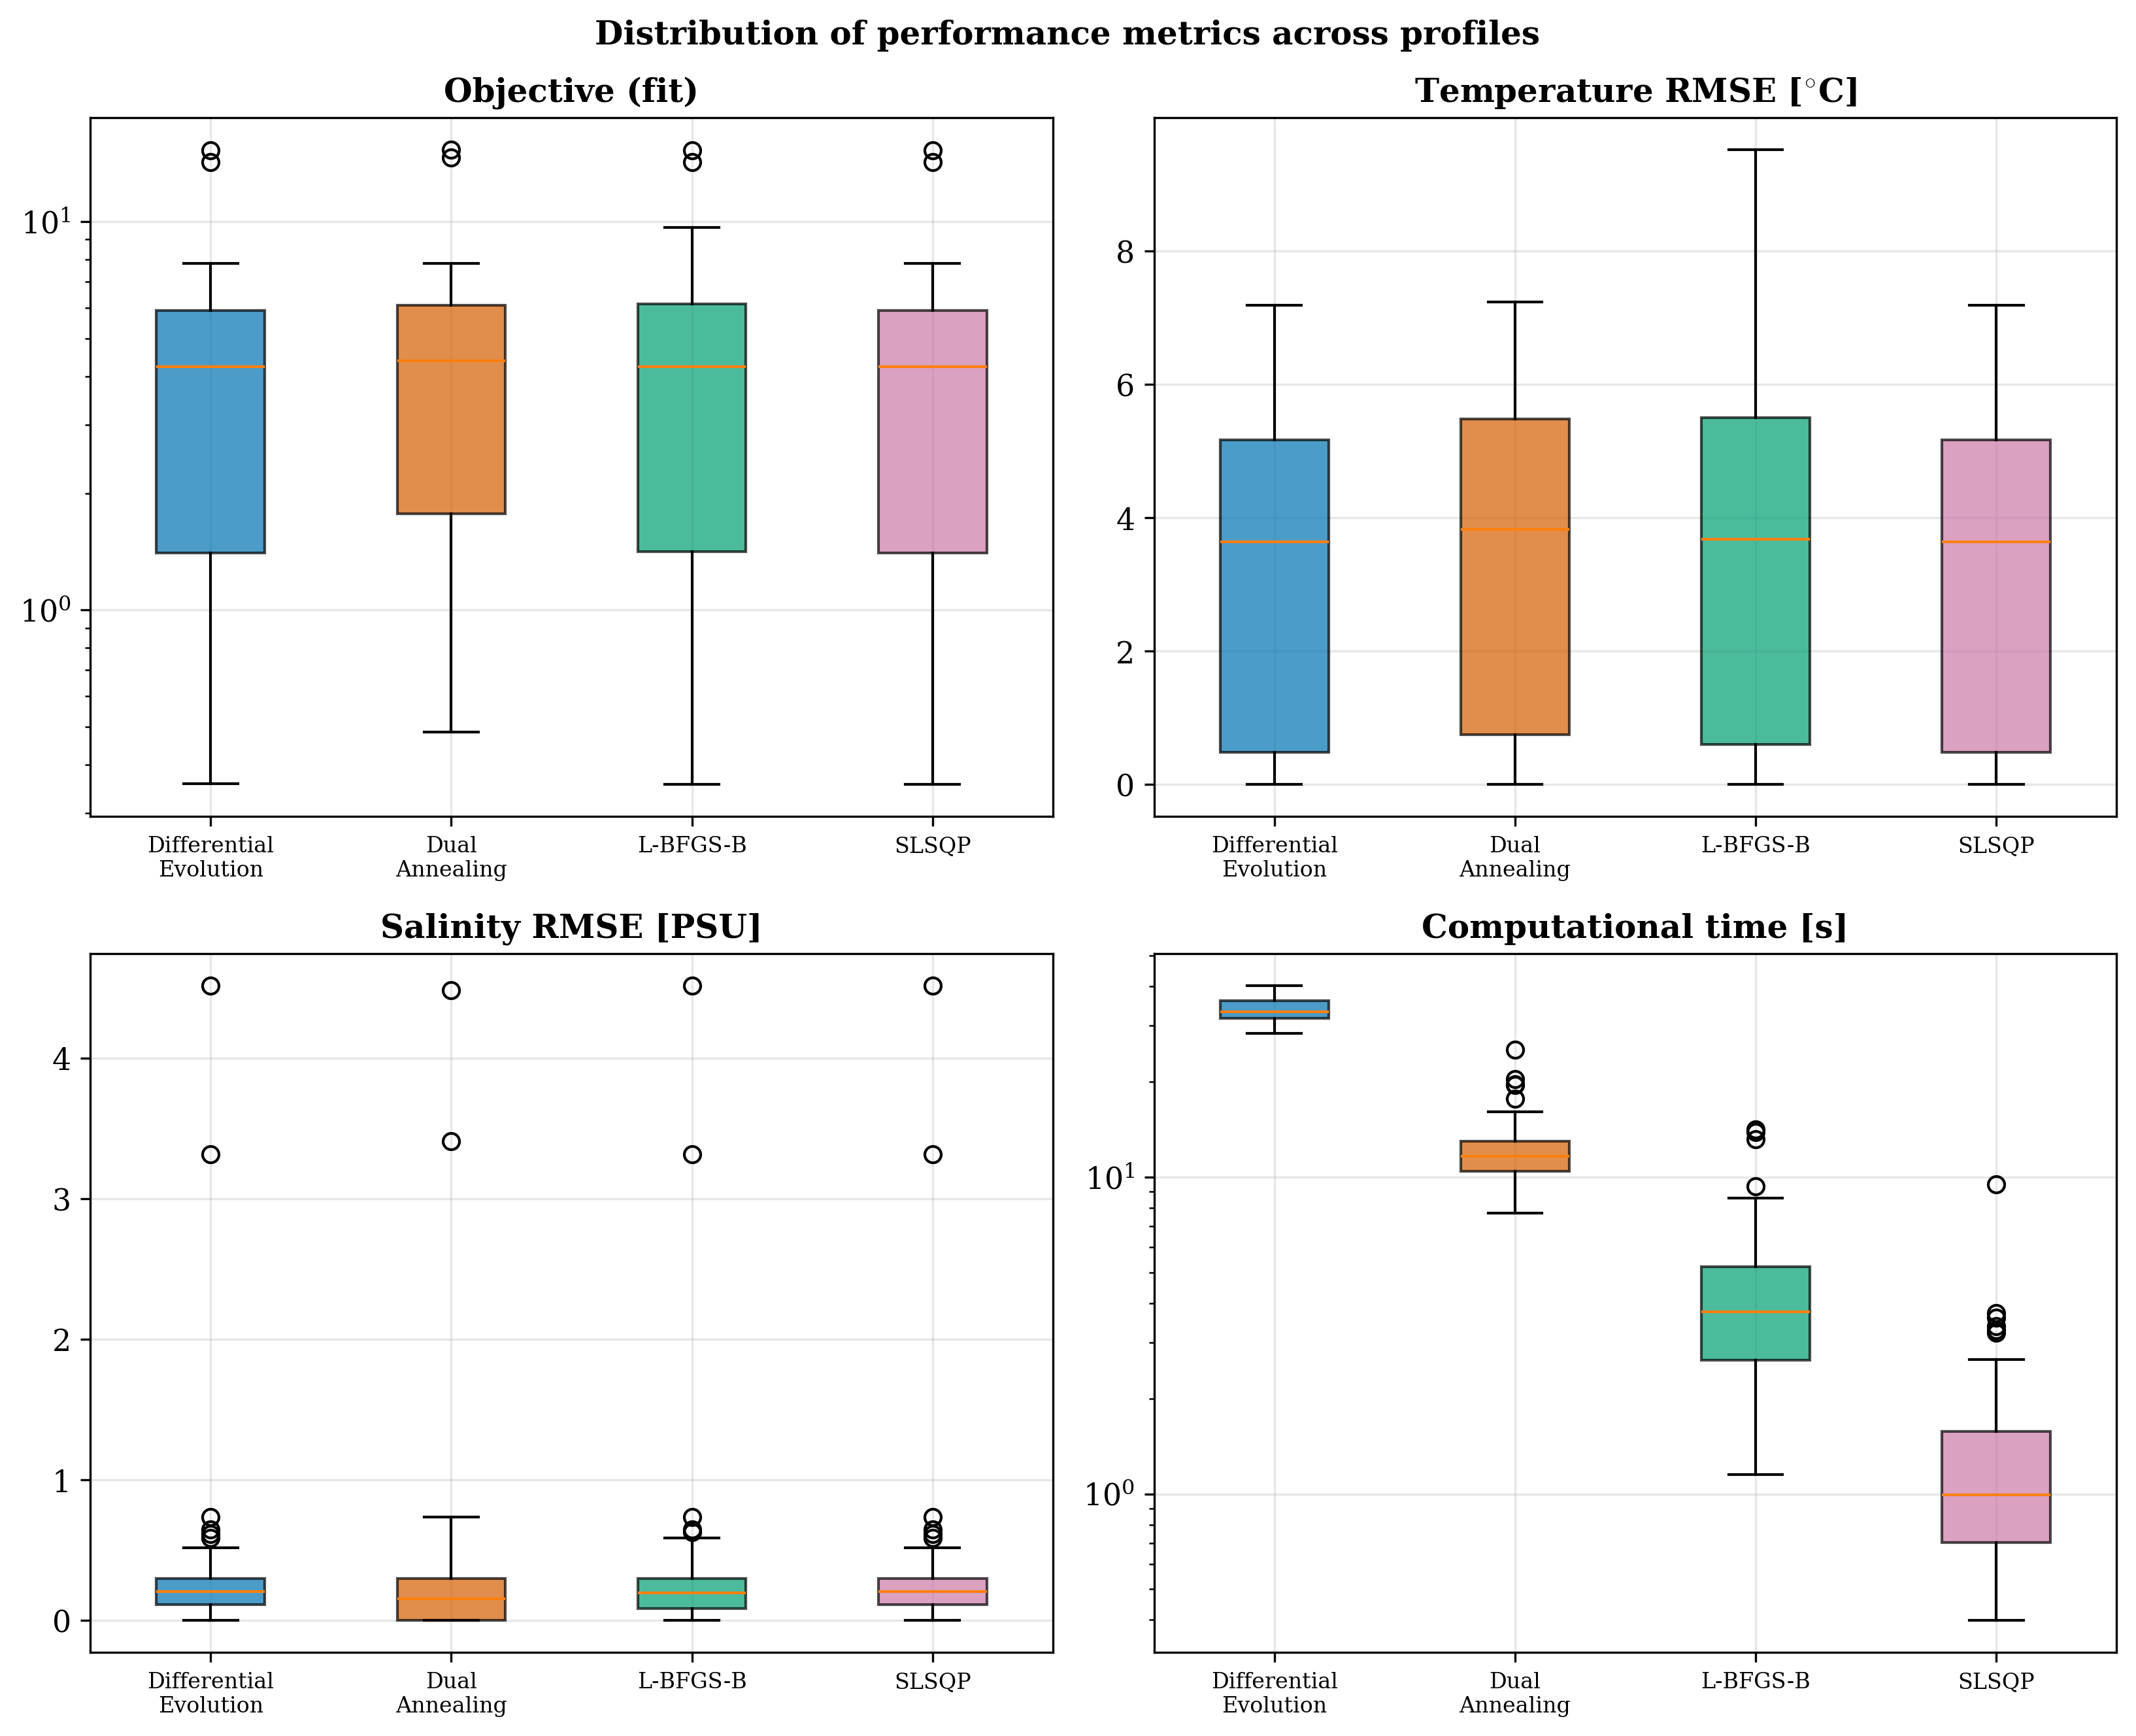

**fig02_critical_difference**

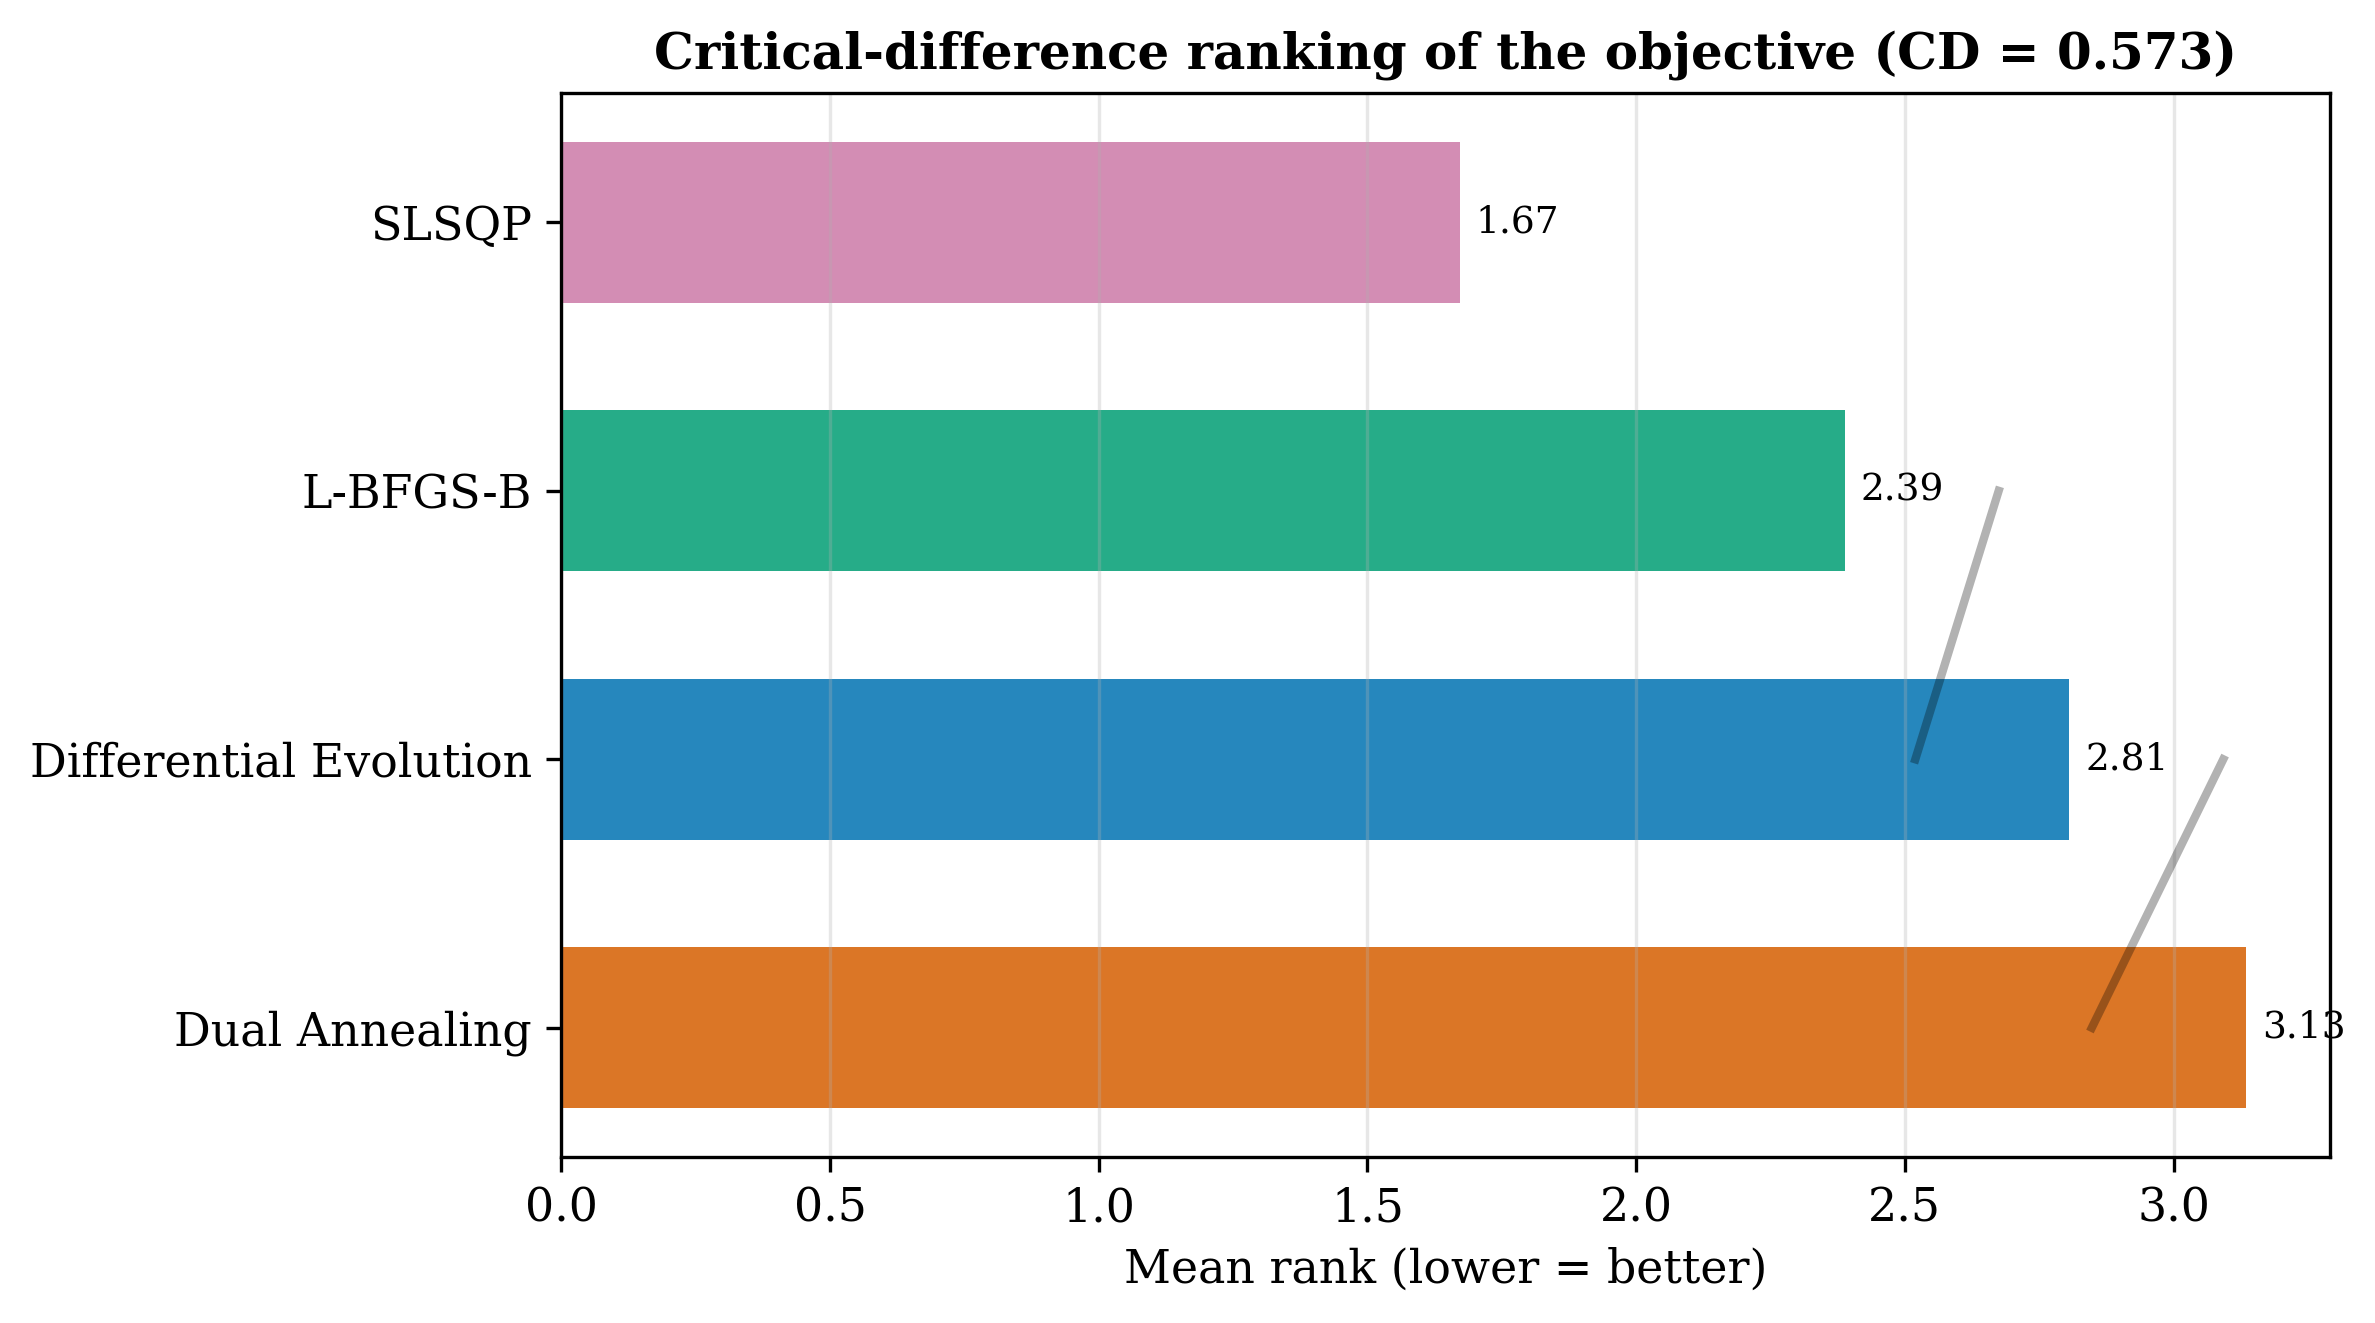

**fig03_success_rate**

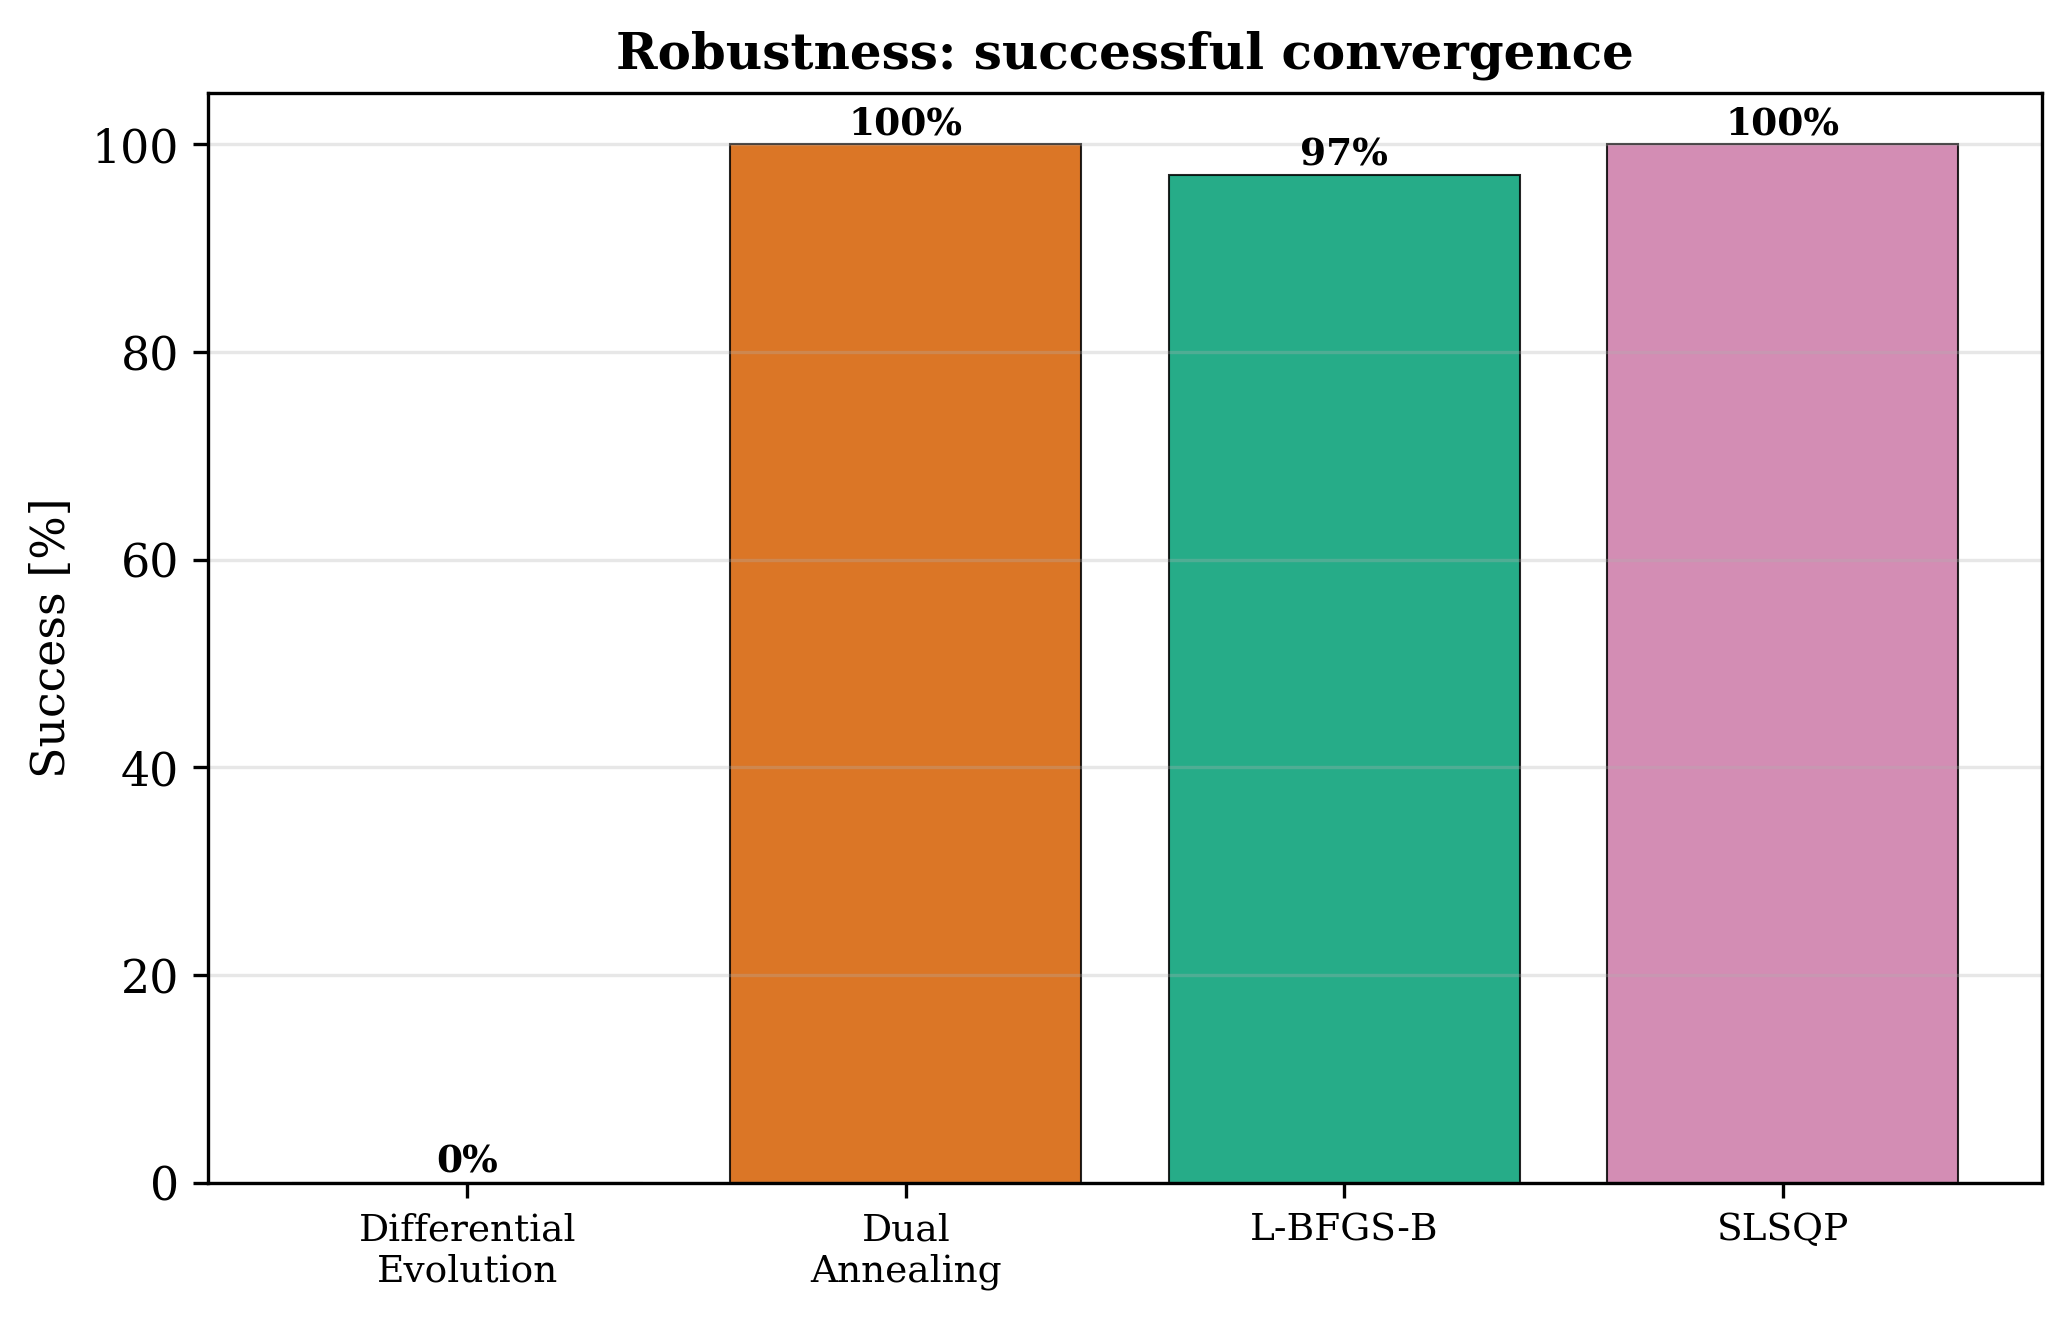

**fig04_sobol_sensitivity**

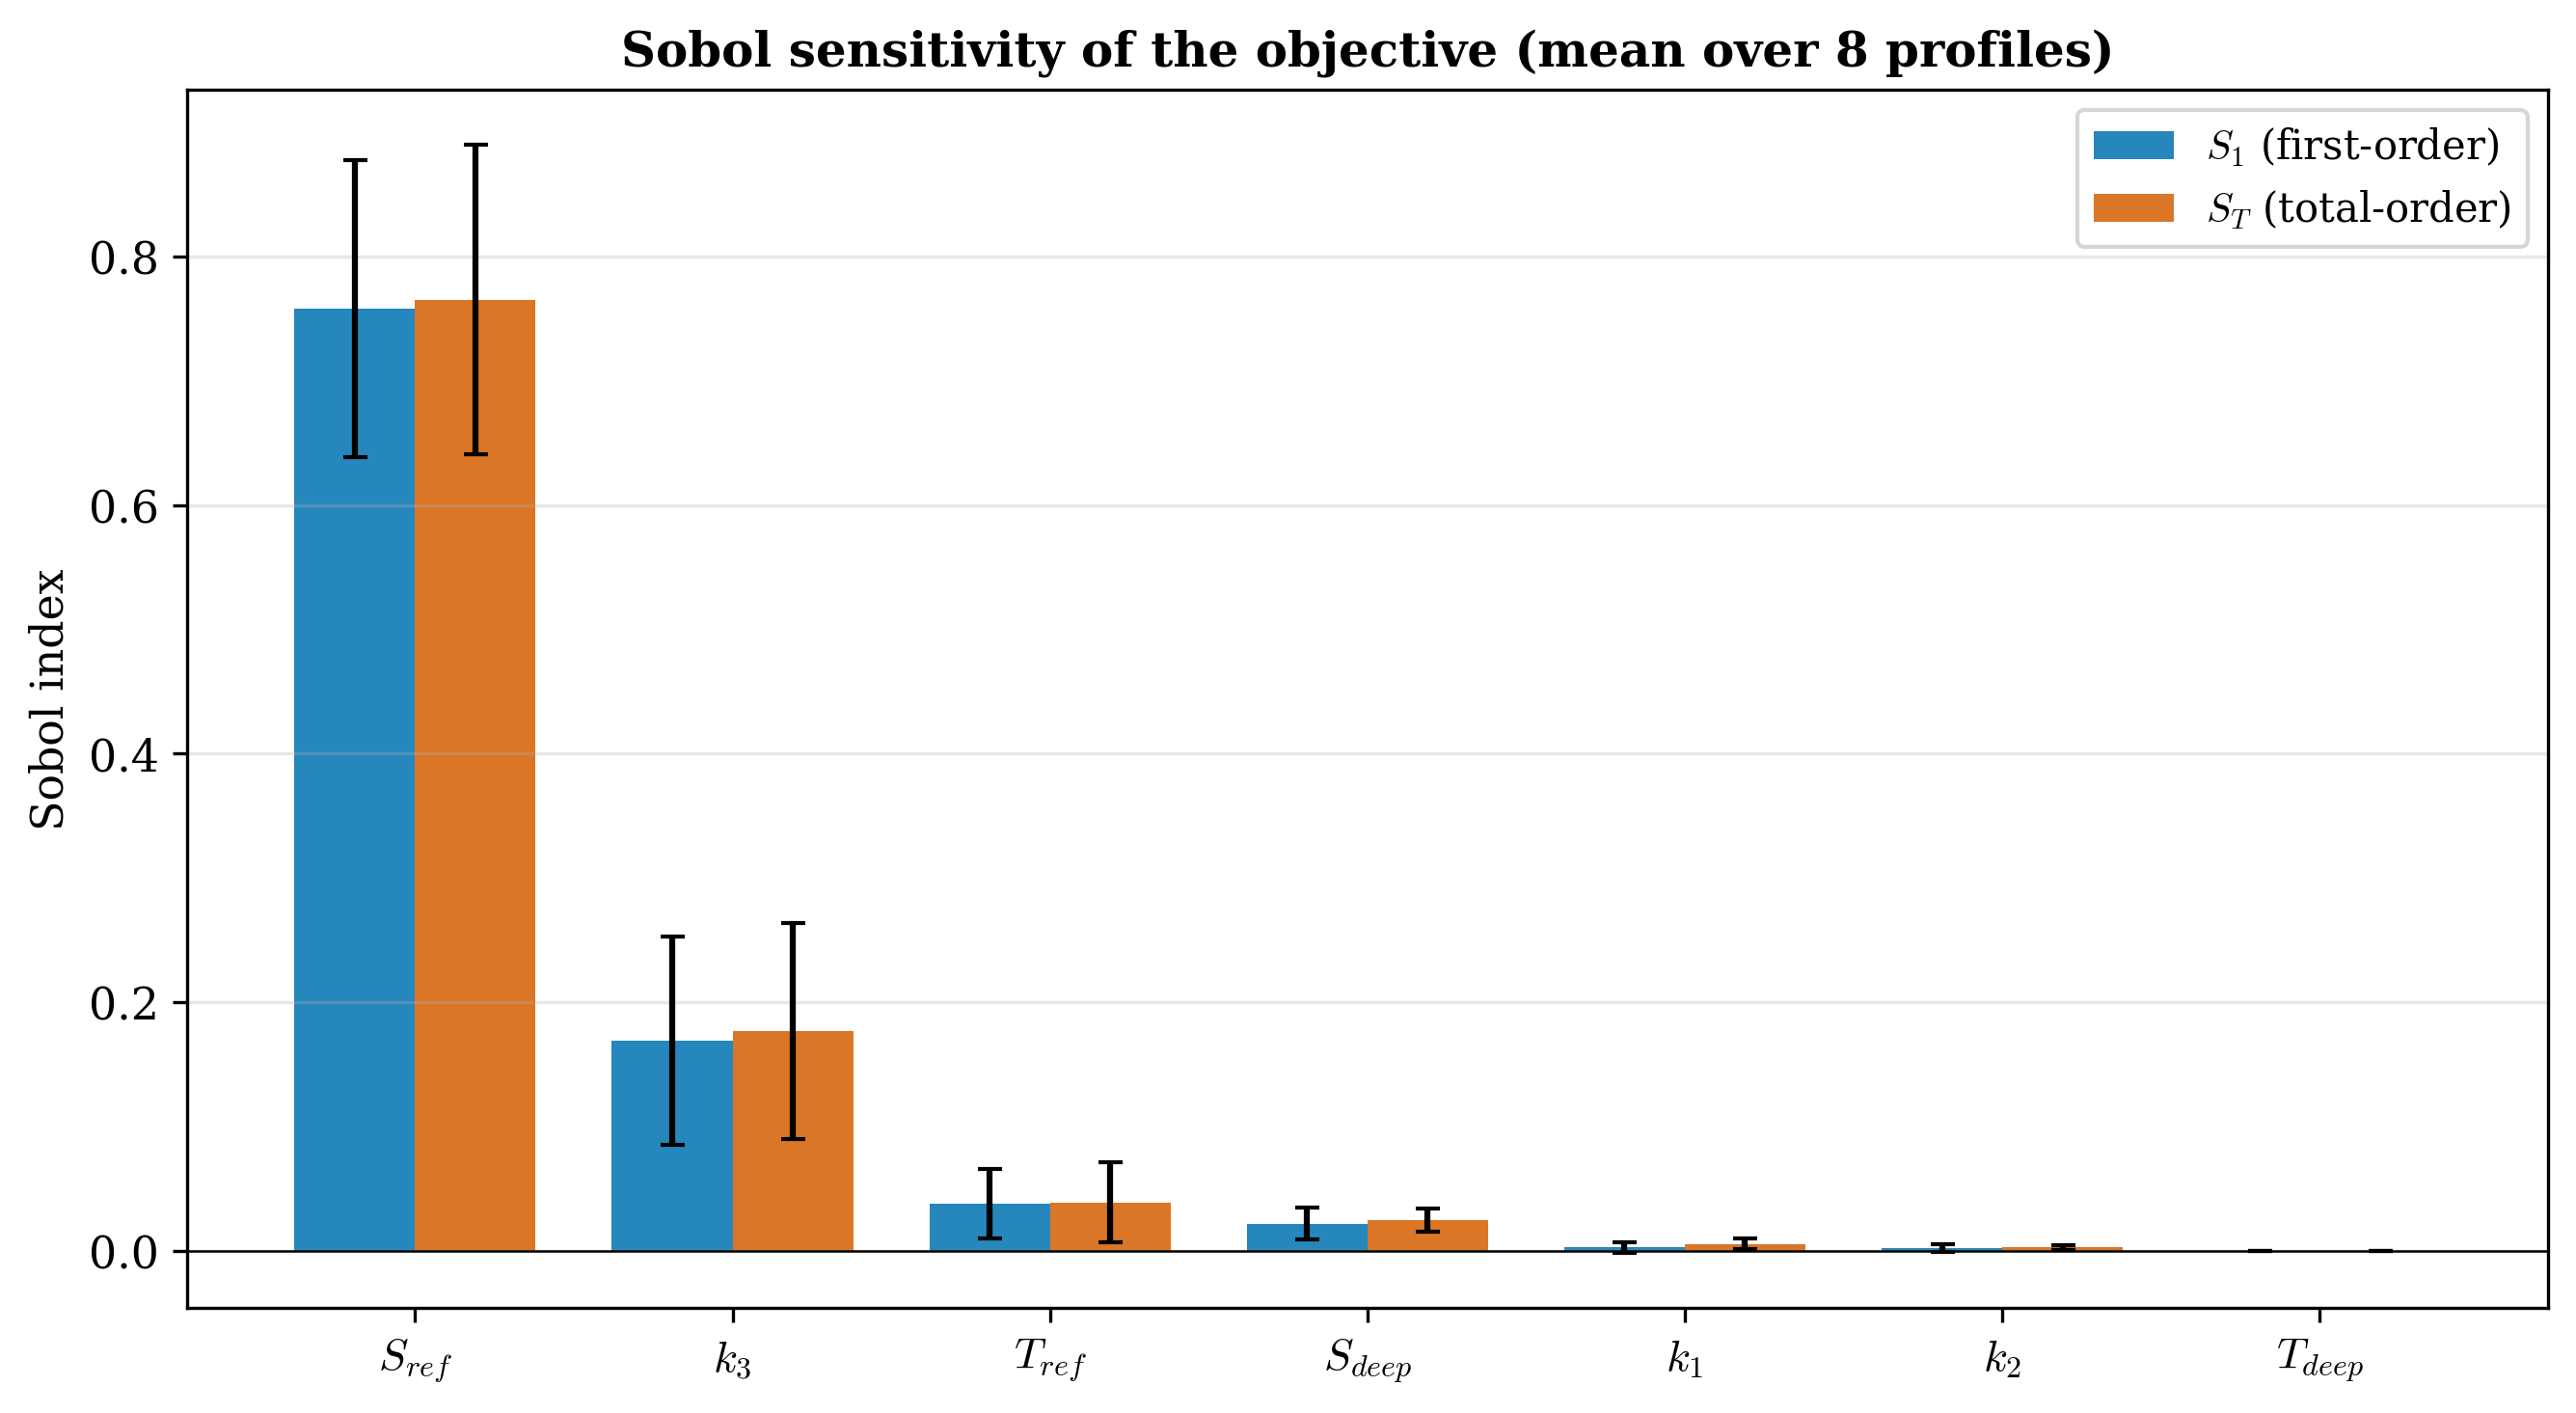

**fig05_bootstrap_ci**

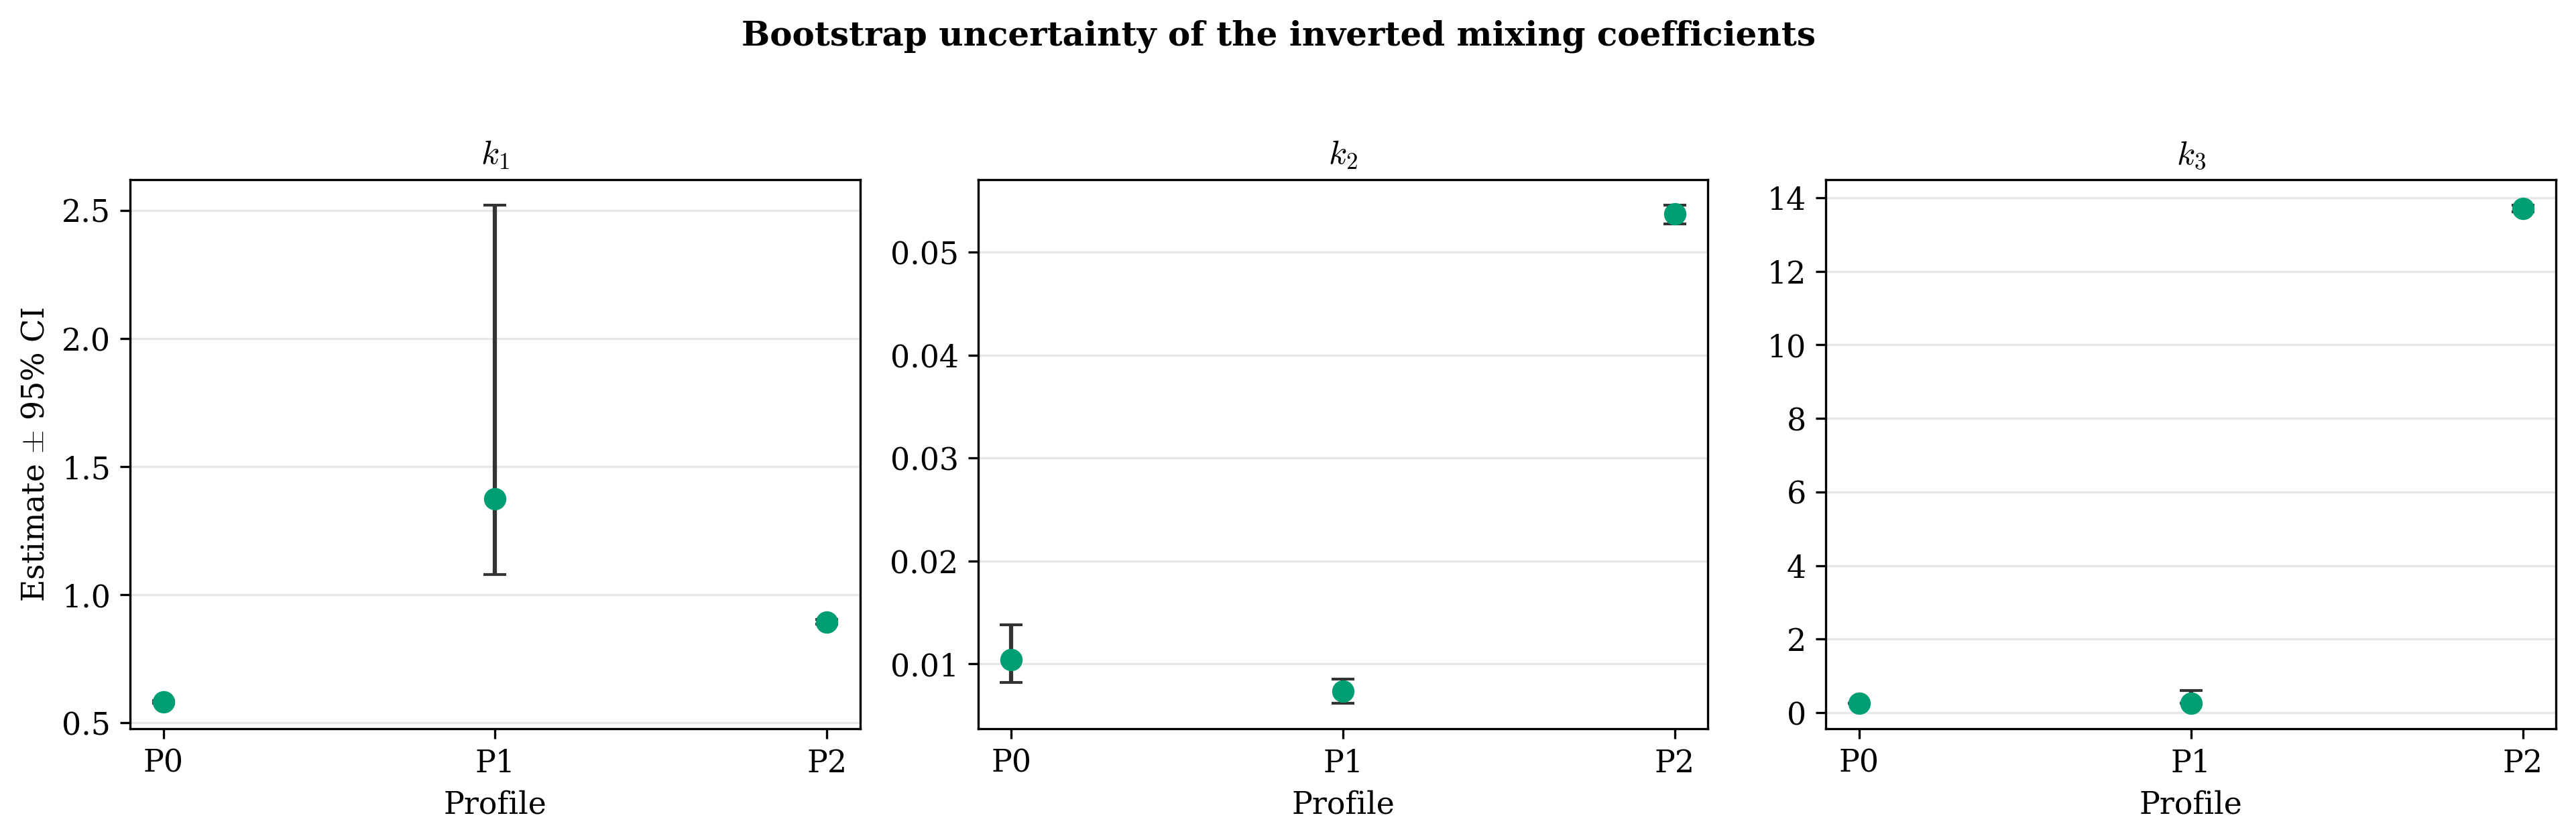

**fig06_lopo_cv**

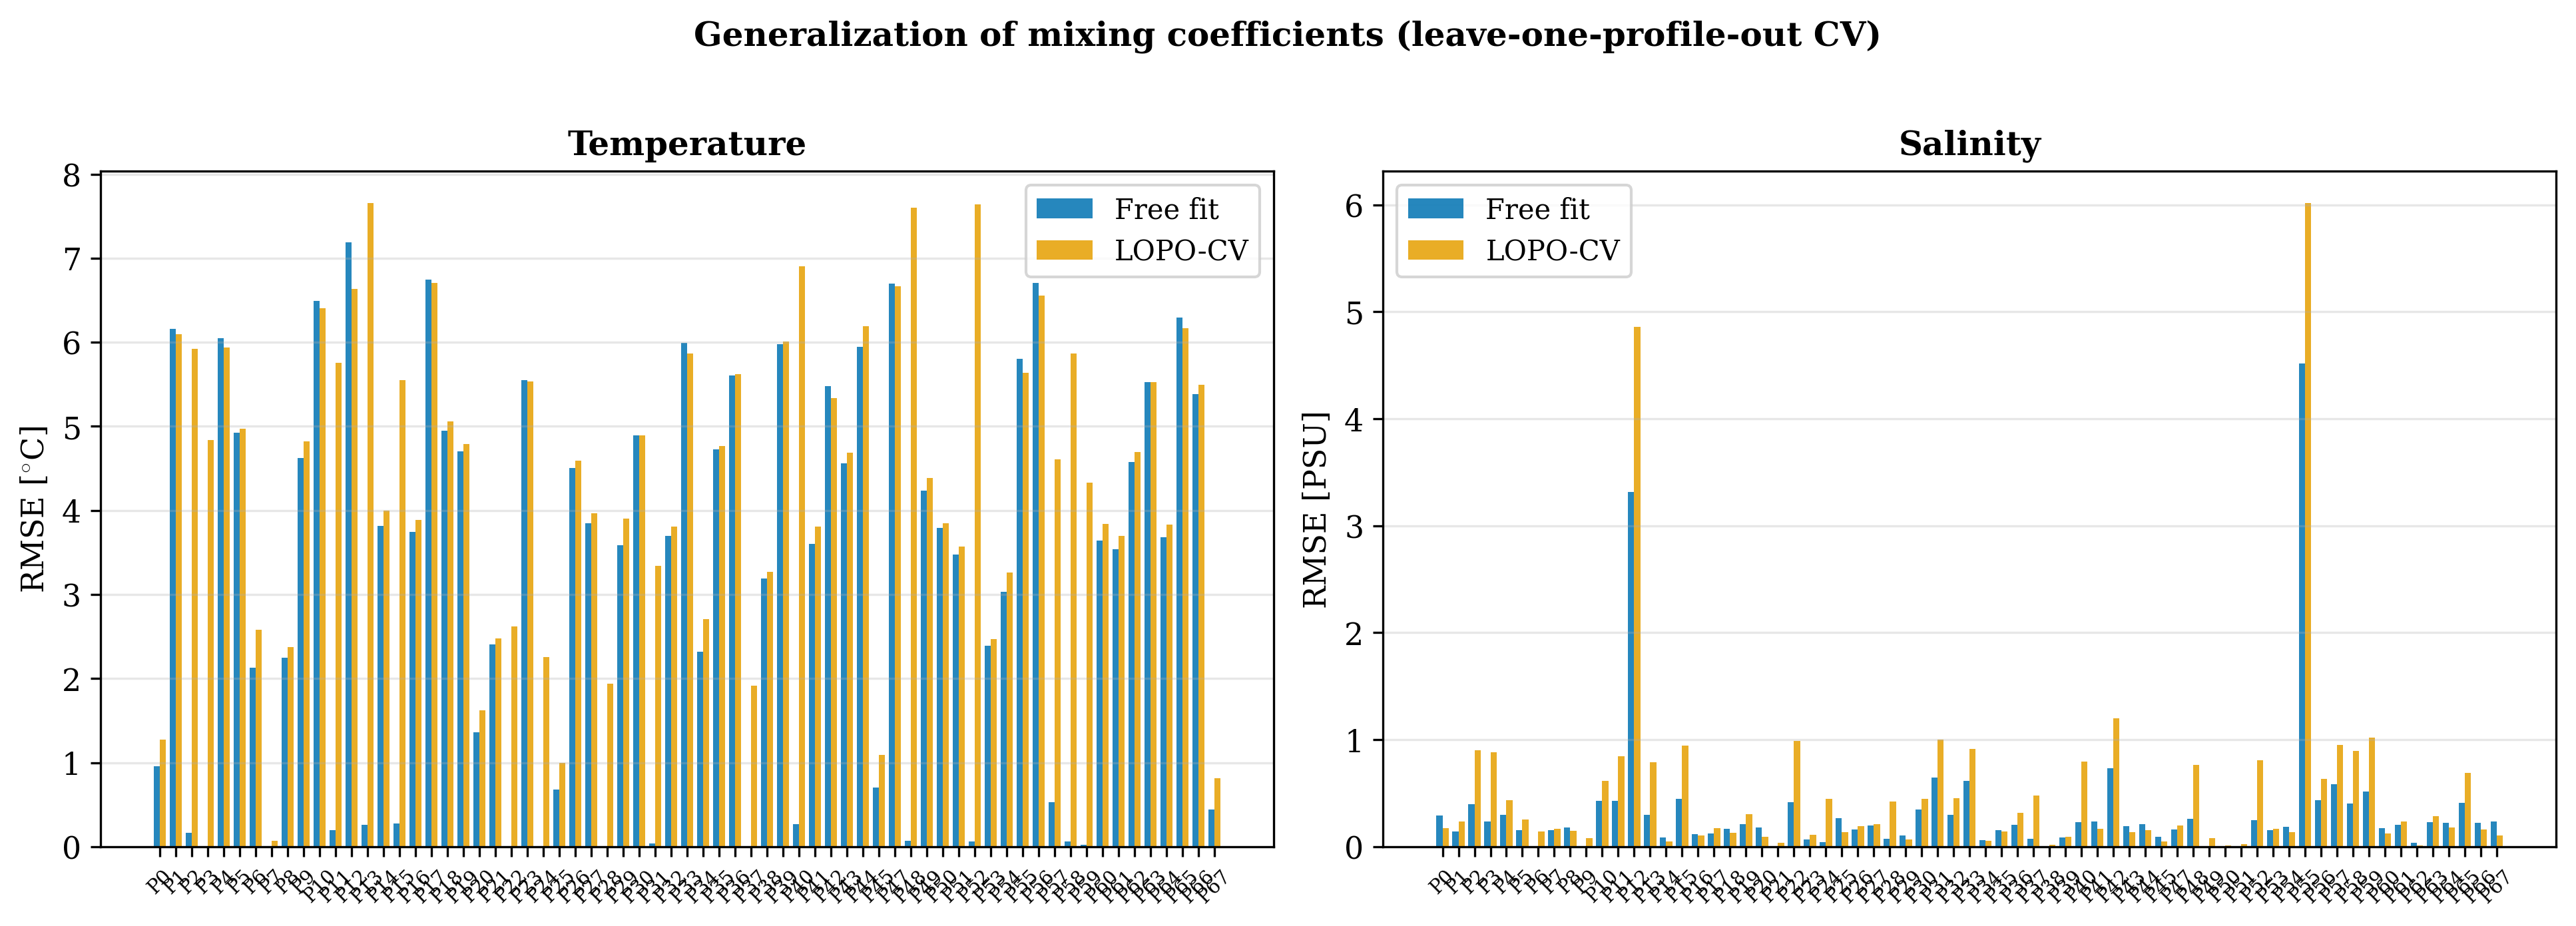

**fig07_mean_profiles_ci**

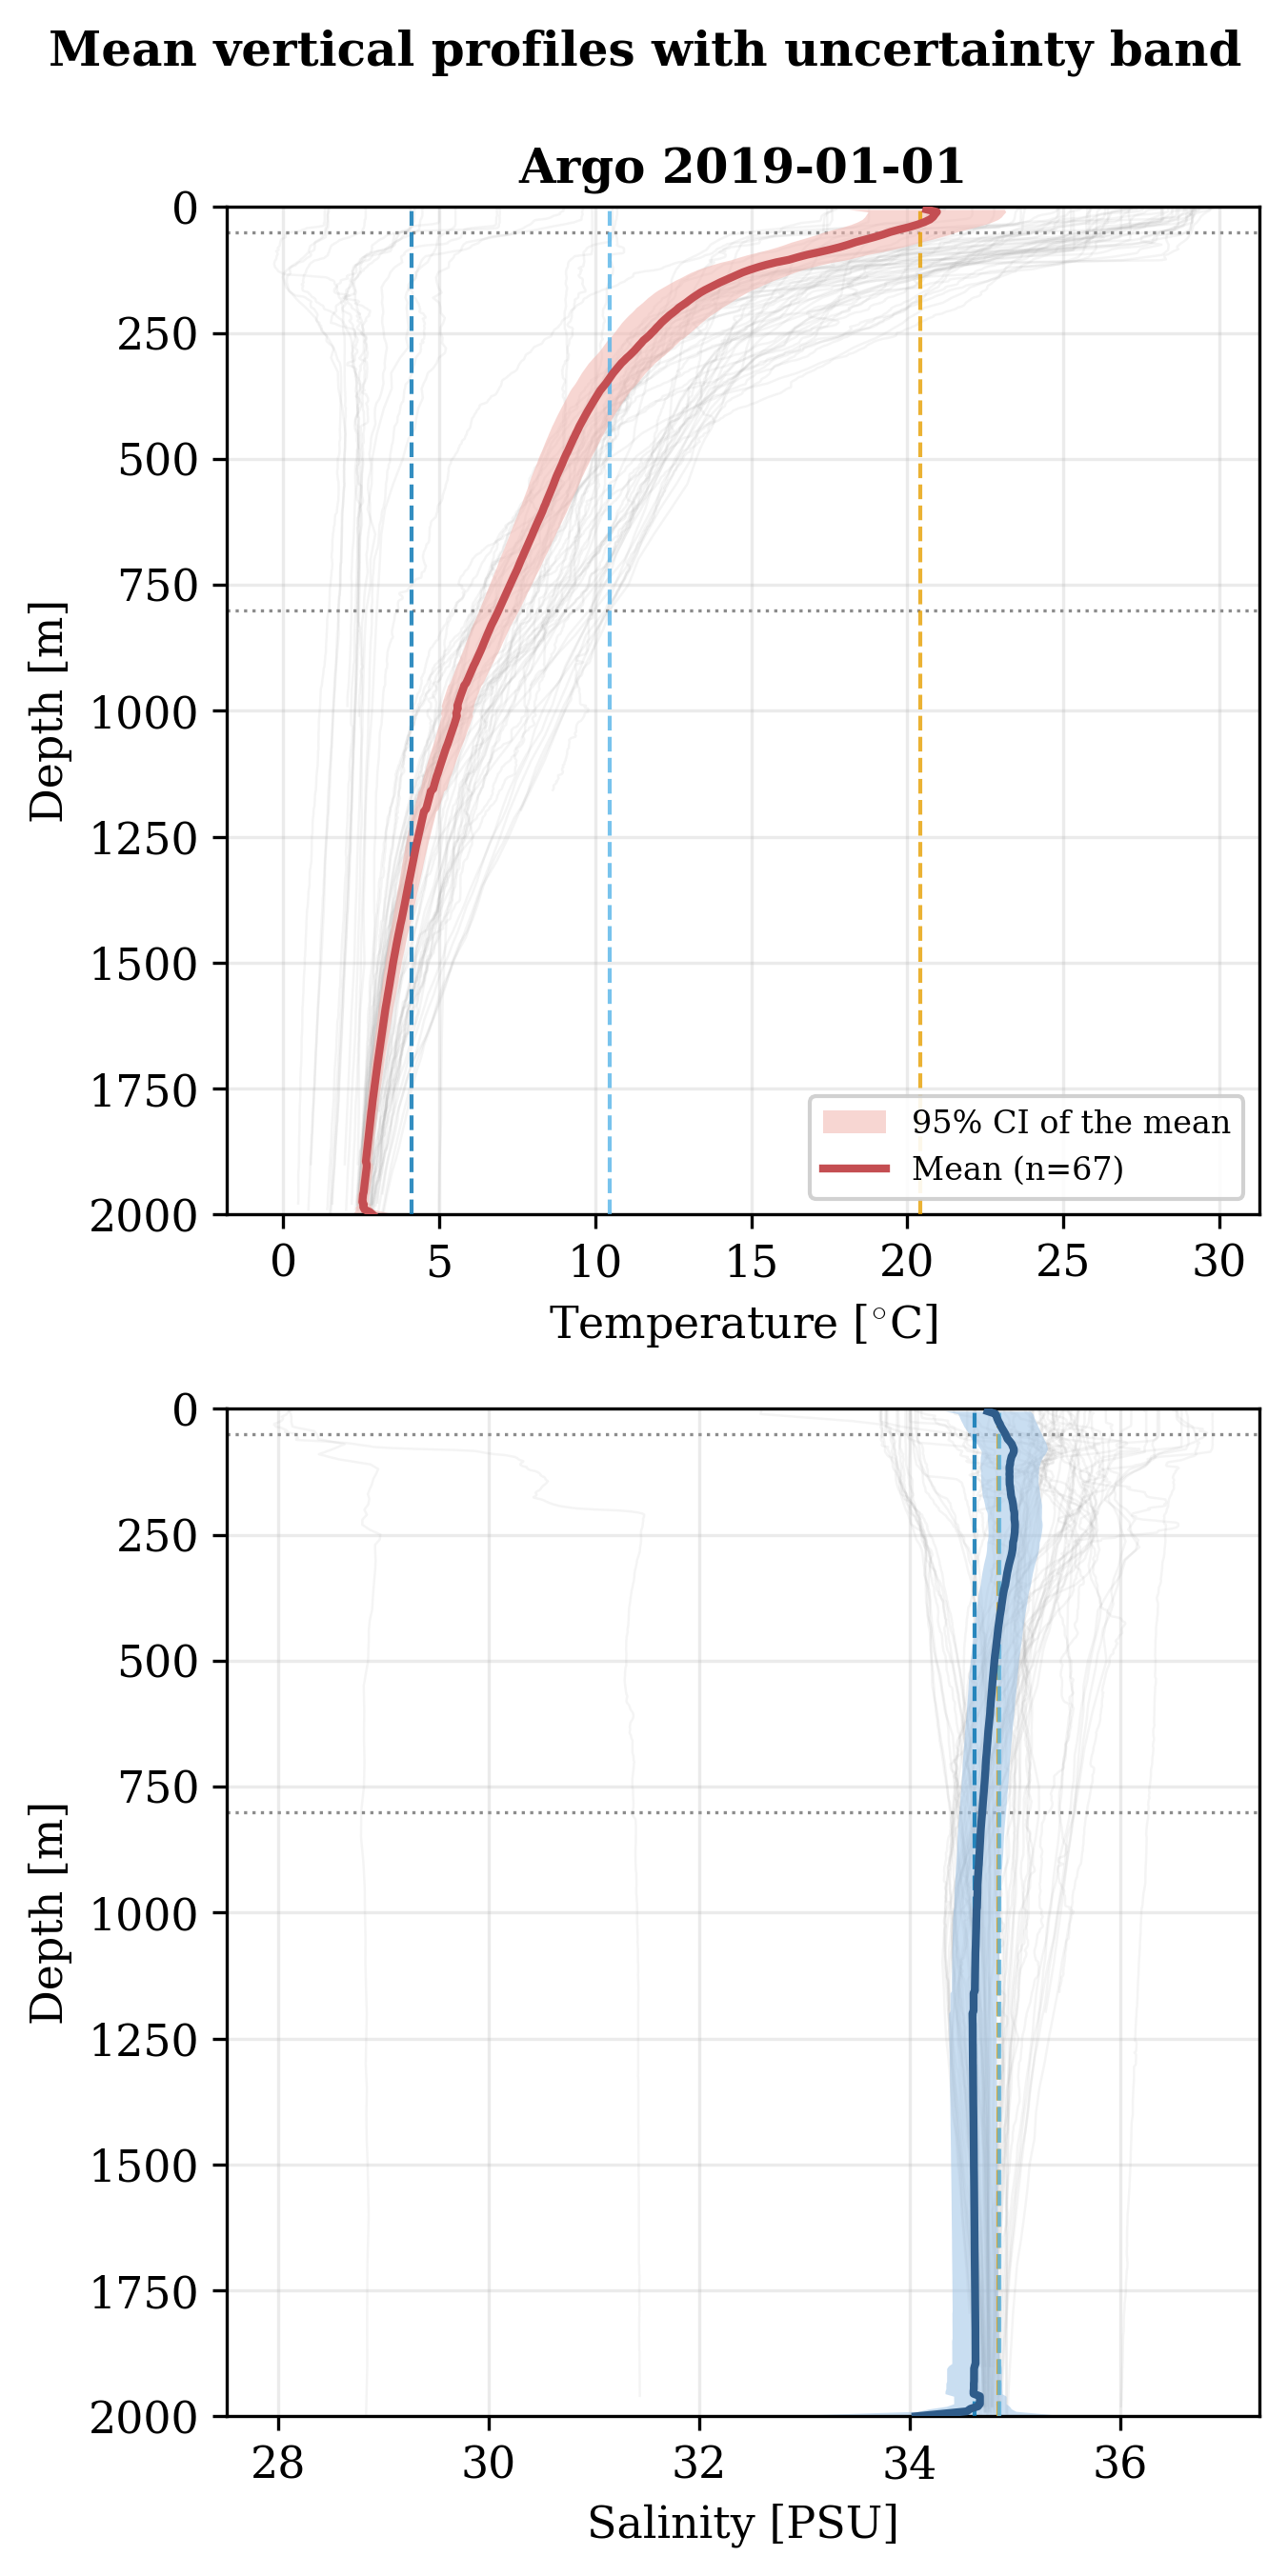

**fig08_mean_profiles_envelope**

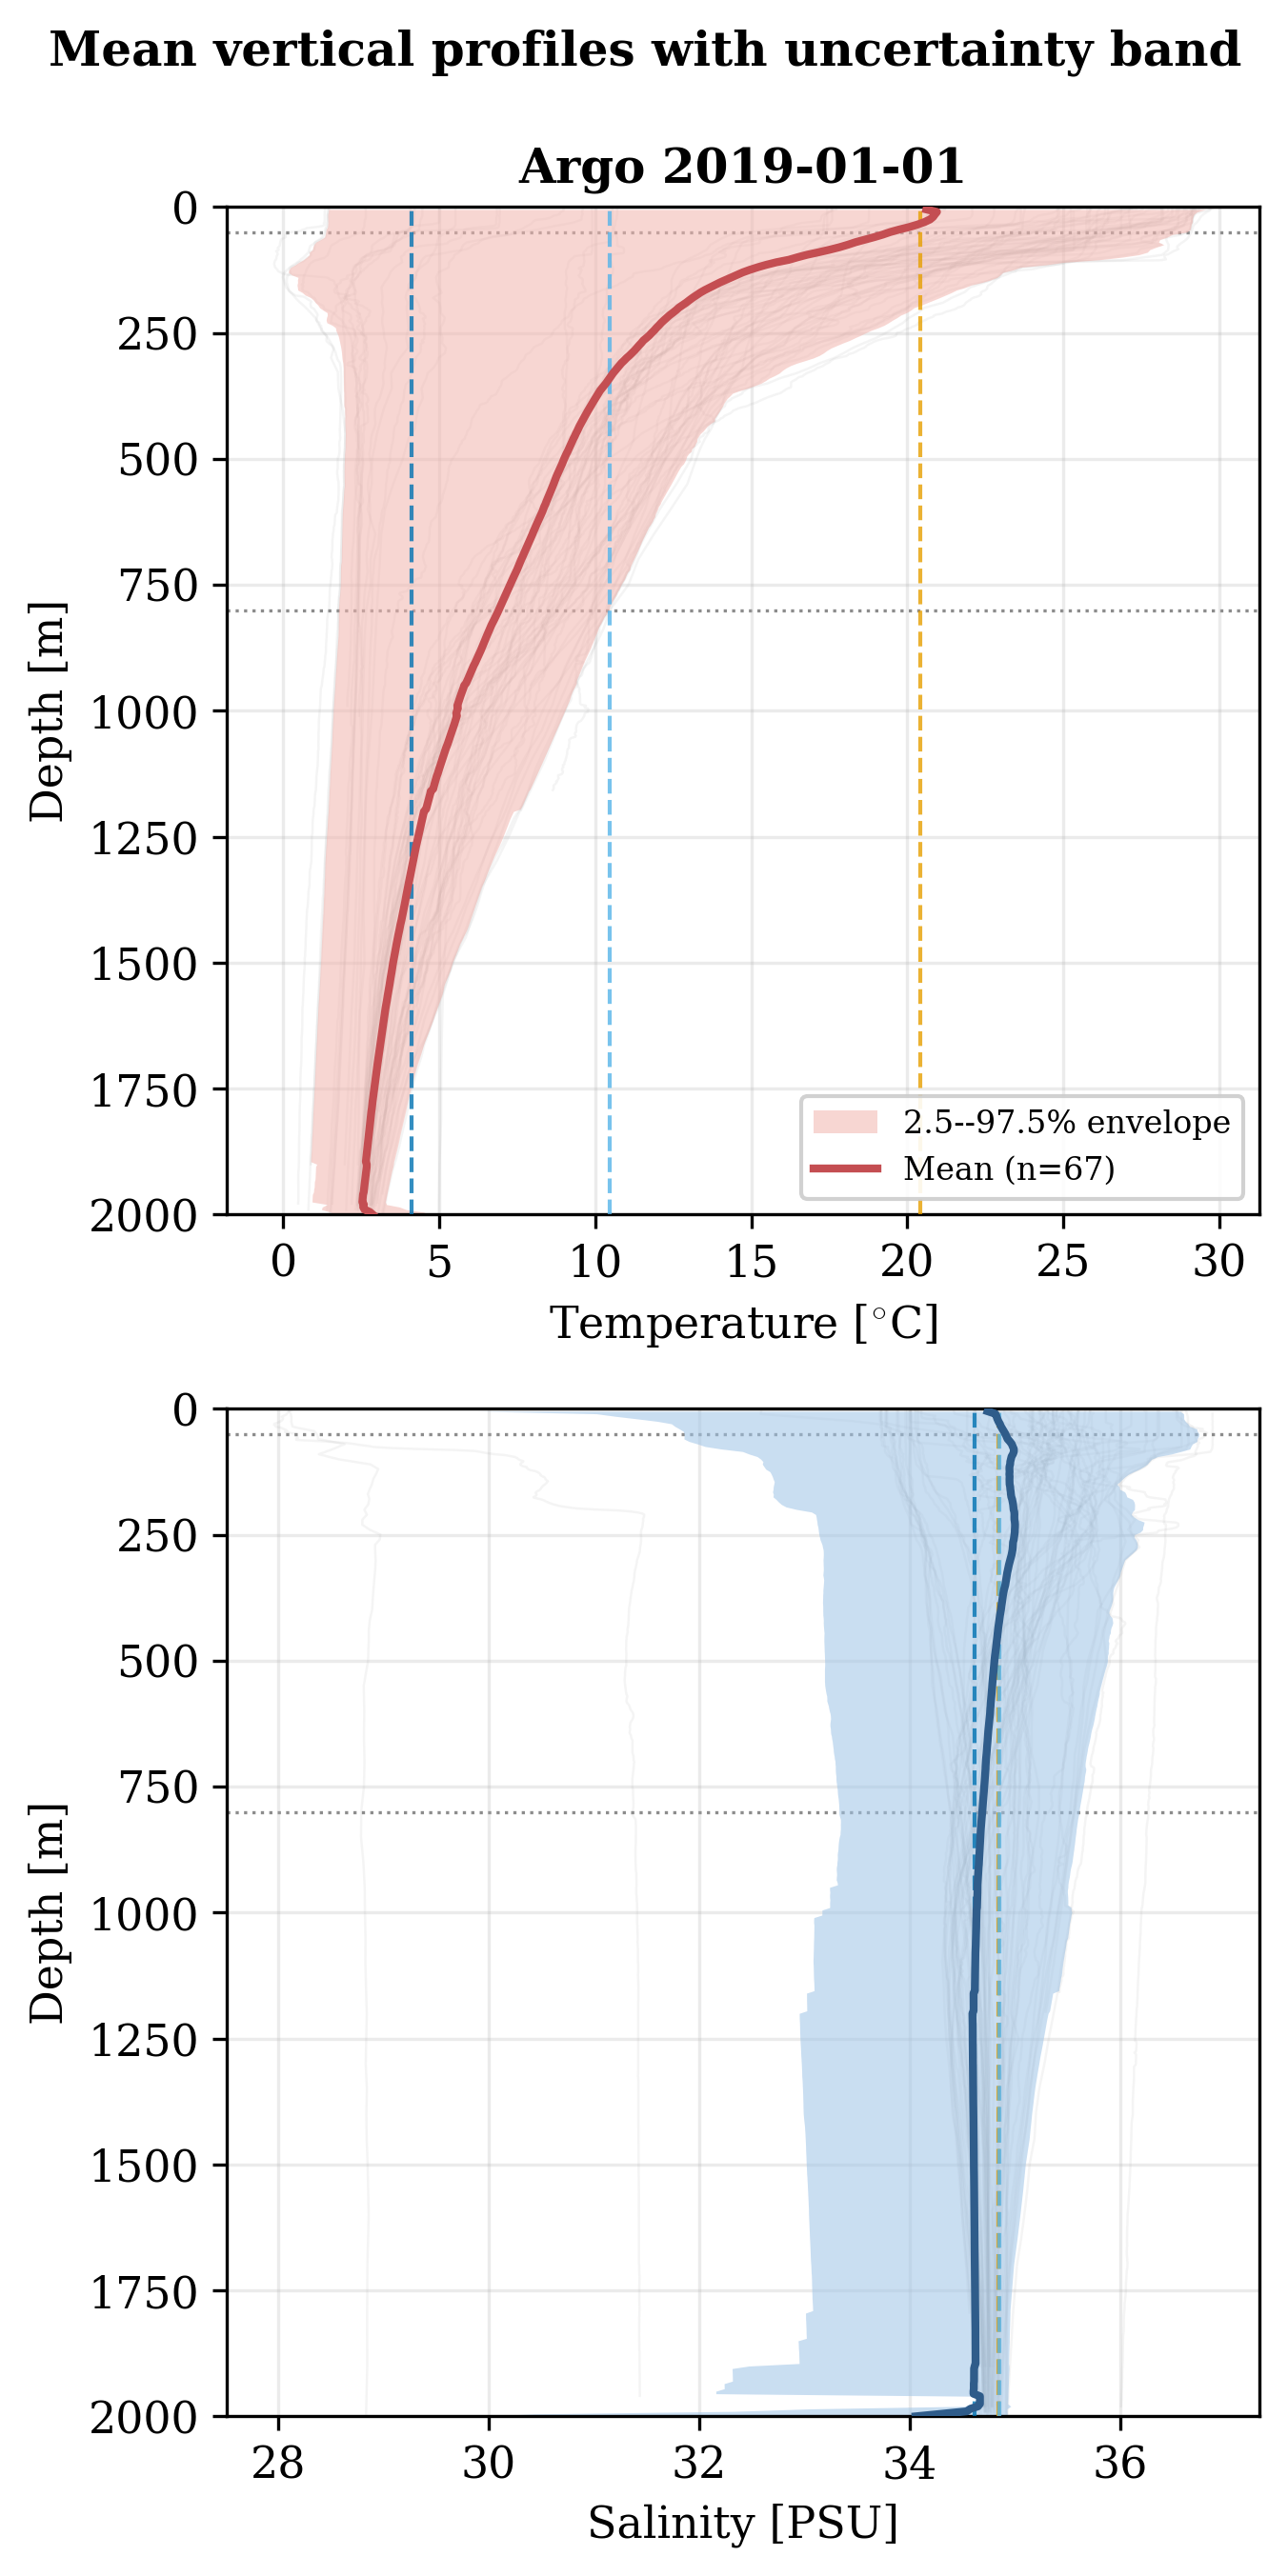


Archive ready: /content/figures_en.zip
(PNG + PDF also stored in Google Drive: /content/drive/MyDrive/Colab Notebooks/Data/SeaData/benchmark_results)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

# ==============================================================================

# PIPELINE INTEGRADO — Modelo Termohalino 3 Capas (GPU/CPU)
# Benchmark de inversión + análisis científico del problema inverso
# ------------------------------------------------------------------------------
# Métodos en el benchmark: DE, Dual Annealing, L-BFGS-B, SLSQP (4, robustos)
# Análisis adicionales:
#     (8)  Sensibilidad de Sobol (índices S1, ST)
#     (9)  Intervalos de confianza bootstrap de parámetros invertidos
#     (10) Validación cruzada leave-one-profile-out (LOPO-CV)
#
# INSTRUCCIONES (Colab):
#   1. Runtime → Change runtime type → GPU (T4)  [opcional, es CPU-bound]
#   2. Ejecutar todo en orden.
# ==============================================================================

# ==============================================================================
# CELDA 0: INSTALACIÓN DE DEPENDENCIAS
# ==============================================================================

!pip install -q SALib netCDF4 statsmodels

# ==============================================================================
# CELDA 1: IMPORTS Y CONFIGURACIÓN
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import (fsolve, differential_evolution, dual_annealing,
                            minimize)
from scipy import stats
from statsmodels.stats.libqsturng import qsturng
import time
import warnings
import os
import json
from collections import defaultdict
from functools import partial

warnings.filterwarnings('ignore')

import scipy
print(f"NumPy: {np.__version__}")
print(f"SciPy: {scipy.__version__}")




# ==============================================================================
# MONTAR GOOGLE DRIVE
# ==============================================================================
from google.colab import drive
drive.mount('/content/drive')

# Ruta al archivo de datos
DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/Data/SeaData/20190101_prof.nc'
OUTPUT_DIR = '/content/drive/MyDrive/Colab Notebooks/Data/SeaData/benchmark_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Datos: {DATA_PATH}")
print(f"Resultados: {OUTPUT_DIR}")



# ------------------------------------------------------------------------------
# ESTILO Y PALETAS (solo 4 métodos)
# ------------------------------------------------------------------------------
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'axes.labelsize': 12, 'axes.titlesize': 13,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'legend.fontsize': 10, 'figure.dpi': 150,
})

CB_COLORS = {'DE': '#0072B2', 'DA': '#D55E00', 'LB': '#009E73', 'SQ': '#CC79A7'}
METHOD_NAMES = {'DE': 'Differential Evolution', 'DA': 'Dual Annealing',
                'LB': 'L-BFGS-B', 'SQ': 'SLSQP'}
MARKERS = {'DE': 'o', 'DA': 's', 'LB': 'D', 'SQ': 'v'}

# ==============================================================================
# CELDA 2: CARGA DE DATOS ARGO (fill values -> NaN, slicing [:995])
# ==============================================================================
from netCDF4 import Dataset

nc = Dataset(DATA_PATH, 'r')
temp_masked = nc.variables['TEMP'][:]
sal_masked = nc.variables['PSAL'][:]
pres_masked = nc.variables['PRES'][:]
nc.close()

temp = np.asarray(temp_masked.filled(np.nan))
sal = np.asarray(sal_masked.filled(np.nan))
pres = np.asarray(pres_masked.filled(np.nan))

MAX_LEVELS = 995
n_profiles_total = temp.shape[0]
print(f"\nPerfiles en archivo: {n_profiles_total}")

argo_profiles = {}
for p in range(n_profiles_total):
    t_prof = temp[p, :MAX_LEVELS]
    s_prof = sal[p, :MAX_LEVELS]
    p_prof = pres[p, :MAX_LEVELS]

    valid = np.isfinite(t_prof) & np.isfinite(s_prof) & np.isfinite(p_prof)
    t_prof, s_prof, p_prof = t_prof[valid], s_prof[valid], p_prof[valid]
    if len(p_prof) < 10:
        continue

    has_surf = np.any(p_prof <= 50)
    has_therm = np.any((p_prof > 50) & (p_prof <= 800))
    has_deep = np.any(p_prof > 800)
    if not (has_surf and has_therm and has_deep):
        continue

    argo_profiles[p] = {'temp': t_prof, 'sal': s_prof, 'pres': p_prof}

valid_profile_ids = sorted(argo_profiles.keys())
n_profiles = len(valid_profile_ids)
print(f"Perfiles válidos: {n_profiles}")

# ==============================================================================
# CELDA 3: EXTRACCIÓN DE TARGETS POR CAPA
# ==============================================================================
def extract_layer_targets(temp, sal, pres):
    sort_idx = np.argsort(pres)
    temp, sal, pres = temp[sort_idx], sal[sort_idx], pres[sort_idx]
    T_target = np.array([
        np.mean(temp[pres <= 50]),
        np.mean(temp[(pres > 50) & (pres <= 800)]),
        np.mean(temp[pres > 800])])
    S_target = np.array([
        np.mean(sal[pres <= 50]),
        np.mean(sal[(pres > 50) & (pres <= 800)]),
        np.mean(sal[pres > 800])])
    return T_target, S_target, pres

profile_targets = {}
for p in valid_profile_ids:
    T_t, S_t, _ = extract_layer_targets(
        argo_profiles[p]['temp'], argo_profiles[p]['sal'], argo_profiles[p]['pres'])
    profile_targets[p] = {'T': T_t, 'S': S_t}
    print(f"Perfil {p}: T={np.round(T_t, 2)}, S={np.round(S_t, 2)}")

# ==============================================================================
# CELDA 4: MODELO FÍSICO
# ==============================================================================
FIXED = {
    'lambda_D': 0.02,
    'gamma1': 0.01, 'omega1': 0.8, 'Teq': 20.0, 'mu0': 2.0,
    'gamma2': 0.01, 'omega2': 0.6,
    'mu1': 0.05, 'a1': 8.0, 'mu2': 0.03, 'a2': 6.0,
    'F_S': 0.5,
}

def stationary_state(k1, k2, k3, T_deep, T_ref, S_deep, S_ref, fixed=None):
    if fixed is None:
        fixed = FIXED

    def temp_equations(vars):
        T1, T2 = vars
        g1, w1, Teq, mu0 = fixed['gamma1'], fixed['omega1'], fixed['Teq'], fixed['mu0']
        g2, w2, lD = fixed['gamma2'], fixed['omega2'], fixed['lambda_D']
        f1 = (-g1*(T1 - Teq)**3 + k1*(T2 - T1) - k3*(T1 - T_ref)
              + mu0 - w1**2*(T1 - Teq))
        f2 = (-g2*(T2 - T_ref)**3 + k1*(T1 - T2)
              - (k2*lD/(k2 + lD))*(T2 - T_deep) - w2**2*(T2 - T_ref))
        return [f1, f2]

    seeds = [[5,5],[10,10],[15,15],[20,20],[25,25],[2,2],[18,8],[8,3],[12,6],
             [1,1],[30,5],[5,15],[15,5],[22,12],[28,8],[35,10],[10,18]]
    best_sol, best_resid = None, 1e12
    for seed in seeds:
        try:
            sol, info, ier, mesg = fsolve(temp_equations, seed, full_output=True)
            if ier == 1:
                T1, T2 = sol
                resid = np.sum(np.array(temp_equations(sol))**2)
                if -10 < T1 < 50 and -10 < T2 < 50 and resid < best_resid:
                    best_resid, best_sol = resid, sol
        except Exception:
            continue

    if best_sol is None or best_resid > 1e-2:
        return None

    T1, T2 = best_sol
    lD = fixed['lambda_D']
    T3 = (k2 * T2 + lD * T_deep) / (k2 + lD)
    if k1 <= 0:
        return None
    denom_s = (k2 * lD / (k2 + lD)) + k3
    if denom_s <= 0:
        return None

    S2 = (fixed['F_S'] + (k2*lD*S_deep)/(k2+lD) + k3*S_ref) / denom_s
    S3 = (k2 * S2 + lD * S_deep) / (k2 + lD)
    S1 = S2 + fixed['F_S'] / k1

    if not all(np.isfinite(v) for v in [T1,T2,T3,S1,S2,S3]):
        return None
    if any(v < 0 for v in [S1,S2,S3]):
        return None
    return np.array([T1, T2, T3, S1, S2, S3])

# ------------------------------------------------------------------------------
# FUNCIÓN DE COSTO — versión ANTERIOR vs versión ACTUAL
# ------------------------------------------------------------------------------
# >>> ANTECEDENTE PARA EL ARTÍCULO (NO BORRAR) <<<
# Objetivo ORIGINAL: peso fijo 20x en salinidad + regularización mínima hacia k=1.
#     cost = RMSE_T + 20*RMSE_S + 1e-4*(log10(k1)^2 + log10(k2)^2 + log10(k3)^2)
# Problema observado (datos Argo reales, n=67 perfiles):
#   - El término 20*RMSE_S domina; el ajuste lleva RMSE_S -> 0 y SACRIFICA la
#     temperatura (RMSE_T ~ 4 °C de mediana).
#   - Sobol: la varianza del costo está casi toda en S_ref (S1~0.78) y k3 (~0.18);
#     k1,k2,T_ref,T_deep son NO identificables (S1~0).
#   - Bootstrap: k1 se pega a la cota superior (5.0), T_deep y S_ref a sus cotas
#     inferiores -> "IC" degenerados, no incertidumbre real.
#   Causa raíz: en el modelo S1 = S2 + F_S/k1 con F_S=0.5 fijo; si el gradiente
#   superficie-termoclina de S es pequeño (~0.1 PSU), el ajuste exacto exige
#   k1 = F_S/(S1-S2) ~ 5 (cota). Documentado como motivación del cambio.
#
# Código original (conservado tal cual para reproducibilidad / comparación):
#
# def cost_combined(params_opt, T_target, S_target, return_state=False, fixed=None):
#     if fixed is None:
#         fixed = FIXED
#     k1, k2, k3, T_deep, T_ref, S_deep, S_ref = params_opt
#     if any(v <= 0 for v in params_opt):
#         return 1e10 if not return_state else None
#     state = stationary_state(k1, k2, k3, T_deep, T_ref, S_deep, S_ref, fixed)
#     if state is None:
#         return 1e10 if not return_state else None
#     T_pred, S_pred = state[0:3], state[3:6]
#     if return_state:
#         return state
#     rmse_T = np.sqrt(np.mean((T_pred - T_target)**2))
#     rmse_S = np.sqrt(np.mean((S_pred - S_target)**2))
#     penalty = 0.0001 * (np.log10(k1)**2 + np.log10(k2)**2 + np.log10(k3)**2)
#     return rmse_T + 20.0 * rmse_S + penalty
#
# ------------------------------------------------------------------------------
# >>> VERSIÓN ACTUAL (la que se usa): costo reescalado + regularización en k <<<
# Mejora respecto al original:
#   cost = w_T*RMSE_T + w_S*RMSE_S + reg_k * Σ_i (log10(k_i / k_nom_i))^2
#   - w_S baja el peso de la salinidad desde 20: "sacrifica un poco S" y saca a
#     k1 de la cota; de paso MEJORA RMSE_T (deja de distorsionar la temperatura).
#   - reg_k > 0: regularización Tikhonov en log que ATRAE k hacia magnitudes
#     físicas plausibles k_nominal (parámetros más adecuados / menos extremos).
#   - NO se normaliza por la dispersión del objetivo: σ_S ~ 0.1 PSU reinflaría la
#     salinidad ~30x y reintroduciría el railing. Por eso se usan pesos directos.
# IMPORTANTE: k_nominal debe reflejar TU expectativa física de (k1,k2,k3).
#             Ajusta w_S y reg_k con la diagnóstico tune_salinity_weight() abajo.
# ------------------------------------------------------------------------------
COST_CFG = {
    'w_T': 1.0,                     # peso temperatura [°C]
    'w_S': 2.0,                     # peso salinidad   [PSU]  (bajado desde 20)
    'reg_k': 0.1,                   # fuerza de regularización sobre log10(k) (0=off)
    'k_nominal': (0.1, 0.1, 1.0),   # magnitudes físicas plausibles de (k1,k2,k3)
}

def cost_combined(params_opt, T_target, S_target, return_state=False, fixed=None):
    if fixed is None:
        fixed = FIXED
    k1, k2, k3, T_deep, T_ref, S_deep, S_ref = params_opt
    if any(v <= 0 for v in params_opt):
        return 1e10 if not return_state else None
    state = stationary_state(k1, k2, k3, T_deep, T_ref, S_deep, S_ref, fixed)
    if state is None:
        return 1e10 if not return_state else None
    T_pred, S_pred = state[0:3], state[3:6]
    if return_state:
        return state

    rmse_T = np.sqrt(np.mean((T_pred - T_target)**2))
    rmse_S = np.sqrt(np.mean((S_pred - S_target)**2))
    misfit = COST_CFG['w_T'] * rmse_T + COST_CFG['w_S'] * rmse_S

    reg = 0.0
    if COST_CFG['reg_k'] > 0:
        kn = COST_CFG['k_nominal']
        reg = COST_CFG['reg_k'] * sum((np.log10(k) - np.log10(knom))**2
                                      for k, knom in zip((k1, k2, k3), kn))
    return misfit + reg

BOUNDS = [
    (0.0001, 5.0),    # k1
    (0.0001, 5.0),    # k2
    (0.001, 100.0),   # k3
    (0.1, 10.0),      # T_deep
    (0.1, 30.0),      # T_ref
    (33.0, 37.0),     # S_deep
    (33.0, 37.0),     # S_ref
]
PARAM_NAMES = ['k1', 'k2', 'k3', 'T_deep', 'T_ref', 'S_deep', 'S_ref']
PARAM_LATEX = [r'$k_1$', r'$k_2$', r'$k_3$', r'$T_{deep}$',
               r'$T_{ref}$', r'$S_{deep}$', r'$S_{ref}$']

# ------------------------------------------------------------------------------
# DIAGNÓSTICO (opcional, recomendado): afinar w_S en TUS datos reales.
# Barre el peso de salinidad para un perfil y muestra cómo cambian k y los RMSE,
# para elegir el compromiso antes de correr el benchmark completo.
# ------------------------------------------------------------------------------
def tune_salinity_weight(p, w_grid=(20, 8, 4, 2, 1, 0.5), reg_k=None,
                         k_nominal=None, seed=1):
    T_t, S_t = profile_targets[p]['T'], profile_targets[p]['S']
    reg_k = COST_CFG['reg_k'] if reg_k is None else reg_k
    k_nominal = COST_CFG['k_nominal'] if k_nominal is None else k_nominal
    saved = dict(COST_CFG)
    print(f"Perfil {p}  |  reg_k={reg_k}  k_nominal={k_nominal}")
    print(f"{'w_S':>6} {'k1':>9} {'k2':>9} {'k3':>9} "
          f"{'RMSE_T':>9} {'RMSE_S':>9} {'k1@cota':>8}")
    print("-" * 64)
    rows = []
    for w_S in w_grid:
        COST_CFG.update(w_T=1.0, w_S=w_S, reg_k=reg_k, k_nominal=k_nominal)
        r = differential_evolution(
            partial(cost_combined, T_target=T_t, S_target=S_t),
            BOUNDS, maxiter=120, seed=seed, popsize=12, tol=1e-7, polish=True)
        st = cost_combined(r.x, T_t, S_t, return_state=True)
        rmseT = np.sqrt(np.mean((st[0:3] - T_t)**2))
        rmseS = np.sqrt(np.mean((st[3:6] - S_t)**2))
        railed = 'sí' if abs(r.x[0] - BOUNDS[0][1]) < 1e-3 else 'no'
        rows.append((w_S, *r.x[:3], rmseT, rmseS, railed))
        print(f"{w_S:>6} {r.x[0]:>9.3f} {r.x[1]:>9.3f} {r.x[2]:>9.3f} "
              f"{rmseT:>9.3f} {rmseS:>9.4f} {railed:>8}")
    COST_CFG.update(saved)   # restaura la configuración
    return rows

# Para afinar antes del benchmark, descomenta:
# tune_salinity_weight(valid_profile_ids[0])
# Luego fija COST_CFG['w_S'] (y reg_k / k_nominal) al valor elegido.

# ==============================================================================
# CELDA 5: MÉTODOS DE OPTIMIZACIÓN (4 robustos)
# ==============================================================================
def optimize_de(T_target, S_target, bounds, seed=42):
    """Differential Evolution."""
    start = time.time()
    result = differential_evolution(
        partial(cost_combined, T_target=T_target, S_target=S_target),
        bounds, maxiter=150, seed=seed, polish=True, workers=1,
        popsize=12, tol=1e-7, strategy='best1bin',
        mutation=(0.5, 1.5), recombination=0.7)
    return {'params': result.x, 'cost': result.fun, 'nfev': result.nfev,
            'time': time.time() - start, 'success': result.success}

def optimize_da(T_target, S_target, bounds, seed=42):
    """Dual Annealing."""
    start = time.time()
    result = dual_annealing(
        partial(cost_combined, T_target=T_target, S_target=S_target),
        bounds, maxiter=200, seed=seed, no_local_search=False,
        initial_temp=5230.0, restart_temp_ratio=2e-5)
    return {'params': result.x, 'cost': result.fun, 'nfev': result.nfev,
            'time': time.time() - start, 'success': True}

def optimize_lbfgsb(T_target, S_target, bounds, seed=42):
    """L-BFGS-B con log-transform."""
    np.random.seed(seed)
    log_bounds = [(np.log(b[0] + 1e-12), np.log(b[1])) for b in bounds]
    def cost_log(z, T_t, S_t):
        return cost_combined(np.exp(z), T_t, S_t)
    z0 = np.array([np.random.uniform(lb, ub) for lb, ub in log_bounds])
    start = time.time()
    result = minimize(cost_log, z0, args=(T_target, S_target),
                      method='L-BFGS-B', bounds=log_bounds,
                      options={'maxiter': 500, 'ftol': 1e-9})
    return {'params': np.exp(result.x), 'cost': result.fun, 'nfev': result.nfev,
            'time': time.time() - start, 'success': result.success}

def optimize_slsqp(T_target, S_target, bounds, seed=42):
    """SLSQP con log-transform."""
    np.random.seed(seed)
    log_bounds = [(np.log(b[0] + 1e-12), np.log(b[1])) for b in bounds]
    def cost_log(z, T_t, S_t):
        return cost_combined(np.exp(z), T_t, S_t)
    z0 = np.array([np.random.uniform(lb, ub) for lb, ub in log_bounds])
    start = time.time()
    result = minimize(cost_log, z0, args=(T_target, S_target),
                      method='SLSQP', bounds=log_bounds,
                      options={'maxiter': 500, 'ftol': 1e-9})
    return {'params': np.exp(result.x), 'cost': result.fun, 'nfev': result.nfev,
            'time': time.time() - start, 'success': result.success}

METHODS = {'DE': optimize_de, 'DA': optimize_da,
           'LB': optimize_lbfgsb, 'SQ': optimize_slsqp}
print("Métodos cargados:", list(METHODS.keys()))

# ==============================================================================
# CELDA 6: EJECUCIÓN DEL BENCHMARK CON CHECKPOINTS
# ==============================================================================
print("\n" + "="*70)
print("EJECUTANDO BENCHMARK")
print("="*70)

results = defaultdict(dict)
checkpoint_file = f'{OUTPUT_DIR}/results_checkpoint_4methods_scaled.json'

if os.path.exists(checkpoint_file):
    with open(checkpoint_file, 'r') as f:
        saved = json.load(f)
    saved = {int(k): v for k, v in saved.items()}
    print(f"Checkpoint cargado: {len(saved)} perfiles previos")
else:
    saved = {}

for idx, p in enumerate(valid_profile_ids):
    T_t, S_t = profile_targets[p]['T'], profile_targets[p]['S']
    print(f"\n[{idx+1}/{n_profiles}] Perfil {p}")

    if p in saved and all(m in saved[p] for m in METHODS.keys()):
        print("  → Cargado desde checkpoint (completo)")
        results[p] = saved[p]
        continue

    if p in saved:
        results[p] = saved[p]
        print(f"  → Parcial, faltan: {[m for m in METHODS if m not in saved[p]]}")
    else:
        results[p] = {}

    for name, func in METHODS.items():
        if name in results[p] and results[p][name].get('success', False):
            continue
        print(f"  {name}...", end=" ", flush=True)
        try:
            res = func(T_t, S_t, BOUNDS, seed=42 + p)
            if 'rmse_T' not in res:
                state = cost_combined(res['params'], T_t, S_t, return_state=True)
                if state is not None:
                    T_p, S_p = state[0:3], state[3:6]
                    res['rmse_T'] = float(np.sqrt(np.mean((T_p - T_t)**2)))
                    res['rmse_S'] = float(np.sqrt(np.mean((S_p - S_t)**2)))
                    res['rmse_total'] = float(res['rmse_T'] + 20 * res['rmse_S'])
                else:
                    res['rmse_T'] = res['rmse_S'] = res['rmse_total'] = float('nan')
            res['params'] = res['params'].tolist() if res['params'] is not None else None
            results[p][name] = res
            print(f"OK cost={res['cost']:.4f} t={res['time']:.2f}s")
        except Exception as e:
            print(f"FAIL: {str(e)[:60]}")
            results[p][name] = {
                'cost': float('nan'), 'time': float('nan'), 'nfev': 0,
                'success': False, 'rmse_T': float('nan'),
                'rmse_S': float('nan'), 'rmse_total': float('nan'), 'params': None}

    saved[p] = results[p]
    with open(checkpoint_file, 'w') as f:
        json.dump({str(k): v for k, v in saved.items()}, f, indent=2)
    print("  → Checkpoint guardado")

print("\nBenchmark completado.")

# ==============================================================================
# CELDA 7: ANÁLISIS ESTADÍSTICO (FRIEDMAN + NEMENYI) + VISUALIZACIONES + TABLA
# ==============================================================================
methods_list = ['DE', 'DA', 'LB', 'SQ']
n_methods = len(methods_list)

def safe_get(result_dict, method, key, default=np.nan):
    if method not in result_dict:
        return default
    return result_dict[method].get(key, default)

def nemenyi_posthoc(data, alpha=0.05):
    data = np.asarray(data)
    n_blocks, n_algos = data.shape
    ranks = np.zeros_like(data, dtype=float)
    for i in range(n_blocks):
        ranks[i, :] = stats.rankdata(data[i, :])
    mean_ranks = np.mean(ranks, axis=0)
    q_alpha = qsturng(1 - alpha, n_algos, np.inf) / np.sqrt(2)
    cd = q_alpha * np.sqrt(n_algos * (n_algos + 1) / (6 * n_blocks))
    p_matrix = np.ones((n_algos, n_algos))
    se = np.sqrt(n_algos * (n_algos + 1) / (6 * n_blocks))
    for i in range(n_algos):
        for j in range(i + 1, n_algos):
            diff = abs(mean_ranks[i] - mean_ranks[j])
            z = diff / se
            p_val = 2 * (1 - stats.norm.cdf(z))
            p_matrix[i, j] = min(p_val * n_algos * (n_algos - 1) / 2, 1.0)
            p_matrix[j, i] = p_matrix[i, j]
    return p_matrix, cd, mean_ranks, ranks

cost_matrix = np.full((n_profiles, n_methods), np.nan)
time_matrix = np.full((n_profiles, n_methods), np.nan)
rmseT_matrix = np.full((n_profiles, n_methods), np.nan)
rmseS_matrix = np.full((n_profiles, n_methods), np.nan)
nfev_matrix = np.full((n_profiles, n_methods), np.nan)

for i, p in enumerate(valid_profile_ids):
    for j, m in enumerate(methods_list):
        cost_val = safe_get(results[p], m, 'cost', np.nan)
        time_val = safe_get(results[p], m, 'time', np.nan)
        rmseT_val = safe_get(results[p], m, 'rmse_T', np.nan)
        rmseS_val = safe_get(results[p], m, 'rmse_S', np.nan)
        nfev_val = safe_get(results[p], m, 'nfev', 0)
        cost_matrix[i, j] = cost_val if np.isfinite(cost_val) else 1e10
        time_matrix[i, j] = time_val if np.isfinite(time_val) else 1e10
        rmseT_matrix[i, j] = rmseT_val if np.isfinite(rmseT_val) else 1e10
        rmseS_matrix[i, j] = rmseS_val if np.isfinite(rmseS_val) else 1e10
        nfev_matrix[i, j] = nfev_val

valid_methods_per_profile = np.sum(cost_matrix < 1e9, axis=1)
print(f"\nPerfiles con todos los métodos: {np.sum(valid_methods_per_profile == n_methods)}")
print(f"Perfiles con datos parciales: {np.sum(valid_methods_per_profile < n_methods)}")

min_methods_required = 3

def run_friedman_nemenyi_robust(matrix, metric_name, methods_list):
    n_profiles, n_methods = matrix.shape
    valid_counts = np.sum(np.isfinite(matrix) & (matrix < 1e9), axis=1)
    valid_rows = valid_counts >= min_methods_required
    if np.sum(valid_rows) < 3:
        return None, f"Solo {np.sum(valid_rows)} perfiles con ≥{min_methods_required} métodos"
    valid_data = matrix[valid_rows].copy()
    max_valid = np.nanmax(np.where(np.isfinite(valid_data) & (valid_data < 1e9),
                                   valid_data, np.nan))
    if not np.isfinite(max_valid):
        max_valid = 1e10
    valid_data_imputed = np.where(np.isfinite(valid_data) & (valid_data < 1e9),
                                  valid_data, max_valid * 2)
    try:
        statistic, pvalue = stats.friedmanchisquare(
            *[valid_data_imputed[:, j] for j in range(n_methods)])
    except ValueError as e:
        return None, f"Error en Friedman: {str(e)}"
    p_matrix, cd, mean_ranks, ranks = nemenyi_posthoc(valid_data_imputed)
    return {'friedman_stat': statistic, 'friedman_p': pvalue, 'nemenyi_cd': cd,
            'mean_ranks': mean_ranks, 'p_matrix': p_matrix, 'ranks': ranks,
            'valid_profiles': valid_data_imputed.shape[0]}, None

metrics = {
    'Costo (ajuste)': cost_matrix,
    'RMSE Temperatura [°C]': rmseT_matrix,
    'RMSE Salinidad [PSU]': rmseS_matrix,
    'Tiempo computacional [s]': time_matrix,
    'Evaluaciones de función': nfev_matrix,
}

print("\n" + "="*70)
print("RESULTADOS ESTADÍSTICOS: FRIEDMAN + NEMENYI")
print("="*70)

statistical_results = {}
for metric_name, data_matrix in metrics.items():
    res, err = run_friedman_nemenyi_robust(data_matrix, metric_name, methods_list)
    statistical_results[metric_name] = res
    print(f"\n--- {metric_name} ---")
    if err:
        print(f"ERROR: {err}")
        continue
    print(f"Perfiles válidos: {res['valid_profiles']}")
    print(f"Friedman χ² = {res['friedman_stat']:.4f}, p-value = {res['friedman_p']:.6f}")
    print("→ DIFERENCIAS SIGNIFICATIVAS (p < 0.05)" if res['friedman_p'] < 0.05
          else "→ No hay diferencias significativas (p ≥ 0.05)")
    print(f"\nDiferencia Crítica (Nemenyi): CD = {res['nemenyi_cd']:.4f}")
    print("Rangos medios (menor = mejor):")
    for j, m in enumerate(methods_list):
        print(f"  {METHOD_NAMES[m]:22s}: {res['mean_ranks'][j]:.3f}")
    print("\nMatriz de p-values Nemenyi:")
    print("      " + "".join([f"{m:>10s}" for m in methods_list]))
    for i, mi in enumerate(methods_list):
        row = f"{mi:>6s}"
        for j, mj in enumerate(methods_list):
            row += f"{'    ---':>10s}" if i == j else f"{res['p_matrix'][i,j]:>10.4f}"
        print(row)
    print("\nPares significativamente diferentes (p < 0.05):")
    sig_pairs = []
    for i in range(n_methods):
        for j in range(i + 1, n_methods):
            if res['p_matrix'][i, j] < 0.05:
                better = i if res['mean_ranks'][i] < res['mean_ranks'][j] else j
                worse = j if better == i else i
                sig_pairs.append((methods_list[better], methods_list[worse],
                                  res['p_matrix'][i, j]))
    if sig_pairs:
        for b, w, pv in sorted(sig_pairs, key=lambda x: x[2]):
            print(f"  {METHOD_NAMES[b]} > {METHOD_NAMES[w]}  (p={pv:.4f})")
    else:
        print("  Ningún par significativo")

# ------------------------------------------------------------------------------
# VISUALIZACIONES
# ------------------------------------------------------------------------------
fig = plt.figure(figsize=(20, 14))
metrics_plot = [
    ('Costo (ajuste)', cost_matrix, 'log'),
    ('RMSE Temperatura [°C]', rmseT_matrix, 'linear'),
    ('RMSE Salinidad [PSU]', rmseS_matrix, 'linear'),
    ('Tiempo computacional [s]', time_matrix, 'log'),
]
for idx, (title, data, scale) in enumerate(metrics_plot):
    ax = plt.subplot(3, 3, idx + 1)
    plot_data = []
    for j in range(n_methods):
        vd = data[:, j]
        vd = vd[np.isfinite(vd) & (vd < 1e9)]
        plot_data.append(vd if len(vd) > 0 else [0])
    bp = ax.boxplot(plot_data,
                    labels=[METHOD_NAMES[m].replace(' ', '\n') for m in methods_list],
                    patch_artist=True)
    for patch, m in zip(bp['boxes'], methods_list):
        patch.set_facecolor(CB_COLORS[m]); patch.set_alpha(0.7)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.tick_params(axis='x', labelsize=8); ax.tick_params(axis='y', labelsize=9)
    if scale == 'log':
        ax.set_yscale('log')
    ax.grid(True, alpha=0.3)

ax_cd = plt.subplot(3, 3, 5)
res_cost = statistical_results.get('Costo (ajuste)')
if res_cost:
    mr, cd = res_cost['mean_ranks'], res_cost['nemenyi_cd']
    order = np.argsort(mr)
    for i, idx in enumerate(order):
        m = methods_list[idx]
        ax_cd.barh(i, mr[idx], color=CB_COLORS[m], alpha=0.8, height=0.6)
        ax_cd.text(mr[idx] + 0.05, i, f'{mr[idx]:.2f}', va='center', fontsize=9)
    for i in range(n_methods):
        for j in range(i + 1, n_methods):
            if abs(mr[order[i]] - mr[order[j]]) < cd:
                y_i, y_j = list(order).index(order[i]), list(order).index(order[j])
                ax_cd.plot([mr[order[j]] - cd/2, mr[order[i]] + cd/2],
                           [y_j, y_i], 'k-', alpha=0.3, linewidth=2)
    ax_cd.set_yticks(range(n_methods))
    ax_cd.set_yticklabels([METHOD_NAMES[methods_list[i]] for i in order], fontsize=9)
    ax_cd.set_xlabel('Rango medio (menor = mejor)', fontsize=10)
    ax_cd.set_title(f'CD = {cd:.3f}', fontweight='bold', fontsize=10)
    ax_cd.invert_yaxis(); ax_cd.grid(True, alpha=0.3, axis='x')

ax_sc = plt.subplot(3, 3, 6)
for j, m in enumerate(methods_list):
    valid = (np.isfinite(cost_matrix[:, j]) & np.isfinite(time_matrix[:, j]) &
             (cost_matrix[:, j] < 1e6) & (time_matrix[:, j] < 1e4))
    if np.any(valid):
        ax_sc.scatter(time_matrix[valid, j], cost_matrix[valid, j],
                      c=CB_COLORS[m], label=METHOD_NAMES[m], marker=MARKERS[m],
                      s=80, alpha=0.7, edgecolors='white', linewidth=0.5)
ax_sc.set_xscale('log'); ax_sc.set_yscale('log')
ax_sc.set_xlabel('Tiempo [s]', fontsize=10); ax_sc.set_ylabel('Costo', fontsize=10)
ax_sc.set_title('Tiempo vs Calidad', fontweight='bold', fontsize=10)
ax_sc.legend(fontsize=7, loc='upper right'); ax_sc.grid(True, alpha=0.3)

ax_heat = plt.subplot(3, 3, 7)
if res_cost:
    im = ax_heat.imshow(res_cost['p_matrix'], cmap='RdYlGn_r', vmin=0, vmax=0.2)
    ax_heat.set_xticks(range(n_methods)); ax_heat.set_yticks(range(n_methods))
    ax_heat.set_xticklabels(methods_list, fontsize=10)
    ax_heat.set_yticklabels(methods_list, fontsize=10)
    ax_heat.set_title('P-values Nemenyi (costo)', fontweight='bold', fontsize=10)
    plt.colorbar(im, ax=ax_heat, shrink=0.8)
    for i in range(n_methods):
        for j in range(n_methods):
            if i != j:
                color = "white" if res_cost['p_matrix'][i,j] < 0.1 else "black"
                ax_heat.text(j, i, f'{res_cost["p_matrix"][i,j]:.3f}',
                             ha="center", va="center", color=color, fontsize=8)

ax_conv = plt.subplot(3, 3, 8)
x_pos = np.arange(n_profiles); width = 0.2
for j, m in enumerate(methods_list):
    vd = np.where((np.isfinite(rmseT_matrix[:, j]) & (rmseT_matrix[:, j] < 1e6)),
                  rmseT_matrix[:, j], np.nan)
    ax_conv.bar(x_pos + j * width, vd, width, label=METHOD_NAMES[m],
                color=CB_COLORS[m], alpha=0.85)
ax_conv.set_xlabel('Perfil', fontsize=10); ax_conv.set_ylabel('RMSE-T [°C]', fontsize=10)
ax_conv.set_title('RMSE-T por perfil', fontweight='bold', fontsize=10)
ax_conv.set_xticks(x_pos + width * 1.5)
ax_conv.set_xticklabels([f'P{p}' for p in valid_profile_ids], fontsize=6, rotation=45)
ax_conv.legend(fontsize=6, loc='upper left', ncol=2); ax_conv.grid(True, alpha=0.3, axis='y')

ax_rob = plt.subplot(3, 3, 9)
success_rates = [sum(1 for p in valid_profile_ids
                     if safe_get(results[p], m, 'success', False)) / n_profiles * 100
                 for m in methods_list]
bars = ax_rob.bar(range(n_methods), success_rates,
                  color=[CB_COLORS[m] for m in methods_list], alpha=0.85,
                  edgecolor='black', linewidth=0.5)
ax_rob.set_xticks(range(n_methods))
ax_rob.set_xticklabels([METHOD_NAMES[m].replace(' ', '\n') for m in methods_list], fontsize=8)
ax_rob.set_ylabel('Éxito [%]', fontsize=10)
ax_rob.set_title('Robustez: convergencia exitosa', fontweight='bold', fontsize=10)
ax_rob.set_ylim(0, 105)
for bar, rate in zip(bars, success_rates):
    ax_rob.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{rate:.0f}%', ha='center', fontsize=9, fontweight='bold')
ax_rob.grid(True, alpha=0.3, axis='y')

if res_cost:
    plt.suptitle(
        f'Benchmark: Modelo Termohalino 3 Capas (4 métodos)\n'
        f'Friedman: χ²={res_cost["friedman_stat"]:.2f}, p={res_cost["friedman_p"]:.4f}, '
        f'n={res_cost["valid_profiles"]} perfiles',
        fontsize=13, fontweight='bold', y=0.995)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/benchmark_optimizacion_completo.png',
            dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------------------
# TABLA RESUMEN
# ------------------------------------------------------------------------------
print("\n" + "="*90)
print("TABLA RESUMEN: ESTADÍSTICAS POR MÉTODO (medianas)")
print("="*90)
print(f"{'Método':<22} {'Costo':>10} {'RMSE_T':>10} {'RMSE_S':>10} "
      f"{'Tiempo[s]':>12} {'Nfev':>10} {'Éxito%':>8}")
print("-"*90)
for m in methods_list:
    costs = [c for c in (safe_get(results[p], m, 'cost', np.nan) for p in valid_profile_ids)
             if np.isfinite(c) and c < 1e6]
    rmses_t = [r for r in (safe_get(results[p], m, 'rmse_T', np.nan) for p in valid_profile_ids)
               if np.isfinite(r)]
    rmses_s = [r for r in (safe_get(results[p], m, 'rmse_S', np.nan) for p in valid_profile_ids)
               if np.isfinite(r)]
    times = [t for t in (safe_get(results[p], m, 'time', np.nan) for p in valid_profile_ids)
             if np.isfinite(t)]
    nfevs = [n for n in (safe_get(results[p], m, 'nfev', 0) for p in valid_profile_ids)
             if np.isfinite(n)]
    successes = sum(1 for p in valid_profile_ids if safe_get(results[p], m, 'success', False))
    print(f"{METHOD_NAMES[m]:<22} "
          f"{np.median(costs) if costs else np.nan:>10.4f} "
          f"{np.median(rmses_t) if rmses_t else np.nan:>10.4f} "
          f"{np.median(rmses_s) if rmses_s else np.nan:>10.4f} "
          f"{np.median(times) if times else np.nan:>12.3f} "
          f"{np.median(nfevs) if nfevs else 0:>10.0f} "
          f"{successes/n_profiles*100:>7.0f}%")

print("""
Métodos incluidos:
  • DE / DA : Metaheurísticas globales (Storn & Price 1997; Xiang et al. 1997)
  • L-BFGS-B / SLSQP : Locales basados en gradiente (Byrd et al. 1995; Kraft 1988)
""")


# ==============================================================================
# CELDA 8: ANÁLISIS DE SENSIBILIDAD DE SOBOL
# ------------------------------------------------------------------------------
# Descompone la varianza del costo en efectos principales (S1) y totales (ST).
# Muestreo global restringido a una caja de ±box_frac alrededor del mejor ajuste
# de cada perfil (donde el modelo casi siempre es válido). Las evaluaciones
# inválidas (1e10) se imputan con el percentil 95 y se reporta su fracción.
# ==============================================================================
from SALib.analyze import sobol as _sobol_analyze
try:
    from SALib.sample import sobol as _sobol_sampler          # SALib >= 1.4.6
    def _saltelli_sample(problem, N): return _sobol_sampler.sample(problem, N)
except Exception:
    from SALib.sample import saltelli as _saltelli            # SALib antiguo
    def _saltelli_sample(problem, N): return _saltelli.sample(problem, N)

SOBOL_N        = 256                      # evals = N*(2D+2)
SOBOL_BOX_FRAC = 0.5
SOBOL_PROFILES = valid_profile_ids[:8]    # subconjunto para acotar tiempo

def _best_fit(p):
    """Mejor (params, cost) entre los métodos exitosos del perfil p."""
    best, bcost = None, np.inf
    for m, rd in results[p].items():
        if isinstance(rd, dict) and rd.get('success') and rd.get('params') is not None:
            c = rd.get('cost', np.inf)
            if np.isfinite(c) and c < bcost:
                bcost, best = c, np.asarray(rd['params'], float)
    return best, bcost

def sobol_for_profile(p, N=SOBOL_N, box_frac=SOBOL_BOX_FRAC):
    x0, _ = _best_fit(p)
    if x0 is None:
        return None
    T_t, S_t = profile_targets[p]['T'], profile_targets[p]['S']
    bounds = []
    for xi, (lo, hi) in zip(x0, BOUNDS):
        blo, bhi = max(lo, xi*(1-box_frac)), min(hi, xi*(1+box_frac))
        if bhi <= blo:
            blo, bhi = lo, hi
        bounds.append([blo, bhi])
    problem = {'num_vars': 7, 'names': PARAM_NAMES, 'bounds': bounds}
    X = _saltelli_sample(problem, N)
    Y = np.array([cost_combined(x, T_t, S_t) for x in X])
    fail = float(np.mean(Y >= 1e9))
    if fail > 0:
        good = Y[Y < 1e9]
        Y = np.where(Y >= 1e9, np.percentile(good, 95) if good.size else 1e3, Y)
    Si = _sobol_analyze.analyze(problem, Y, print_to_console=False)
    return {'S1': Si['S1'], 'ST': Si['ST'], 'S1_conf': Si['S1_conf'],
            'ST_conf': Si['ST_conf'], 'fail_frac': fail, 'n_eval': int(X.shape[0])}

print("\n" + "="*70)
print("ANÁLISIS DE SENSIBILIDAD DE SOBOL")
print("="*70)
sobol_S1, sobol_ST, sobol_meta = [], [], []
t0 = time.time()
for p in SOBOL_PROFILES:
    r = sobol_for_profile(p)
    if r is None:
        print(f"  Perfil {p}: sin mejor ajuste, omitido"); continue
    sobol_S1.append(r['S1']); sobol_ST.append(r['ST']); sobol_meta.append((p, r))
    print(f"  Perfil {p}: {r['n_eval']} evals, fallos={r['fail_frac']:.1%}")

sobol_S1, sobol_ST = np.array(sobol_S1), np.array(sobol_ST)
S1_mean, S1_std = np.nanmean(sobol_S1, 0), np.nanstd(sobol_S1, 0)
ST_mean, ST_std = np.nanmean(sobol_ST, 0), np.nanstd(sobol_ST, 0)
print(f"\nPerfiles analizados: {len(sobol_meta)} | tiempo: {time.time()-t0:.1f}s")
print(f"\n{'Parámetro':<10}{'S1 (±std)':>18}{'ST (±std)':>18}")
print("-"*46)
order = np.argsort(ST_mean)[::-1]
for j in order:
    print(f"{PARAM_NAMES[j]:<10}{S1_mean[j]:>9.3f} ± {S1_std[j]:<5.3f}"
          f"{ST_mean[j]:>9.3f} ± {ST_std[j]:<5.3f}")
print("\nNota: ST ligeramente > 1 = varianza del estimador de Saltelli / "
      "interacciones; reportar con ST_conf o subir SOBOL_N.")

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(7); w = 0.38
ax.bar(x - w/2, S1_mean[order], w, yerr=S1_std[order], capsize=3,
       color='#0072B2', alpha=0.85, label='S1 (efecto principal)')
ax.bar(x + w/2, ST_mean[order], w, yerr=ST_std[order], capsize=3,
       color='#D55E00', alpha=0.85, label='ST (efecto total)')
ax.set_xticks(x); ax.set_xticklabels([PARAM_LATEX[j] for j in order])
ax.set_ylabel('Índice de Sobol'); ax.axhline(0, color='k', lw=0.6)
ax.set_title(f'Sensibilidad de Sobol del costo (media sobre {len(sobol_meta)} perfiles)',
             fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/sobol_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()
with open(f'{OUTPUT_DIR}/sobol_results.json', 'w') as f:
    json.dump({'params': PARAM_NAMES, 'S1_mean': S1_mean.tolist(),
               'S1_std': S1_std.tolist(), 'ST_mean': ST_mean.tolist(),
               'ST_std': ST_std.tolist(), 'profiles': [p for p, _ in sobol_meta]}, f, indent=2)
print(f"Guardado: sobol_sensitivity.png y sobol_results.json")


# ==============================================================================
# CELDA 9: INTERVALOS DE CONFIANZA BOOTSTRAP
# ------------------------------------------------------------------------------
# Remuestrea las observaciones crudas DENTRO de cada capa, recalcula los targets
# y reajusta (L-BFGS-B en log-espacio desde el punto estimado). Propaga la
# incertidumbre observacional hacia los parámetros invertidos. ~1 s/réplica.
# ==============================================================================
N_BOOT        = 300
CI_LEVEL      = 95
BOOT_PROFILES = valid_profile_ids[:3]     # subconjunto (costoso)

def _local_refit(T_t, S_t, x0):
    lb = [(np.log(b[0] + 1e-12), np.log(b[1])) for b in BOUNDS]
    z0 = np.log(np.clip(x0, [b[0] for b in BOUNDS], [b[1] for b in BOUNDS]))
    r = minimize(lambda z: cost_combined(np.exp(z), T_t, S_t), z0,
                 method='L-BFGS-B', bounds=lb, options={'maxiter': 300, 'ftol': 1e-9})
    return np.exp(r.x), r.fun

def bootstrap_ci(p, n_boot=N_BOOT, ci=CI_LEVEL, seed=0):
    x0, _ = _best_fit(p)
    if x0 is None:
        return None, None
    pr, te, sa = (argo_profiles[p]['pres'], argo_profiles[p]['temp'], argo_profiles[p]['sal'])
    layers = [np.where(pr <= 50)[0], np.where((pr > 50) & (pr <= 800))[0],
              np.where(pr > 800)[0]]
    rng = np.random.default_rng(seed + p)
    boot = np.full((n_boot, 7), np.nan)
    for b in range(n_boot):
        T_t, S_t = np.empty(3), np.empty(3)
        for L, ix in enumerate(layers):
            rs = rng.choice(ix, size=len(ix), replace=True)
            T_t[L], S_t[L] = te[rs].mean(), sa[rs].mean()
        xb, fb = _local_refit(T_t, S_t, x0)
        if np.isfinite(fb) and fb < 1e6:
            boot[b] = xb
    lo, hi = (100-ci)/2, 100-(100-ci)/2
    out = {}
    for j, name in enumerate(PARAM_NAMES):
        col = boot[:, j][np.isfinite(boot[:, j])]
        if col.size:
            out[name] = dict(point=float(x0[j]), mean=float(col.mean()),
                             std=float(col.std()), lo=float(np.percentile(col, lo)),
                             hi=float(np.percentile(col, hi)), n=int(col.size))
    return out, boot

print("\n" + "="*70)
print(f"INTERVALOS DE CONFIANZA BOOTSTRAP ({CI_LEVEL}%, B={N_BOOT})")
print("="*70)
boot_results = {}
t0 = time.time()
for p in BOOT_PROFILES:
    ci_p, _ = bootstrap_ci(p)
    if ci_p is None:
        continue
    boot_results[p] = ci_p
    print(f"\nPerfil {p}:")
    for name in PARAM_NAMES:
        c = ci_p[name]
        print(f"  {name:<8} = {c['point']:9.4f}  IC{CI_LEVEL}% = "
              f"[{c['lo']:9.4f}, {c['hi']:9.4f}]  (σ={c['std']:.4f})")
print(f"\nTiempo total: {time.time()-t0:.1f}s")

k_idx = [0, 1, 2]
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, j in zip(axes, k_idx):
    ps = list(boot_results.keys())
    pts = [boot_results[p][PARAM_NAMES[j]]['point'] for p in ps]
    los = [boot_results[p][PARAM_NAMES[j]]['lo'] for p in ps]
    his = [boot_results[p][PARAM_NAMES[j]]['hi'] for p in ps]
    yerr = np.abs(np.vstack([np.array(pts) - los, np.array(his) - pts]))
    ax.errorbar(range(len(ps)), pts, yerr=yerr, fmt='o', capsize=4,
                color='#009E73', ecolor='#333', markersize=7)
    ax.set_xticks(range(len(ps))); ax.set_xticklabels([f'P{p}' for p in ps])
    ax.set_title(PARAM_LATEX[j], fontweight='bold')
    ax.set_xlabel('Perfil'); ax.grid(True, alpha=0.3, axis='y')
axes[0].set_ylabel(f'Estimación ± IC{CI_LEVEL}%')
fig.suptitle('Bootstrap: coeficientes de mezcla invertidos con incertidumbre',
             fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/bootstrap_ci.png', dpi=300, bbox_inches='tight')
plt.show()
with open(f'{OUTPUT_DIR}/bootstrap_ci.json', 'w') as f:
    json.dump({str(p): v for p, v in boot_results.items()}, f, indent=2)
print(f"Guardado: bootstrap_ci.png y bootstrap_ci.json")


# ==============================================================================
# CELDA 10: VALIDACIÓN CRUZADA LEAVE-ONE-PROFILE-OUT (LOPO-CV)
# ------------------------------------------------------------------------------
# k1,k2,k3 = COMPARTIDOS (constantes regionales); T_deep,T_ref,S_deep,S_ref =
# locales por perfil. Para cada perfil de prueba se fija k = mediana de los k de
# entrenamiento, se reajustan solo los 4 locales y se compara con el ajuste
# libre. Una brecha pequeña ⇒ coeficientes transferibles; grande ⇒ sobreajuste.
# ==============================================================================
LOPO_METHOD = 'DE'
SHARED, LOCAL = [0, 1, 2], [3, 4, 5, 6]

def _fit_local_only(T_t, S_t, k_fixed, seed=1):
    lb = [BOUNDS[i] for i in LOCAL]
    def c4(v):
        full = np.empty(7); full[SHARED] = k_fixed; full[LOCAL] = v
        return cost_combined(full, T_t, S_t)
    r = differential_evolution(c4, lb, maxiter=60, seed=seed, popsize=10,
                               tol=1e-7, polish=True)
    full = np.empty(7); full[SHARED] = k_fixed; full[LOCAL] = r.x
    return full, r.fun

def _rmse(params, T_t, S_t):
    st = cost_combined(params, T_t, S_t, return_state=True)
    if st is None:
        return np.nan, np.nan
    return (float(np.sqrt(np.mean((st[0:3] - T_t)**2))),
            float(np.sqrt(np.mean((st[3:6] - S_t)**2))))

print("\n" + "="*70)
print(f"VALIDACIÓN CRUZADA LEAVE-ONE-PROFILE-OUT (k compartidos, método={LOPO_METHOD})")
print("="*70)
K, ids_ok = [], []
for p in valid_profile_ids:
    rd = results[p].get(LOPO_METHOD, {})
    pars = rd.get('params') if isinstance(rd, dict) else None
    if pars is None:
        pars, _ = _best_fit(p)
    if pars is not None:
        K.append(np.asarray(pars, float)[SHARED]); ids_ok.append(p)
K = np.array(K)

lopo_rows = []
t0 = time.time()
for i, p in enumerate(ids_ok):
    train = np.delete(K, i, axis=0)
    k_fixed = np.median(train, axis=0)
    T_t, S_t = profile_targets[p]['T'], profile_targets[p]['S']
    full_cv, cost_cv = _fit_local_only(T_t, S_t, k_fixed)
    rmseT_cv, rmseS_cv = _rmse(full_cv, T_t, S_t)
    pars_free, _ = _best_fit(p)
    if pars_free is None:
        rmseT_free, rmseS_free = np.nan, np.nan
    else:
        rmseT_free, rmseS_free = _rmse(pars_free, T_t, S_t)
    lopo_rows.append(dict(profile=p, k_fixed=k_fixed.tolist(),
                          rmseT_cv=rmseT_cv, rmseS_cv=rmseS_cv,
                          rmseT_free=rmseT_free, rmseS_free=rmseS_free))
    print(f"  P{p:<4} k_fix={np.round(k_fixed,3)}  "
          f"RMSE_T: cv={rmseT_cv:.3f} libre={rmseT_free:.3f}  "
          f"RMSE_S: cv={rmseS_cv:.3f} libre={rmseS_free:.3f}")

mT_cv = np.nanmedian([r['rmseT_cv'] for r in lopo_rows])
mT_fr = np.nanmedian([r['rmseT_free'] for r in lopo_rows])
mS_cv = np.nanmedian([r['rmseS_cv'] for r in lopo_rows])
mS_fr = np.nanmedian([r['rmseS_free'] for r in lopo_rows])
print(f"\nMediana RMSE_T:  libre={mT_fr:.3f}  cv={mT_cv:.3f}  gap={mT_cv-mT_fr:+.3f} °C")
print(f"Mediana RMSE_S:  libre={mS_fr:.3f}  cv={mS_cv:.3f}  gap={mS_cv-mS_fr:+.3f} PSU")
print(f"Tiempo: {time.time()-t0:.1f}s")
print("\nInterpretación: brecha pequeña ⇒ k1,k2,k3 transferibles (constantes "
      "regionales);\nbrecha grande ⇒ sobreajuste por perfil, k no debe verse como "
      "constante única.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ps = [r['profile'] for r in lopo_rows]
x = np.arange(len(ps)); w = 0.38
for ax, key, title, unit in [(axes[0], 'rmseT', 'Temperatura', '°C'),
                             (axes[1], 'rmseS', 'Salinidad', 'PSU')]:
    free = [r[f'{key}_free'] for r in lopo_rows]
    cv = [r[f'{key}_cv'] for r in lopo_rows]
    ax.bar(x - w/2, free, w, color='#0072B2', alpha=0.85, label='Ajuste libre')
    ax.bar(x + w/2, cv, w, color='#E69F00', alpha=0.85, label='LOPO-CV')
    ax.set_xticks(x); ax.set_xticklabels([f'P{p}' for p in ps], rotation=45, fontsize=7)
    ax.set_ylabel(f'RMSE [{unit}]'); ax.set_title(title, fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3, axis='y')
fig.suptitle('Generalización de los coeficientes de mezcla (LOPO-CV)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/lopo_cv.png', dpi=300, bbox_inches='tight')
plt.show()
with open(f'{OUTPUT_DIR}/lopo_cv.json', 'w') as f:
    json.dump(lopo_rows, f, indent=2)
print(f"Guardado: lopo_cv.png y lopo_cv.json")

print(f"\nTodos los resultados en: {OUTPUT_DIR}")

# ==============================================================================
# CELDA 11: PERFILES VERTICALES MEDIOS CON BANDA DE CONFIANZA
# ------------------------------------------------------------------------------
# Promedio entre perfiles de T y S vs profundidad, con banda de incertidumbre,
# sobre los perfiles individuales. Cada perfil se interpola a una rejilla común
# (sin extrapolar) y luego se promedia punto a punto.
#   band_type='ci95' -> IC 95% del PROMEDIO (mean ± 1.96·SE), estrecho.
#   band_type='sd'   -> mean ± 1 SD.
#   band_type='pct'  -> envolvente 2.5–97.5% (ancha; muestra dispersión).
# ==============================================================================
DEPTH_GRID = np.arange(0.0, 2001.0, 5.0)
LAYER_BNDS = (50.0, 800.0)
MIN_PROF   = 3

def _interp_to_grid(profiles, ids, var, grid):
    M = np.full((len(ids), grid.size), np.nan)
    for i, p in enumerate(ids):
        pr = np.asarray(profiles[p]['pres'], float)
        v  = np.asarray(profiles[p][var], float)
        order = np.argsort(pr)
        pr_u, idx = np.unique(pr[order], return_index=True)
        if pr_u.size < 2:
            continue
        M[i] = np.interp(grid, pr_u, v[order][idx], left=np.nan, right=np.nan)
    return M

def _mean_band(M, band_type='ci95', min_n=MIN_PROF):
    n = np.sum(np.isfinite(M), axis=0)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        mean = np.nanmean(M, axis=0)
        sd   = np.nanstd(M, axis=0, ddof=1)
        with np.errstate(invalid='ignore', divide='ignore'):
            se = sd / np.sqrt(n)
        if band_type == 'ci95':
            lo, hi = mean - 1.96 * se, mean + 1.96 * se
        elif band_type == 'sd':
            lo, hi = mean - sd, mean + sd
        elif band_type == 'pct':
            lo = np.nanpercentile(M, 2.5, axis=0)
            hi = np.nanpercentile(M, 97.5, axis=0)
        else:
            raise ValueError("band_type must be 'ci95', 'sd' or 'pct'")
    valid = n >= min_n
    for a in (mean, lo, hi):
        a[~valid] = np.nan
    return mean, lo, hi, n

def _layer_means(mean, grid, bnds=LAYER_BNDS):
    s, t = bnds
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        return [np.nanmean(mean[grid <= s]),
                np.nanmean(mean[(grid > s) & (grid <= t)]),
                np.nanmean(mean[grid > t])]

_BAND_LABEL = {'ci95': '95% CI of the mean', 'sd': r'Mean $\pm$ 1 SD',
               'pct': '2.5--97.5% envelope'}
_LAYER_C = ('#E69F00', '#56B4E9', '#0072B2')

def plot_profile_envelopes(datasets, grid=DEPTH_GRID, band_type='ci95',
                           show_individual=True, show_layer_means=True,
                           depth_max=2000.0, save_path=None):
    """datasets: dict {column_label: profiles_dict}; one column per dataset."""
    variables = [('temp', r'Temperature [$^{\circ}$C]', '#C44E52', '#F2B5AE'),
                 ('sal',  'Salinity [PSU]',             '#2F5C8A', '#9EC3E6')]
    cols = list(datasets.keys())
    fig, axes = plt.subplots(2, len(cols), figsize=(4.6 * len(cols), 9),
                             sharey=True, squeeze=False)
    for r, (var, xlabel, line_c, band_c) in enumerate(variables):
        for c, label in enumerate(cols):
            ax = axes[r, c]; profiles = datasets[label]; ids = sorted(profiles.keys())
            if show_individual:
                for p in ids:
                    ax.plot(profiles[p][var], profiles[p]['pres'],
                            color='0.6', alpha=0.10, lw=0.6, zorder=1)
            M = _interp_to_grid(profiles, ids, var, grid)
            mean, lo, hi, n = _mean_band(M, band_type)
            ax.fill_betweenx(grid, lo, hi, color=band_c, alpha=0.55, lw=0,
                             zorder=2, label=_BAND_LABEL[band_type])
            ax.plot(mean, grid, color=line_c, lw=2.0, zorder=4,
                    label=f'Mean (n={int(np.nanmax(n))})')
            for b in LAYER_BNDS:
                ax.axhline(b, color='k', ls=':', lw=0.8, alpha=0.45, zorder=0)
            if show_layer_means:
                for val, lc in zip(_layer_means(mean, grid), _LAYER_C):
                    if np.isfinite(val):
                        ax.axvline(val, color=lc, ls='--', lw=1.0, alpha=0.8, zorder=3)
            ax.set_xlabel(xlabel)
            if r == 0: ax.set_title(label, fontweight='bold')
            if c == 0: ax.set_ylabel('Depth [m]')
            ax.grid(True, alpha=0.25)
            if r == 0 and c == 0:
                ax.legend(loc='lower right', fontsize=8, framealpha=0.9)
    axes[0, 0].set_ylim(depth_max, 0.0)
    fig.suptitle('Mean vertical profiles with uncertainty band',
                 fontweight='bold', y=0.995)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    return fig

# IC 95% del promedio:
plot_profile_envelopes({'Argo 2019-01-01': argo_profiles}, band_type='ci95',
                       save_path=f'{OUTPUT_DIR}/mean_profiles_ci.png')
# Envolvente 2.5–97.5% (estilo de la figura de referencia):
plot_profile_envelopes({'Argo 2019-01-01': argo_profiles}, band_type='pct',
                       save_path=f'{OUTPUT_DIR}/mean_profiles_envelope.png')
# Layout multi-columna por nivel de ruido (descomentar y pasar un dict por nivel):
# plot_profile_envelopes({r'$\sigma_{base}=0.00$': prof_s00,
#                         r'$\sigma_{base}=0.02$': prof_s02,
#                         r'$\sigma_{base}=0.05$': prof_s05},
#                        band_type='pct',
#                        save_path=f'{OUTPUT_DIR}/mean_profiles_by_noise.png')

print(f"\nPipeline completo. Resultados en: {OUTPUT_DIR}")










# ==============================================================================
# CELL 12: PUBLICATION FIGURES (ENGLISH) — REGENERATE, DISPLAY, EXPORT
# ------------------------------------------------------------------------------
# Run AFTER the full pipeline (it reuses the objects already in memory:
# cost_matrix, rmseT_matrix, ..., statistical_results, results, sobol arrays,
# boot_results, lopo_rows, argo_profiles, plot_profile_envelopes).
# It does NOT re-run the benchmark.
#
#   1. Rebuilds every figure with academic-English labels.
#   2. Saves each as PNG (300 dpi) AND PDF (vector) to Google Drive (OUTPUT_DIR)
#      and to a local folder.
#   3. Displays the figures one by one.
#   4. Zips them and downloads the archive to your computer.
# ==============================================================================
import os, shutil
import numpy as np
import matplotlib.pyplot as plt

# Academic style (kept local to this cell; harmless if already set upstream)
plt.rcParams.update({'font.family': 'serif', 'mathtext.fontset': 'cm',
                     'axes.titlesize': 12, 'axes.labelsize': 11,
                     'savefig.dpi': 300})

FIG_DIR = '/content/figures_en'                  # local folder (for download)
os.makedirs(FIG_DIR, exist_ok=True)

# Optional environment helpers (graceful outside Colab) -----------------------
try:
    from google.colab import files as _colab_files
    _IN_COLAB = True
except Exception:
    _IN_COLAB = False
try:
    from IPython.display import display, Image as _IPyImage, Markdown
    _HAS_IPY = True
except Exception:
    _HAS_IPY = False

figure_files = []

def _export(fig, name):
    """Save fig as PNG + PDF to Drive and the local folder; return local PNG."""
    local_png = os.path.join(FIG_DIR, name + '.png')
    for d in (OUTPUT_DIR, FIG_DIR):
        fig.savefig(os.path.join(d, name + '.png'), dpi=300, bbox_inches='tight')
        fig.savefig(os.path.join(d, name + '.pdf'), bbox_inches='tight')
    plt.close(fig)
    return local_png

def _try(builder, name):
    """Build, export and register a figure, skipping gracefully on failure."""
    try:
        fig = builder()
        if fig is None:
            print(f"  [skip] {name}: required data not available")
            return
        figure_files.append(_export(fig, name))
        print(f"  [ok]   {name}")
    except NameError as e:
        print(f"  [skip] {name}: {e}")
    except Exception as e:
        print(f"  [skip] {name}: {type(e).__name__}: {e}")

# ------------------------------------------------------------------------------
# FIGURE BUILDERS (academic English)
# ------------------------------------------------------------------------------
def _fig_boxplots():
    specs = [('Objective (fit)', cost_matrix, 'log'),
             (r'Temperature RMSE [$^{\circ}$C]', rmseT_matrix, 'linear'),
             ('Salinity RMSE [PSU]', rmseS_matrix, 'linear'),
             ('Computational time [s]', time_matrix, 'log')]
    fig, axes = plt.subplots(2, 2, figsize=(11, 9))
    for ax, (title, data, scale) in zip(axes.ravel(), specs):
        pdata = []
        for j in range(n_methods):
            vd = data[:, j]; vd = vd[np.isfinite(vd) & (vd < 1e9)]
            pdata.append(vd if len(vd) else [0])
        bp = ax.boxplot(pdata, patch_artist=True)
        ax.set_xticks(range(1, n_methods + 1))
        ax.set_xticklabels([METHOD_NAMES[m].replace(' ', '\n') for m in methods_list],
                           fontsize=8)
        for patch, m in zip(bp['boxes'], methods_list):
            patch.set_facecolor(CB_COLORS[m]); patch.set_alpha(0.7)
        ax.set_title(title, fontweight='bold')
        if scale == 'log':
            ax.set_yscale('log')
        ax.grid(True, alpha=0.3)
    fig.suptitle('Distribution of performance metrics across profiles',
                 fontweight='bold')
    fig.tight_layout()
    return fig

def _fig_critical_difference():
    res = statistical_results.get('Costo (ajuste)')   # objective metric key
    if not res:
        return None
    mr, cd = res['mean_ranks'], res['nemenyi_cd']
    order = np.argsort(mr)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for i, idx in enumerate(order):
        m = methods_list[idx]
        ax.barh(i, mr[idx], color=CB_COLORS[m], alpha=0.85, height=0.6)
        ax.text(mr[idx] + 0.03, i, f'{mr[idx]:.2f}', va='center', fontsize=9)
    for i in range(n_methods):
        for j in range(i + 1, n_methods):
            if abs(mr[order[i]] - mr[order[j]]) < cd:
                ax.plot([mr[order[j]] - cd / 2, mr[order[i]] + cd / 2],
                        [j, i], 'k-', alpha=0.3, lw=2)
    ax.set_yticks(range(n_methods))
    ax.set_yticklabels([METHOD_NAMES[methods_list[i]] for i in order])
    ax.set_xlabel('Mean rank (lower = better)')
    ax.set_title(f'Critical-difference ranking of the objective (CD = {cd:.3f})',
                 fontweight='bold')
    ax.invert_yaxis(); ax.grid(True, alpha=0.3, axis='x')
    fig.tight_layout()
    return fig

def _fig_success_rate():
    rates = [sum(1 for p in valid_profile_ids
                 if safe_get(results[p], m, 'success', False)) / n_profiles * 100
             for m in methods_list]
    fig, ax = plt.subplots(figsize=(7, 4.5))
    bars = ax.bar(range(n_methods), rates,
                  color=[CB_COLORS[m] for m in methods_list], alpha=0.85,
                  edgecolor='black', lw=0.5)
    ax.set_xticks(range(n_methods))
    ax.set_xticklabels([METHOD_NAMES[m].replace(' ', '\n') for m in methods_list],
                       fontsize=9)
    ax.set_ylabel('Success [%]'); ax.set_ylim(0, 105)
    ax.set_title('Robustness: successful convergence', fontweight='bold')
    for b, r in zip(bars, rates):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 1, f'{r:.0f}%',
                ha='center', fontweight='bold', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    fig.tight_layout()
    return fig

def _fig_sobol():
    order = np.argsort(ST_mean)[::-1]
    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(7); w = 0.38
    ax.bar(x - w / 2, S1_mean[order], w, yerr=S1_std[order], capsize=3,
           color='#0072B2', alpha=0.85, label=r'$S_1$ (first-order)')
    ax.bar(x + w / 2, ST_mean[order], w, yerr=ST_std[order], capsize=3,
           color='#D55E00', alpha=0.85, label=r'$S_T$ (total-order)')
    ax.set_xticks(x); ax.set_xticklabels([PARAM_LATEX[j] for j in order])
    ax.set_ylabel('Sobol index'); ax.axhline(0, color='k', lw=0.6)
    ax.set_title(f'Sobol sensitivity of the objective '
                 f'(mean over {len(sobol_meta)} profiles)', fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3, axis='y')
    fig.tight_layout()
    return fig

def _fig_bootstrap():
    ps = list(boot_results.keys())
    if not ps:
        return None
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for ax, j in zip(axes, [0, 1, 2]):
        pts = [boot_results[p][PARAM_NAMES[j]]['point'] for p in ps]
        los = [boot_results[p][PARAM_NAMES[j]]['lo'] for p in ps]
        his = [boot_results[p][PARAM_NAMES[j]]['hi'] for p in ps]
        yerr = np.abs(np.vstack([np.array(pts) - los, np.array(his) - pts]))
        ax.errorbar(range(len(ps)), pts, yerr=yerr, fmt='o', capsize=4,
                    color='#009E73', ecolor='#333', markersize=7)
        ax.set_xticks(range(len(ps))); ax.set_xticklabels([f'P{p}' for p in ps])
        ax.set_title(PARAM_LATEX[j], fontweight='bold')
        ax.set_xlabel('Profile'); ax.grid(True, alpha=0.3, axis='y')
    axes[0].set_ylabel(r'Estimate $\pm$ 95% CI')
    fig.suptitle('Bootstrap uncertainty of the inverted mixing coefficients',
                 fontweight='bold', y=1.03)
    fig.tight_layout()
    return fig

def _fig_lopo():
    if not lopo_rows:
        return None
    ps = [r['profile'] for r in lopo_rows]
    x = np.arange(len(ps)); w = 0.38
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for ax, key, title, unit in [(axes[0], 'rmseT', 'Temperature', r'$^{\circ}$C'),
                                 (axes[1], 'rmseS', 'Salinity', 'PSU')]:
        free = [r[f'{key}_free'] for r in lopo_rows]
        cv = [r[f'{key}_cv'] for r in lopo_rows]
        ax.bar(x - w / 2, free, w, color='#0072B2', alpha=0.85, label='Free fit')
        ax.bar(x + w / 2, cv, w, color='#E69F00', alpha=0.85, label='LOPO-CV')
        ax.set_xticks(x); ax.set_xticklabels([f'P{p}' for p in ps],
                                             rotation=45, fontsize=7)
        ax.set_ylabel(f'RMSE [{unit}]'); ax.set_title(title, fontweight='bold')
        ax.legend(); ax.grid(True, alpha=0.3, axis='y')
    fig.suptitle('Generalization of mixing coefficients '
                 '(leave-one-profile-out CV)', fontweight='bold', y=1.02)
    fig.tight_layout()
    return fig

def _fig_profiles(band_type):
    # Rebuild via the Cell-11 helper, suppressing its internal plt.show().
    _real_show = plt.show
    plt.show = lambda *a, **k: None
    try:
        fig = plot_profile_envelopes({'Argo 2019-01-01': argo_profiles},
                                     band_type=band_type, save_path=None)
    finally:
        plt.show = _real_show
    return fig

# ------------------------------------------------------------------------------
# 1) GENERATE + SAVE
# ------------------------------------------------------------------------------
print("Generating English figures (PNG + PDF) ...")
_try(_fig_boxplots,            'fig01_performance_boxplots')
_try(_fig_critical_difference, 'fig02_critical_difference')
_try(_fig_success_rate,        'fig03_success_rate')
_try(_fig_sobol,               'fig04_sobol_sensitivity')
_try(_fig_bootstrap,           'fig05_bootstrap_ci')
_try(_fig_lopo,                'fig06_lopo_cv')
_try(lambda: _fig_profiles('ci95'), 'fig07_mean_profiles_ci')
_try(lambda: _fig_profiles('pct'),  'fig08_mean_profiles_envelope')

# ------------------------------------------------------------------------------
# 2) DISPLAY ONE BY ONE
# ------------------------------------------------------------------------------
print(f"\nDisplaying {len(figure_files)} figures one by one:\n")
for path in figure_files:
    name = os.path.splitext(os.path.basename(path))[0]
    if _HAS_IPY:
        display(Markdown(f'**{name}**'))
        display(_IPyImage(filename=path))
    else:
        print('  -', path)

# ------------------------------------------------------------------------------
# 3) SAVE TO YOUR COMPUTER
# ------------------------------------------------------------------------------
zip_base = '/content/figures_en'
shutil.make_archive(zip_base, 'zip', FIG_DIR)
zip_path = zip_base + '.zip'
print(f"\nArchive ready: {zip_path}")
print(f"(PNG + PDF also stored in Google Drive: {OUTPUT_DIR})")

if _IN_COLAB:
    files_obj = _colab_files          # alias
    files_obj.download(zip_path)      # downloads the whole archive at once
    # --- To download each figure individually instead, comment the line above
    #     and uncomment this block:
    # for p in figure_files:
    #     files_obj.download(p)                 # PNG
    #     files_obj.download(p.replace('.png', '.pdf'))   # PDF
else:
    print("Not running in Colab: archive saved locally, browser download skipped.")







